# Understanding the Governed Data World Pt1

Before proceeding with any analysis, we need to first understand what datasets we are dealing with. And refering to `analysis\dev_full_offline_investigation\surface_atlas.md`, we can see 7 classes:

Surface classes
- `traffic`: canonical behavioural traffic eligible for platform ingestion
- `context`: join or enrichment surface used to understand traffic
- `truth`: offline outcome or supervisory surface
- `telemetry`: audit or operational evidence, not business traffic


Time-safety classes
- `rtdl_safe`: eligible as decision-time context if used correctly
- `offline_only`: batch, truth, or closure-dependent surface; never live-decision input
- `not_traffic`: should not be treated as business traffic even if event-like

But first, we will examine the data as it moves from Layer-1 to Layer-3 so as to get an understanding of it before we begin investigating the surface classes.

Here is the [Layer-Layer view of Data Engine](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)

![data-engine-layer-layer-view](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)


At a high level, the Data Engine moves from **world construction** to **activity realisation** to **behaviour, fraud, and truth**.

- **Layer 1 (`1A` to `3B`) builds the governed world.**
  - `1A` decides the merchant and outlet footprint: how many outlets exist and in which countries.
  - `1B` places those outlets into concrete geography.
  - `2A` assigns civil time zones and DST/legal-time behaviour.
  - `2B` builds the routing fabric that later traffic can use.
  - `3A` refines merchants across intra-country zones where needed.
  - `3B` adds the virtual/edge world for merchants that operate through network edges rather than physical sites.

- **Layer 2 (`5A`, `5B`) brings that world to life over time.**
  - `5A` creates intensity shapes: when and how strongly activity should happen across merchants, classes, channels, zones, and scenarios.
  - `5B` turns those intensities into actual arrival skeletons, producing the first event-like activity surface, `arrival_events_5B`.

- **Layer 3 (`6A`, `6B`) turns arrivals into an entity-rich behavioural world with fraud and truth.**
  - `6A` builds the entity layer: parties, accounts, instruments, devices, IPs, and fraud-role posture.
  - `6B` attaches those entities to arrivals, generates behavioural event streams and flow anchors, overlays fraud campaigns, and then emits the truth products: event labels, flow truth, bank view, and case timelines.

The important interpretation is this: the engine first creates the **world**, then the **clock of activity**, then the **actors and behaviour**, and finally the **fraud/case truth** that the platform consumes offline or operationally. Also, `4A/4B` are not standalone production layers now; their concerns were folded in as cross-cutting gate, validation, and audit disciplines across the earlier segments. See [data_engine_interface.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/interface_pack/data_engine_interface.md), [narrative_1A-to-3B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-1/narrative/narrative_1A-to-3B.md), and [narrative_5A-and-5B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-2/narrative/narrative_5A-and-5B.md).


## Notebook Setup

In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

# Widen the notebook display so summary tables are easier to inspect while reading.
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)


In [3]:
# Walk upward from the current directory until we hit the repo root.
# We identify the root by the presence of AGENTS.md and the reference folder.
def find_repo_root(start: str | None = None) -> Path:
    here = Path(start or os.getcwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reference").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root")


# Resolve the repo root once so every later path can be expressed relative to it.
ROOT = find_repo_root()
# Point to the exact merchant-universe parquet sealed into the current investigation basis.
transaction_schema_merchant_ids_path = ROOT / "reference" / "layer1" / "transaction_schema_merchant_ids" / "2026-01-03" / "transaction_schema_merchant_ids.parquet"
# Keep the associated bootstrap policy nearby because it is part of the sealed input story.
transaction_schema_bootstrap_policy_path = ROOT / "config" / "layer1" / "1A" / "ingress" / "transaction_schema_merchant_ids.bootstrap.yaml"
# These are the other sealed S0 external data artefacts we need for the merchant-country explanation.
iso3166_canonical_2024_path = ROOT / "reference" / "iso" / "iso3166_canonical" / "2024-12-31" / "iso3166.parquet"
world_bank_gdp_per_capita_20250415_path = ROOT / "reference" / "economic" / "world_bank_gdp_per_capita" / "2025-04-15" / "gdp.parquet"
gdp_bucket_map_2024_path = ROOT / "reference" / "economic" / "gdp_bucket_map" / "2024" / "gdp_bucket_map.parquet"

merchant_ids_df = pd.read_parquet(transaction_schema_merchant_ids_path)
iso3166_df = pd.read_parquet(iso3166_canonical_2024_path)
gdp_df = pd.read_parquet(world_bank_gdp_per_capita_20250415_path)
gdp_bucket_df = pd.read_parquet(gdp_bucket_map_2024_path)

# Echo the exact artefacts we are analysing so the notebook remains tied to the sealed run inputs.
print(f"transaction_schema_merchant_ids_path: {transaction_schema_merchant_ids_path}")
print(f"bootstrap_policy_path: {transaction_schema_bootstrap_policy_path}")
print(f"iso3166_canonical_2024_path: {iso3166_canonical_2024_path}")
print(f"world_bank_gdp_per_capita_20250415_path: {world_bank_gdp_per_capita_20250415_path}")
print(f"gdp_bucket_map_2024_path: {gdp_bucket_map_2024_path}")
print(f"merchant_ids_shape: {merchant_ids_df.shape}")
print(f"iso3166_shape: {iso3166_df.shape}")
print(f"gdp_shape: {gdp_df.shape}")
print(f"gdp_bucket_shape: {gdp_bucket_df.shape}")


transaction_schema_merchant_ids_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\layer1\transaction_schema_merchant_ids\2026-01-03\transaction_schema_merchant_ids.parquet
bootstrap_policy_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\config\layer1\1A\ingress\transaction_schema_merchant_ids.bootstrap.yaml
iso3166_canonical_2024_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\iso\iso3166_canonical\2024-12-31\iso3166.parquet
world_bank_gdp_per_capita_20250415_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\economic\world_bank_gdp_per_capita\2025-04-15\gdp.parquet
gdp_bucket_map_2024_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\economic\gdp_bucket_map\2024\gdp_bucket_map.parquet
merchant_ids_shape: (10000, 4)
iso3166_shape: (251, 8)
gdp_shape: (190, 4)
gd

## Layer 1
[view-img](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)
![layer-1-view](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)

### Segment 1A

> "`1A` is the segment that turns a sealed merchant world into a certified outlet-world authority through deterministic lineage control, branch-gated stochastic realism, explicit cross-border order authority, deterministic country-weight and allocation bridges, fingerprint-scoped egress, and final replay validation."

1A Synthesis doc: [here](../../../../docs/design/data-engine/layer-1/1A/1A-state-synthesis.md)

![1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)
[1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)

#### Segment 1A.S0

![1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)
[1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)

1A.S0:
> "So `S0` is best understood as the lineage and precompute authority of `1A`, not just a preamble."

For `1A`, `S0` is not the whole segment. It does three things:
- seals the canonical external data universe
- opens and hashes the governed artefacts that define the lawful `1A` run
- emits the sealed `1A` input world and a small set of prep or diagnostic surfaces

A: **External data brought in at `S0.1`**
- `transaction_schema_merchant_ids`: ingress merchant universe
- `iso3166_canonical_2024`: canonical ISO country list
- `world_bank_gdp_per_capita_20250415`: pinned GDP-per-capita vintage
- `gdp_bucket_map_2024`: pinned GDP bucket map

B: **Governed artefacts opened at `S0.2`**
- `hurdle_coefficients.yaml`
- `nb_dispersion_coefficients.yaml`
- `crossborder_hyperparams.yaml`
- `ccy_smoothing_params.yaml`
- `s6_selection_policy.yaml`
- `policy.s3.rule_ladder.yaml`
- `policy.s3.base_weight.yaml` when enabled
- `policy.s3.thresholds.yaml` when referenced
- `transaction_schema_merchant_ids_bootstrap_policy`
- `settlement_shares_2024Q4`
- `ccy_country_shares_2024Q4`
- `numeric_policy_profile`
- `math_profile_manifest`
- optional `static.currency_to_country.map.json` when referenced by policy

C: **Datasets produced by `S0`**
- `sealed_inputs_1A`
- `s0_gate_receipt_1A`
- `crossborder_eligibility_flags`
- optional `crossborder_features`
- optional `hurdle_pi_probs`
- optionally materialised `hurdle_design_matrix`

What matters for the investigation at this stage is the distinction:
- `S0.1` tells us what external data world `1A` begins from
- `S0.2` tells us which governed model, policy, and numeric artefacts define the lawful run
- the `S0` outputs tell us what sealed world later `1A` states are allowed to consume


A.1: `transaction_schema_merchant_ids`
- version: `2026-01-03`
- path: `reference/layer1/transaction_schema_merchant_ids/2026-01-03/transaction_schema_merchant_ids.parquet`
- sha256: `df2f940f061a09a018e133828c9b7b2e7e442a1052b5c0105ef927e2b7c696e8`
- associated bootstrap policy: `config/layer1/1A/ingress/transaction_schema_merchant_ids.bootstrap.yaml`
- bootstrap policy sha256: `f99aace1899982bda221596b64fecd6ff240dd62d8be081159eb1c457765c6c7`

##### Initial analysis of `transaction_schema_merchant_ids`

We start with a bounded statistical summary of the merchant universe:
- shape
- schema
- nulls
- uniqueness
- distributions across `channel`, `home_country_iso`, and `mcc`


In [4]:
# Show a few rows first so we can see the raw row shape before computing summaries.
merchant_ids_df.head(10)

,merchant_id,mcc,channel,home_country_iso
0,1694081450446801,5561,card_present,LU
1,2697116941085629,4789,card_not_present,LU
2,3361754771680650,7996,card_present,ES
3,9012167658511518,4411,card_present,PF
4,10766668736889901,7631,card_present,JP
5,12629669232507242,8062,card_not_present,MC
6,14291053214586959,7699,card_not_present,FO
7,18638034984233531,4225,card_present,EC
8,19498508446557154,7534,card_present,IL
9,23202490577169710,7299,card_present,CA


In [5]:
merchant_ids_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   merchant_id       10000 non-null  uint64
 1   mcc               10000 non-null  int32 
 2   channel           10000 non-null  object
 3   home_country_iso  10000 non-null  object
dtypes: int32(1), object(2), uint64(1)
memory usage: 273.6+ KB


Build a compact column-level profile.

In [6]:
# This lets us see data types, null exposure, and cardinality in one table.
pd.DataFrame(
    {
        # Column names in their dataset order.
        "column": merchant_ids_df.columns,
        # Pandas dtypes tell us how the parquet landed in memory.
        "dtype": merchant_ids_df.dtypes.astype(str).values,
        # Absolute null counts highlight missingness immediately.
        "null_count": merchant_ids_df.isna().sum().values,
        # Null percentage makes the counts comparable across columns.
        "null_pct": (merchant_ids_df.isna().mean().mul(100).round(2)).values,
        # Distinct counts show the effective breadth of each field.
        "distinct_count": merchant_ids_df.nunique(dropna=False).values,
    }
)

,column,dtype,null_count,null_pct,distinct_count
0,merchant_id,uint64,0,0.0,10000
1,mcc,int32,0,0.0,290
2,channel,object,0,0.0,2
3,home_country_iso,object,0,0.0,190


Capture the first structural checks for the dataset.

In [7]:
# These tell us how big the merchant universe is and whether merchant_id behaves like a true key.
pd.DataFrame(
    [
        # Total row count in the merchant universe.
        {"check": "row_count", "value": len(merchant_ids_df)},
        # Distinct merchant IDs should match row count if merchant_id is unique.
        {"check": "merchant_id_distinct", "value": merchant_ids_df["merchant_id"].nunique()},
        # Duplicate merchant IDs would be an immediate structural concern for this ingress table.
        {"check": "merchant_id_duplicate_rows", "value": int(merchant_ids_df["merchant_id"].duplicated().sum())},
        # Number of represented home countries.
        {"check": "country_distinct", "value": merchant_ids_df["home_country_iso"].nunique()},
        # Number of represented MCC categories.
        {"check": "mcc_distinct", "value": merchant_ids_df["mcc"].nunique()},
        # Number of channel values present in the dataset.
        {"check": "channel_distinct", "value": merchant_ids_df["channel"].nunique()},
    ]
)

,check,value
0,row_count,10000
1,merchant_id_distinct,10000
2,merchant_id_duplicate_rows,0
3,country_distinct,190
4,mcc_distinct,290
5,channel_distinct,2


In [ ]:
# Count merchants by channel to see the overall CP vs CNP split.
merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")

,channel,merchant_count
0,card_present,7473
1,card_not_present,2527


: 

: 

: 

List the most represented home countries.

In [8]:
# We limit to the top 20 so the first read stays compact.
merchant_ids_df["home_country_iso"].value_counts(dropna=False).head(20).rename_axis("home_country_iso").reset_index(name="merchant_count")

,home_country_iso,merchant_count
0,MC,800
1,BM,436
2,LU,379
3,IE,337
4,GH,315
5,CH,304
6,NO,262
7,SG,238
8,AU,212
9,US,211


Measure how much of the full merchant universe is captured by the leading countries.

In [9]:
# Rank countries by merchant count so we can see how quickly the merchant universe concentrates.
country_concentration_df = merchant_ids_df["home_country_iso"].value_counts(dropna=False).rename_axis("home_country_iso").reset_index(name="merchant_count")

# Convert raw counts into percentage share of the full merchant universe.
country_concentration_df["merchant_share_pct"] = (country_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how much of the universe is covered as we move down the ranked list.
country_concentration_df["cumulative_share_pct"] = country_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
country_concentration_df.head(20)

,home_country_iso,merchant_count,merchant_share_pct,cumulative_share_pct
0,MC,800,8.00,8.00
1,BM,436,4.36,12.36
2,LU,379,3.79,16.15
3,IE,337,3.37,19.52
4,GH,315,3.15,22.67
5,CH,304,3.04,25.71
6,NO,262,2.62,28.33
7,SG,238,2.38,30.71
8,AU,212,2.12,32.83
9,US,211,2.11,34.94


Visualise country concentration with a Pareto chart so we can see both rank order and cumulative coverage together.

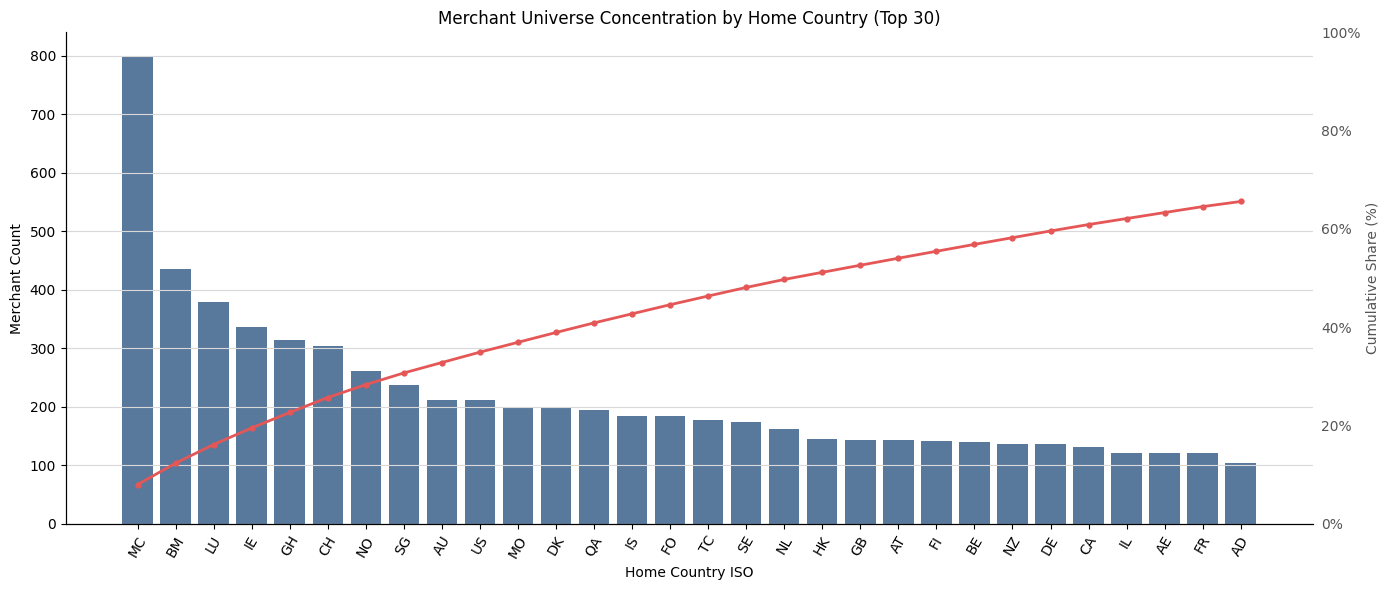

: 

: 

: 

In [ ]:
# Focus the chart on the top 30 countries so the x-axis stays readable.
country_plot_df = country_concentration_df.head(30).copy()

# Create the bar axis first because merchant count is the primary scale we want the eye to read.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=country_plot_df, x="home_country_iso", y="merchant_count", color="#4C78A8", linewidth=0, edgecolor="none", ax=ax1)
ax1.set_title("Merchant Universe Concentration by Home Country (Top 30)")
ax1.set_xlabel("Home Country ISO")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(country_plot_df)),
    country_plot_df["cumulative_share_pct"],
    color="#E45756",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** Country concentration is much sharper than the raw merchant-count table first suggests. The Pareto curve tells us that the merchant seed world is not spread evenly across home-country jurisdictions; a small leading set carries a disproportionate share of the universe.

**Metrics behind the plot:** `190` distinct countries are present, but the top `5` already account for `22.67%` of the merchant universe, the top `10` for `34.94%`, the top `20` for `52.62%`, and the top `30` for `65.59%`. The leading jurisdiction alone (`MC`) contributes `800` merchants, or `8.00%` of the full `10,000`-merchant seed.

We now have a cleaner explanation for why this happens. Most of the heavy-country shape is deliberate: the merchant universe is generated from a GDP-per-capita-heavy allocation policy with heavy-tail and regional boosts, so affluent and boosted markets such as `MC`, `BM`, `LU`, and `IE` are expected to rise toward the top. One visible outlier, `GH`, is different: it is materially amplified by the builder's residual-allocation step rather than by the intended policy shape alone.

That matters for the later fraud and platform story because country is going to act as a hidden weight in several downstream surfaces. Routing geography, legal-time posture, cross-border opportunity, and even campaign concentration can all inherit this early imbalance. So this is not just a descriptive country chart; it is an early explanation boundary for how much of the downstream world is policy-shaped versus builder-shaped.

**Validation note:** The top-country concentration is real, but it should not be treated as one undifferentiated phenomenon. The rich-country cluster is mostly a governed consequence of the merchant-allocation policy, while `GH` is a builder-side allocation artefact caused by the residual reconciliation logic.

That distinction matters because `MC`, `BM`, `LU`, `IE`, and `GH` together account for `2,267` merchants (`22.67%` of the seed world), but they do not all mean the same thing analytically. If we later observe heavy traffic, cases, or labels from those countries, we should remember that some of that weight is intentional policy shape and some of it is implementation side-effect.

The detailed reconstruction is in [transaction_schema_country_concentration_explanation.md](../watson_workbench/notes/transaction_schema_country_concentration_explanation.md).

---


List the most represented MCC codes.

In [10]:
# This shows whether the merchant universe is broadly spread or heavily concentrated in a few categories.
merchant_ids_df["mcc"].value_counts(dropna=False).head(20).rename_axis("mcc").reset_index(name="merchant_count")

,mcc,merchant_count
0,8651,52
1,7922,52
2,5992,51
3,5193,50
4,5937,49
5,7299,49
6,7011,47
7,4812,47
8,5521,47
9,7801,47


Measure how much of the full merchant universe is captured by the leading MCC codes.

In [11]:
# Rank MCCs by merchant count so we can compare category concentration with country concentration.
mcc_concentration_df = merchant_ids_df["mcc"].value_counts(dropna=False).rename_axis("mcc").reset_index(name="merchant_count")

# Express each MCC's count as a share of the full merchant universe.
mcc_concentration_df["merchant_share_pct"] = (mcc_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how quickly the top MCCs accumulate coverage.
mcc_concentration_df["cumulative_share_pct"] = mcc_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
mcc_concentration_df.head(20)

,mcc,merchant_count,merchant_share_pct,cumulative_share_pct
0,8651,52,0.52,0.52
1,7922,52,0.52,1.04
2,5992,51,0.51,1.55
3,5193,50,0.50,2.05
4,5937,49,0.49,2.54
5,7299,49,0.49,3.03
6,7011,47,0.47,3.50
7,4812,47,0.47,3.97
8,5521,47,0.47,4.44
9,7801,47,0.47,4.91


Visualise MCC concentration with the same Pareto structure so we can compare category concentration against country concentration.

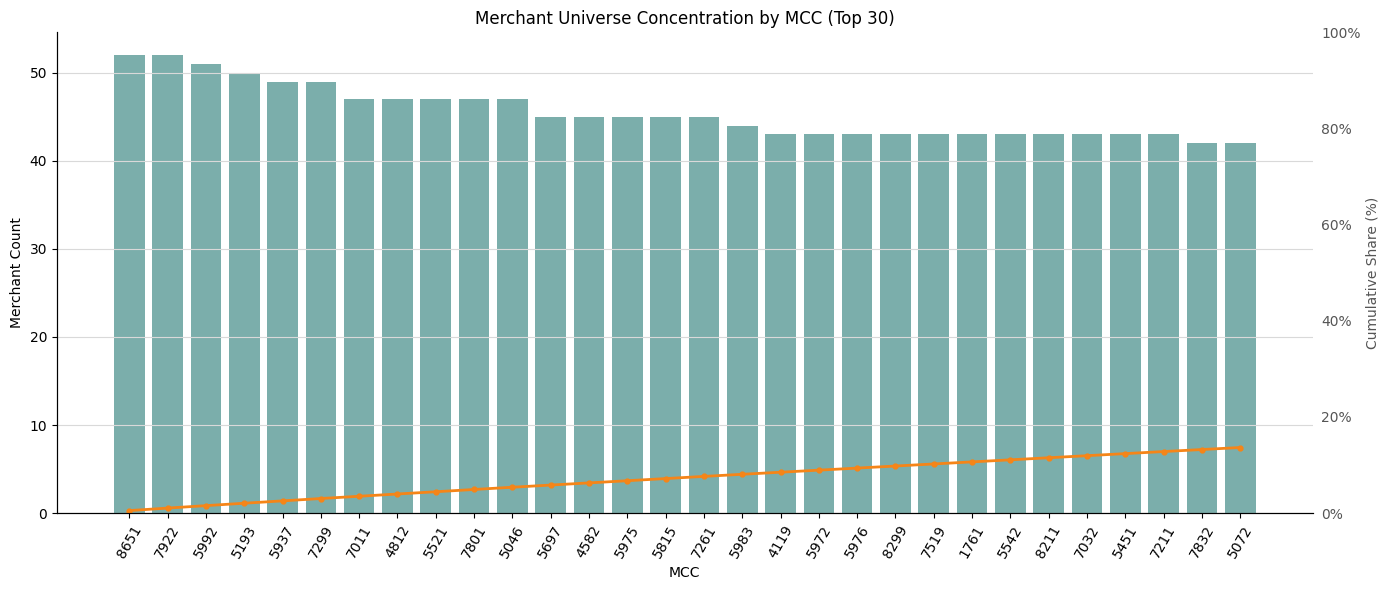

: 

: 

: 

In [ ]:
# Focus the chart on the top 30 MCC codes so the labels remain readable.
mcc_plot_df = mcc_concentration_df.head(30).copy()
mcc_plot_df["mcc"] = mcc_plot_df["mcc"].astype(str)

# Create the bar axis first because merchant count is still the primary quantity being displayed.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=mcc_plot_df, x="mcc", y="merchant_count", color="#72B7B2", linewidth=0, edgecolor="none", ax=ax1)
ax1.set_title("Merchant Universe Concentration by MCC (Top 30)")
ax1.set_xlabel("MCC")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(mcc_plot_df)),
    mcc_plot_df["cumulative_share_pct"],
    color="#F58518",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** MCC concentration behaves very differently from country concentration. The slower cumulative rise means category exposure is distributed across many merchant classes rather than being dominated by a tiny commercial niche.

**Metrics behind the plot:** `290` distinct MCCs are represented. The top `10` MCCs cover only `4.91%` of merchants, the top `20` `9.36%`, the top `30` `13.64%`, and even the top `100` only `41.23%`. The leading MCC count is `52`, so no single category contributes even `1%` of the merchant universe.

That is a useful structural signal because it tells us the merchant world has two different shapes at once: jurisdiction is top-heavy, but merchant-category mix is broader. For downstream behaviour and fraud analysis, that is healthier than sharp MCC dominance would be, because later layers have room to vary by commercial type instead of inheriting a world overfit to a few categories.

So the important reading is not only that MCC is diffuse. It is that category diversity may partially offset the country skew, which will matter later when we ask whether suspicious pressure is concentrated because of geography, campaign design, or genuine commercial mix.

In [12]:
# First identify the countries with the largest merchant counts.
top_countries = merchant_ids_df["home_country_iso"].value_counts().head(15).index
# Then cross-tab those countries against channel to inspect country-level channel mix.
pd.crosstab(
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "home_country_iso"],
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "channel"],
).sort_index()

channel,card_not_present,card_present
home_country_iso,,
AU,53,159
BM,109,327
CH,76,228
DK,50,150
FO,46,139
GH,79,236
IE,84,253
IS,46,139
LU,95,284


Visualise the overall channel split so we can see the merchant seed universe's global CP vs CNP posture at a glance.

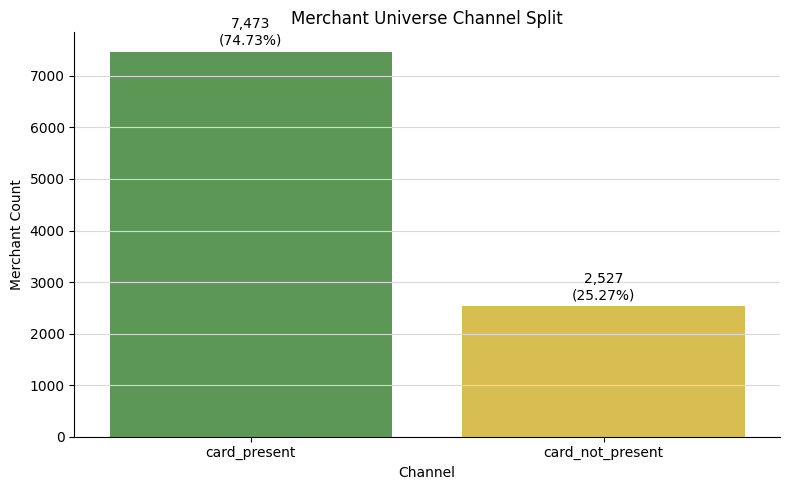

In [13]:
# Rebuild the channel summary with percentage labels so the bar chart can show both counts and share.
channel_plot_df = merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")
channel_plot_df["merchant_share_pct"] = (channel_plot_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Plot the two channel categories directly because this is a simple composition check rather than a ranked concentration chart.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=channel_plot_df, x="channel", y="merchant_count", hue="channel", dodge=False, palette=["#54A24B", "#EECA3B"], linewidth=0, edgecolor="none", ax=ax)
legend = ax.get_legend()
if legend is not None:
    legend.remove()

ax.set_title("Merchant Universe Channel Split")
ax.set_xlabel("Channel")
ax.set_ylabel("Merchant Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)

# Write count and percentage above each bar so the chart is readable without referring back to the table.
for i, row in channel_plot_df.reset_index(drop=True).iterrows():
    ax.text(i, row["merchant_count"] + 80, f"{row['merchant_count']:,}\n({row['merchant_share_pct']:.2f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Interpretation:** The merchant seed universe is clearly channel-tilted toward `card_present`, not channel-balanced. The `~75 / 25` split tells us the baseline world is anchored in physical or in-person commerce, with `card_not_present` activity present but secondary.

**Metrics behind the plot:** `card_present` accounts for `7,473` merchants (`74.73%`) versus `2,527` `card_not_present` merchants (`25.27%`). With only `2` channel values in the seed universe, this is not noise in a long tail; it is the defining baseline composition.

That matters because channel posture is likely to influence later entity behaviour, device use, fraud opportunity, and case or label composition. A world that begins mostly `card_present` should not later be interpreted as if `card_not_present` pressure is the natural default. Any downstream CNP-heavy fraud or workflow pattern would therefore need to be explained as a campaign overlay, routing effect, or behavioural shift rather than as a neutral starting posture.

So the analytical takeaway is not just the ratio itself. It is the constraint the ratio places on later interpretation: channel comparisons downstream should be read against a deliberately tilted merchant seed, not against an assumption of equal baseline exposure.

#### Question

***Once we know the merchant universe is country-concentrated, do the heavy countries actually behave differently from the rest of the seed world, or are they mostly enlarged versions of the same merchant universe?***

**Why this matters?**

The country Pareto chart tells us where merchant weight sits, but not whether that weight implies specialised merchant composition, different channel behaviour, or a structural analytical risk. This follow-up checks the top-country mix directly.

**Top-country set**
- Investigated countries: `MC, BM, LU, IE, GH, CH, NO, SG, AU, US`
- These are the top 10 home countries by merchant count in the 10,000-row merchant universe.


##### Follow-up plotting angles for the top-country question

The country Pareto view told us **where merchant weight sits**, but it did not tell us whether the heavy countries are merely larger versions of the same merchant universe or whether they also carry a materially different internal shape. To answer that properly we took three angles:

1. **country-level MCC mix comparison** to see whether the heavy countries are broad merchant populations or narrow category pockets
2. **country-level channel mix comparison** to see whether CP/CNP posture is actually country-sensitive or mostly policy-pinned
3. **policy-shaped versus artifact-shaped residual effect** to separate true governed weight from builder-side amplification

The supporting summary tables were prepared in the workspace and saved into `watson_workbench/exports`. The notebook uses those sealed summaries to explain the statistical shape rather than rerunning the scratch investigation from zero.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

WORKBENCH = ROOT / "analysis/dev_full_offline_investigation/00_investigation/watson_workbench"
EXPORTS = WORKBENCH / "exports" / "transaction_schema_merchant_ids"

MIX_PATH = EXPORTS / "transaction_schema_top_country_mix_summary.csv"
CHANNEL_PATH = EXPORTS / "transaction_schema_top_country_channel_mix.csv"
POLICY_PATH = EXPORTS / "transaction_schema_top_country_policy_artifact_summary.csv"

POLICY_COLOR = "#4C78A8"
ARTIFACT_COLOR = "#E45756"
NEUTRAL = "#7F7F7F"

def draw_mcc_breadth_concentration_plot():
    df = pd.read_csv(MIX_PATH).sort_values("merchant_count", ascending=False).copy()
    global_top10_share_pct = 4.91
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        df["top10_mcc_share_pct"],
        df["distinct_mcc"],
        s=df["merchant_count"] * 0.9,
        c=df["shape_classification"].map(palette),
        alpha=0.85,
        edgecolors="none",
        linewidths=0,
    )
    ax.axvline(global_top10_share_pct, color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global top-10 MCC share")
    ax.set_title("Top-Country MCC Breadth vs Concentration")
    ax.set_xlabel("Top 10 MCC Share (%)")
    ax.set_ylabel("Distinct MCCs")
    ax.grid(axis="both", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    label_offsets = {"US": (0.10, 1.8), "AU": (0.10, -2.2), "SG": (0.10, 1.2), "CH": (0.10, 1.2)}
    for row in df.itertuples(index=False):
        dx, dy = label_offsets.get(row.country_iso, (0.08, 1.5))
        ax.text(row.top10_mcc_share_pct + dx, row.distinct_mcc + dy, row.country_iso, fontsize=9)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=POLICY_COLOR, markersize=9, label="Policy-shaped"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ARTIFACT_COLOR, markersize=9, label="Artifact-amplified"),
        plt.Line2D([0], [0], color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global top-10 MCC share"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    plt.show()

def draw_mcc_distance_plot():
    df = pd.read_csv(MIX_PATH).sort_values("mcc_jsd_vs_global_bits", ascending=True).copy()
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, ax = plt.subplots(figsize=(9, 6))
    df_jsd = df.sort_values("mcc_jsd_vs_global_bits", ascending=True)
    ax.barh(
        df_jsd["country_iso"],
        df_jsd["mcc_jsd_vs_global_bits"],
        color=df_jsd["shape_classification"].map(palette),
    )
    ax.set_title("Top-Country Jensen-Shannon Divergence from Global MCC Mix")
    ax.set_xlabel("Jensen-Shannon Divergence (bits, lower = closer to global MCC mix)")
    ax.set_ylabel("")
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for y, row in enumerate(df_jsd.itertuples(index=False)):
        ax.text(row.mcc_jsd_vs_global_bits + 0.004, y - 0.22, f"{row.mcc_jsd_vs_global_bits:.3f}", va="center", fontsize=9)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-shaped"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="Artifact-amplified"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=True, facecolor="white", edgecolor="#D9D9D9", framealpha=0.95)
    fig.tight_layout()
    plt.show()

def draw_channel_mix_plot():
    df = pd.read_csv(CHANNEL_PATH).sort_values("card_not_present_pct", ascending=True).copy()
    global_cnp_pct = float(df["global_cnp_pct"].iloc[0])
    us_override_min = 25.0
    us_override_max = 40.0

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axvspan(us_override_min, us_override_max, color="#FDE0A1", alpha=0.45, zorder=0, label="US override band")
    ax.axvline(global_cnp_pct, color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global CNP share")

    colors = [ARTIFACT_COLOR if iso == "US" else POLICY_COLOR for iso in df["country_iso"]]
    ax.barh(df["country_iso"], df["card_not_present_pct"], color=colors)
    ax.set_title("Top-Country Channel Mix")
    ax.set_xlabel("Card-Not-Present Share (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(35, df["card_not_present_pct"].max() + 4))

    for y, row in enumerate(df.itertuples(index=False)):
        ax.text(row.card_not_present_pct + 0.25, y, f"{row.card_not_present_pct:.2f}%", va="center", fontsize=9)

    handles = [
        plt.Line2D([0], [0], color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global CNP share"),
        plt.Rectangle((0, 0), 1, 1, color="#FDE0A1", alpha=0.45, label="US override band"),
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-pinned countries"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="US override active"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False)
    fig.tight_layout()
    plt.show()

def draw_policy_artifact_plot():
    df = pd.read_csv(POLICY_PATH).sort_values("builder_vs_standard_delta", ascending=True).copy()
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 1.2]})

    zoom_df = df.copy()
    ax1.barh(zoom_df["country_iso"], zoom_df["builder_vs_standard_delta"], color=zoom_df["shape_classification"].map(palette))
    ax1.set_title("Residual Effect: Policy-Shaped Countries")
    ax1.set_xlabel("Builder vs Standard Largest-Remainder Delta")
    ax1.set_ylabel("")
    ax1.set_xlim(-2, 2)
    ax1.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    full_df = df.copy()
    ax2.barh(full_df["country_iso"], full_df["builder_vs_standard_delta"], color=full_df["shape_classification"].map(palette))
    ax2.set_title("Residual Effect: Full Scale")
    ax2.set_xlabel("Builder vs Standard Largest-Remainder Delta")
    ax2.set_ylabel("")
    ax2.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    for y, row in enumerate(full_df.itertuples(index=False)):
        xpos = row.builder_vs_standard_delta + (4 if row.builder_vs_standard_delta >= 0 else -6)
        ha = "left" if row.builder_vs_standard_delta >= 0 else "right"
        ax2.text(xpos, y, f"{int(row.builder_vs_standard_delta)}", va="center", ha=ha, fontsize=9)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-shaped"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="Artifact-amplified"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


: 

: 

: 

#### Angle 1: country-level MCC mix comparison

Here we are asking whether the heavy countries are simply **large** or whether they are also **merchant-category outliers**. Two different plots are needed because this angle has two separate statistical questions:

- **breadth vs concentration** asks whether a country is broad on MCC coverage or narrow on a small number of dominant categories
- **Jensen-Shannon divergence** asks how far that country's MCC distribution sits from the global MCC distribution across the full merchant universe

If a heavy country were both highly concentrated and far from the global mix, that would suggest a much more specialised merchant world than the country count alone implies.


In [14]:
# Angle 1A: breadth versus concentration.
draw_mcc_breadth_concentration_plot()


NameError: name 'draw_mcc_breadth_concentration_plot' is not defined

**Interpretation:** The heavy countries are broad merchant populations, not tiny narrow-category pockets. The full merchant universe carries `290` distinct MCCs, and the global top 10 MCCs account for only `4.91%` of merchants. The heavy-country set remains broad on that same scale: `MC` carries `267` distinct MCCs, `BM` `227`, `LU` `208`, and both `IE` and `GH` `196`. Even where concentration rises, it stays moderate rather than collapsing into a few dominant categories: the top-10-MCC share ranges from `8.63%` in `MC` to `14.69%` in `US`. In context, that means the large countries in the Pareto chart are not large because they each represent one merchant niche; they are large and still structurally broad enough to matter later as genuine merchant populations.


In [15]:
# Angle 1B: distance from the global MCC mix.
draw_mcc_distance_plot()


NameError: name 'draw_mcc_distance_plot' is not defined

**Interpretation:** The Jensen-Shannon divergence view says how compositionally different each country's MCC mix is from the global MCC mix. Here the divergence stays **modest rather than explosive**. `MC` is the closest heavy country to the global pattern at `0.0823` bits, followed by `BM` at `0.1508` and `LU` at `0.1932`. The furthest countries in the top set are `AU` at `0.3209` and `US` at `0.3015`, with `GH` at `0.2188`. 

The unit is shown in `bits` because the divergence is calculated with base-2 logarithms; it is an information-distance unit, not a percentage or business KPI. In practice the useful reading is relative: lower values mean closer to the global MCC mix, higher values mean further away. 

The important point is not that higher divergence is automatically bad; it simply means the country is more compositionally distinctive. In this dataset that tells us the heavy countries are not identical copies of the global world, but neither are they radically alien merchant structures. That keeps the country-concentration finding analytically meaningful without forcing us to treat the whole top-country set as unrealistic.

#### Angle 2: country-level channel mix comparison

This angle asks whether country weight also translates into a materially different **CP/CNP posture**, or whether the merchant universe is largely channel-pinned by policy. If the heavy countries had very different channel splits, that would affect how we later interpret traffic, fraud, and operational pressure.


In [16]:
# Angle 2: country-level channel mix comparison.
draw_channel_mix_plot()


NameError: name 'draw_channel_mix_plot' is not defined

**Interpretation:** Country-level channel mix is mostly policy-governed, not strongly country-sensitive. The global channel split is `card_present = 74.73%` and `card_not_present = 25.27%`, and most heavy countries sit almost exactly on that global line: `MC` `75.00 / 25.00`, `BM` `75.00 / 25.00`, `LU` `74.93 / 25.07`, `IE` `75.07 / 24.93`, and `GH` `74.92 / 25.08`. The main exception is `US`, which shifts to `67.30%` `card_present` and `32.70%` `card_not_present`, matching the explicit US override band rather than emergent merchant behaviour. For our context, that means country concentration does **not** automatically imply a different channel universe downstream; most of the top-country set carries the same CP/CNP posture the builder already pinned globally.


#### Angle 3: policy-shaped versus artifact-shaped residual effect

The last angle is about explanation, not just description. Once we know which countries are heavy, we need to know whether that weight is coming from the **governed allocation policy** or from a **builder-side residual effect**. Without this angle, a country can look important for the wrong reason.


In [17]:
# Angle 3: policy-shaped versus artifact-shaped residual effect.
draw_policy_artifact_plot()


NameError: name 'draw_policy_artifact_plot' is not defined

**Interpretation:** This plot is what finally separates governed weight from artifact amplification. Most of the heavy countries are `policy-shaped`: `MC`, `BM`, `LU`, `IE`, `CH`, `NO`, `SG`, `AU`, and `US` differ from the standard largest-remainder counterfactual by only `0` or `-1`, which is immaterial at this scale. `GH` is the clear outlier: it carries a `+309` merchant delta because the builder grants the full leftover block to the first-ranked fractional-remainder country. That means the heavy-country list actually contains two different meanings: genuine policy-weighted countries and one country whose prominence is materially amplified by the reconciliation implementation. In the context of this merchant universe, `GH` therefore needs to be interpreted differently from `MC`, `BM`, or `LU` when we later reason about outlet spread, zone allocation, traffic, fraud, or case/label behaviour.

Notes: GH receiving `+309` merchants is a drift from design as residuals should have been shared amongst the countries with remainders and not just dumped in one country. `To Be Resolved` later

**What This Shows:** These follow-up angles tell us that the heavy-country pattern in the merchant seed is not one single phenomenon. The large countries are broad merchant populations rather than narrow MCC pockets; most of them also sit close to the global channel split, which means country heaviness is not automatically producing a different CP/CNP world. The final residual-allocation view then separates the top-country set into two groups: countries whose prominence is mainly policy-shaped, and `GH`, whose prominence is materially amplified by the builder's residual allocation step. So the top-country question resolves into a more precise answer: most heavy countries are genuinely authored by the governed allocation logic, but one visible outlier is implementation-shaped rather than macro-economically natural.

#### A.2: `iso3166_canonical_2024`, `world_bank_gdp_per_capita_20250415`, and `gdp_bucket_map_2024`

Before using these artefacts to explain country concentration, we should inspect them directly as sealed `1A.S0` inputs. At this stage the goal is narrower than interpretation:
- confirm what the datasets actually look like
- confirm the schema we have in hand
- confirm that they cover the merchant-country universe cleanly
- line up merchant-country counts against GDP and bucket values so we can inspect the surface for ourselves before drawing conclusions

So this block stops at **dataset visibility and coverage**. The concentration interpretation comes after that.


In [18]:
iso3166_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_iso   251 non-null    object
 1   alpha3        251 non-null    object
 2   numeric_code  251 non-null    int16 
 3   name          251 non-null    object
 4   region        0 non-null      object
 5   subregion     0 non-null      object
 6   start_date    0 non-null      object
 7   end_date      0 non-null      object
dtypes: int16(1), object(7)
memory usage: 14.3+ KB


In [19]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_iso       190 non-null    object 
 1   observation_year  190 non-null    int64  
 2   gdp_pc_usd_2015   190 non-null    float64
 3   source_series     190 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.1+ KB


In [20]:
gdp_bucket_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_iso   190 non-null    object
 1   bucket_id     190 non-null    int64 
 2   bucket_label  0 non-null      object
 3   method        190 non-null    object
 4   k             190 non-null    int64 
 5   source_year   190 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 9.0+ KB


In [21]:
# Show a few rows from each governed artefact so the raw shape is visible before we summarise anything.
display(iso3166_df.head(10))
display(gdp_df.head(10))
display(gdp_bucket_df.head(10))


,country_iso,alpha3,numeric_code,name,region,subregion,start_date,end_date
0,AD,AND,20,Andorra,None,None,None,None
1,AE,ARE,784,United Arab Emirates,None,None,None,None
2,AF,AFG,4,Afghanistan,None,None,None,None
3,AG,ATG,28,Antigua and Barbuda,None,None,None,None
4,AI,AIA,660,Anguilla,None,None,None,None
5,AL,ALB,8,Albania,None,None,None,None
6,AM,ARM,51,Armenia,None,None,None,None
7,AN,ANT,530,Netherlands Antilles,None,None,None,None
8,AO,AGO,24,Angola,None,None,None,None
9,AQ,ATA,10,Antarctica,None,None,None,None


,country_iso,observation_year,gdp_pc_usd_2015,source_series
0,AD,2024,41034.526672,NY.GDP.PCAP.KD
1,AE,2024,41605.416867,NY.GDP.PCAP.KD
2,AG,2024,18350.185037,NY.GDP.PCAP.KD
3,AL,2024,6549.233874,NY.GDP.PCAP.KD
4,AM,2024,5378.318000,NY.GDP.PCAP.KD
5,AO,2024,2845.477793,NY.GDP.PCAP.KD
6,AR,2024,12774.350660,NY.GDP.PCAP.KD
7,AT,2024,45958.825007,NY.GDP.PCAP.KD
8,AU,2024,61480.670711,NY.GDP.PCAP.KD
9,AW,2024,33373.917459,NY.GDP.PCAP.KD


,country_iso,bucket_id,bucket_label,method,k,source_year
0,AD,3,None,jenks,5,2024
1,AE,3,None,jenks,5,2024
2,AG,2,None,jenks,5,2024
3,AL,1,None,jenks,5,2024
4,AM,1,None,jenks,5,2024
5,AO,1,None,jenks,5,2024
6,AR,1,None,jenks,5,2024
7,AT,3,None,jenks,5,2024
8,AU,3,None,jenks,5,2024
9,AW,2,None,jenks,5,2024


Build a compact profile of the governed artefacts so we can see their landed schema, null exposure, and distinct-count shape.


In [22]:
def column_profile(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            'dataset': dataset_name,
            'column': df.columns,
            'dtype': df.dtypes.astype(str).values,
            'null_count': df.isna().sum().values,
            'null_pct': df.isna().mean().mul(100).round(2).values,
            'distinct_count': df.nunique(dropna=False).values,
        }
    )

pd.concat(
    [
        column_profile(iso3166_df, 'iso3166_canonical_2024'),
        column_profile(gdp_df, 'world_bank_gdp_per_capita_20250415'),
        column_profile(gdp_bucket_df, 'gdp_bucket_map_2024'),
    ],
    ignore_index=True,
)


,dataset,column,dtype,null_count,null_pct,distinct_count
0,iso3166_canonical_2024,country_iso,object,0,0.0,251
1,iso3166_canonical_2024,alpha3,object,0,0.0,251
2,iso3166_canonical_2024,numeric_code,int16,0,0.0,251
3,iso3166_canonical_2024,name,object,0,0.0,251
4,iso3166_canonical_2024,region,object,251,100.0,1
5,iso3166_canonical_2024,subregion,object,251,100.0,1
6,iso3166_canonical_2024,start_date,object,251,100.0,1
7,iso3166_canonical_2024,end_date,object,251,100.0,1
8,world_bank_gdp_per_capita_20250415,country_iso,object,0,0.0,190
9,world_bank_gdp_per_capita_20250415,observation_year,int64,0,0.0,1


Capture the first coverage and contract checks for the GDP and bucket artefacts against the merchant-country universe.


In [ ]:
merchant_country_set = set(merchant_ids_df['home_country_iso'].dropna().unique())
iso_country_set = set(iso3166_df['country_iso'].dropna().unique())
gdp_country_set = set(gdp_df['country_iso'].dropna().unique())
bucket_country_set = set(gdp_bucket_df['country_iso'].dropna().unique())

pd.DataFrame(
    [
        {'check': 'merchant_country_distinct', 'value': len(merchant_country_set)},
        {'check': 'iso3166_country_distinct', 'value': len(iso_country_set)},
        {'check': 'gdp_country_distinct', 'value': len(gdp_country_set)},
        {'check': 'bucket_country_distinct', 'value': len(bucket_country_set)},
        {'check': 'merchant_countries_missing_from_iso3166', 'value': len(merchant_country_set - iso_country_set)},
        {'check': 'merchant_countries_missing_from_gdp', 'value': len(merchant_country_set - gdp_country_set)},
        {'check': 'merchant_countries_missing_from_bucket_map', 'value': len(merchant_country_set - bucket_country_set)},
        {'check': 'gdp_observation_years', 'value': sorted(gdp_df['observation_year'].dropna().unique().tolist())},
        {'check': 'gdp_source_series', 'value': sorted(gdp_df['source_series'].dropna().unique().tolist())},
        {'check': 'bucket_ids_present', 'value': sorted(gdp_bucket_df['bucket_id'].dropna().unique().tolist())},
        {'check': 'bucket_method', 'value': sorted(gdp_bucket_df['method'].dropna().unique().tolist())},
        {'check': 'bucket_k', 'value': sorted(gdp_bucket_df['k'].dropna().unique().tolist())},
        {'check': 'bucket_source_year', 'value': sorted(gdp_bucket_df['source_year'].dropna().unique().tolist())},
        {'check': 'bucket_label_null_rows', 'value': int(gdp_bucket_df['bucket_label'].isna().sum())},
    ]
)


,check,value
0,merchant_country_distinct,190
1,iso3166_country_distinct,251
2,gdp_country_distinct,190
3,bucket_country_distinct,190
4,merchant_countries_missing_from_iso3166,0
5,merchant_countries_missing_from_gdp,0
6,merchant_countries_missing_from_bucket_map,0
7,gdp_observation_years,[2024]
8,gdp_source_series,[NY.GDP.PCAP.KD]
9,bucket_ids_present,"[1, 2, 3, 4, 5]"


: 

: 

: 

Join merchant-country counts to the GDP and bucket artefacts so we can inspect the aligned surface directly before making any explanatory claim.


In [23]:
merchant_country_gdp_bucket_df = (
    merchant_ids_df.groupby('home_country_iso')
    .size()
    .rename('merchant_count')
    .reset_index()
    .merge(iso3166_df[['country_iso', 'name']], left_on='home_country_iso', right_on='country_iso', how='left')
    .merge(
        gdp_df[['country_iso', 'observation_year', 'gdp_pc_usd_2015', 'source_series']],
        left_on='home_country_iso',
        right_on='country_iso',
        how='left',
        suffixes=('', '_gdp'),
    )
    .merge(
        gdp_bucket_df[['country_iso', 'bucket_id', 'bucket_label', 'method', 'k', 'source_year']],
        left_on='home_country_iso',
        right_on='country_iso',
        how='left',
        suffixes=('', '_bucket'),
    )
    .sort_values(['merchant_count', 'home_country_iso'], ascending=[False, True])
    .reset_index(drop=True)
)
merchant_country_gdp_bucket_df['merchant_share_pct'] = (merchant_country_gdp_bucket_df['merchant_count'] / len(merchant_ids_df) * 100).round(2)
merchant_country_gdp_bucket_df.head(20)[['home_country_iso', 'name', 'merchant_count', 'merchant_share_pct', 'gdp_pc_usd_2015', 'bucket_id', 'bucket_label']]


,home_country_iso,name,merchant_count,merchant_share_pct,gdp_pc_usd_2015,bucket_id,bucket_label
0,MC,Monaco,800,8.00,247170.219911,5,None
1,BM,Bermuda,436,4.36,122117.603587,4,None
2,LU,Luxembourg,379,3.79,104147.173993,4,None
3,IE,Ireland,337,3.37,94474.987971,4,None
4,GH,Ghana,315,3.15,2167.726914,1,None
5,CH,Switzerland,304,3.04,90067.464543,4,None
6,NO,Norway,262,2.62,79667.527231,4,None
7,SG,Singapore,238,2.38,67706.833615,3,None
8,AU,Australia,212,2.12,61480.670711,3,None
9,US,United States,211,2.11,66356.170675,3,None


Finally, inspect the bucket compression itself before turning it into a narrative about country concentration.


In [ ]:
bucket_distribution_df = (
    merchant_country_gdp_bucket_df.groupby('bucket_id')
    .agg(
        country_count=('home_country_iso', 'nunique'),
        merchant_count=('merchant_count', 'sum'),
        min_gdp=('gdp_pc_usd_2015', 'min'),
        median_gdp=('gdp_pc_usd_2015', 'median'),
        max_gdp=('gdp_pc_usd_2015', 'max'),
    )
    .reset_index()
    .sort_values('bucket_id')
)
bucket_distribution_df['country_share_pct'] = (bucket_distribution_df['country_count'] / bucket_distribution_df['country_count'].sum() * 100).round(2)
bucket_distribution_df['merchant_share_pct'] = (bucket_distribution_df['merchant_count'] / bucket_distribution_df['merchant_count'].sum() * 100).round(2)
bucket_distribution_df


,bucket_id,country_count,merchant_count,min_gdp,median_gdp,max_gdp,country_share_pct,merchant_share_pct
0,1,122,1517,268.700857,3683.833039,13121.676991,64.21,15.17
1,2,39,2239,14579.400107,21494.685606,37152.563600,20.53,22.39
2,3,23,3726,39683.395349,47960.910576,67706.833615,12.11,37.26
3,4,5,1718,79667.527231,94474.987971,122117.603587,2.63,17.18
4,5,1,800,247170.219911,247170.219911,247170.219911,0.53,8.00


: 

: 

: 

##### GDP and Bucket Relationship Views

These visuals sit on top of the governed GDP and bucket read. The aim here is only to surface the patterns visually before we write any interpretation:
- the full country-level relationship between GDP per capita and merchant count
- how the top merchant countries sit inside the GDP bucket map
- how country share and merchant share compress differently across buckets
- how the low-GDP `GH` exception looks against its bucket-1 peers


In [24]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

GDP_BUCKET_COLORS = {
    1: '#E45756',
    2: '#F58518',
    3: '#72B7B2',
    4: '#54A24B',
    5: '#4C78A8',
}

def style_axes(ax, *, grid_x: bool = False, grid_y: bool = True) -> None:
    # Keep the main plotting frame explicit so the chart does not feel visually detached.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.tick_params(axis='both', colors='#333333')
    if grid_y:
        ax.grid(axis='y', color='#D9D9D9', linewidth=0.8)
    else:
        ax.grid(axis='y', visible=False)
    if grid_x:
        ax.grid(axis='x', color='#E6E6E6', linewidth=0.8)
    else:
        ax.grid(axis='x', visible=False)


def draw_gdp_relationship_scatter(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(11.5, 7))
    colors = [GDP_BUCKET_COLORS[int(v)] for v in df['bucket_id']]
    ax.scatter(
        df['gdp_pc_usd_2015'],
        df['merchant_count'],
        s=36,
        c=colors,
        alpha=0.82,
        edgecolors='none',
        linewidths=0,
    )
    ax.set_xscale('log')
    ax.set_title('Merchant Count vs GDP per Capita by Country')
    ax.set_xlabel('GDP per Capita, constant 2015 USD (log scale)')
    ax.set_ylabel('Merchant Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    top_labels = set(df.nlargest(10, 'merchant_count')['home_country_iso'].tolist() + ['GH'])
    for _, row in df[df['home_country_iso'].isin(top_labels)].iterrows():
        ax.text(
            row['gdp_pc_usd_2015'] * 1.03,
            row['merchant_count'] + 7,
            row['home_country_iso'],
            fontsize=9,
            ha='left',
            va='bottom',
        )

    handles = [
        Line2D(
            [0], [0], marker='o', color='w', label=f'Bucket {bucket}',
            markerfacecolor=color, markeredgecolor='none', markersize=8
        )
        for bucket, color in GDP_BUCKET_COLORS.items()
    ]
    legend = ax.legend(handles=handles, title='GDP Bucket', loc='upper left', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')

    rho = df[['merchant_count', 'gdp_pc_usd_2015']].corr(method='spearman').iloc[0, 1]
    ax.text(
        0.985, 0.03, f'Spearman ρ = {rho:.4f}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': '#BBBBBB', 'boxstyle': 'round,pad=0.3'}
    )
    plt.tight_layout()
    plt.show()

def draw_top20_bucket_membership(df: pd.DataFrame) -> None:
    plot_df = df.nlargest(20, 'merchant_count').copy().sort_values('merchant_count', ascending=True)
    fig, ax = plt.subplots(figsize=(10.5, 8))
    bar_colors = [GDP_BUCKET_COLORS[int(v)] for v in plot_df['bucket_id']]
    ax.barh(plot_df['home_country_iso'], plot_df['merchant_count'], color=bar_colors, edgecolor='none', linewidth=0)
    ax.set_title('Top 20 Merchant Countries, Colored by GDP Bucket')
    ax.set_xlabel('Merchant Count')
    ax.set_ylabel('Home Country ISO')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for _, row in plot_df.iterrows():
        ax.text(row['merchant_count'] + 8, row['home_country_iso'], f"B{int(row['bucket_id'])}", va='center', ha='left', fontsize=9)

    handles = [
        Line2D([0], [0], marker='s', color='w', label=f'Bucket {bucket}', markerfacecolor=color, markersize=10)
        for bucket, color in GDP_BUCKET_COLORS.items()
    ]
    legend = ax.legend(handles=handles, title='GDP Bucket', loc='lower right', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')
    plt.tight_layout()
    plt.show()

def draw_bucket_compression(df: pd.DataFrame) -> None:
    x = np.arange(len(df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(10, 6.2))
    left = ax.bar(x - width / 2, df['country_share_pct'], width, color='#B8BDC6', label='Country Share', edgecolor='none', linewidth=0)
    right = ax.bar(x + width / 2, df['merchant_share_pct'], width, color='#4C78A8', label='Merchant Share', edgecolor='none', linewidth=0)
    ax.set_title('GDP Buckets: Country Share vs Merchant Share')
    ax.set_xlabel('GDP Bucket')
    ax.set_ylabel('Share of Total')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Bucket {int(v)}" for v in df['bucket_id']])
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bars in (left, right):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.7, f"{height:.2f}%", ha='center', va='bottom', fontsize=9)

    legend = ax.legend(loc='upper right', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')
    plt.tight_layout()
    plt.show()

def draw_bucket1_exception(df: pd.DataFrame) -> None:
    plot_df = df[df['bucket_id'] == 1].copy().nlargest(12, 'merchant_count').sort_values('merchant_count', ascending=True)
    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    colors = ['#E45756' if iso == 'GH' else '#B8BDC6' for iso in plot_df['home_country_iso']]
    ax.barh(plot_df['home_country_iso'], plot_df['merchant_count'], color=colors, edgecolor='none', linewidth=0)
    ax.set_title('Bucket 1 Peer View: `GH` vs Other Low-GDP Countries')
    ax.set_xlabel('Merchant Count')
    ax.set_ylabel('Home Country ISO')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for _, row in plot_df.iterrows():
        ax.text(
            row['merchant_count'] + 3,
            row['home_country_iso'],
            f"{int(row['merchant_count'])} | GDP {row['gdp_pc_usd_2015']:,.0f}",
            va='center',
            ha='left',
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


Full country-level GDP vs merchant-count relationship.


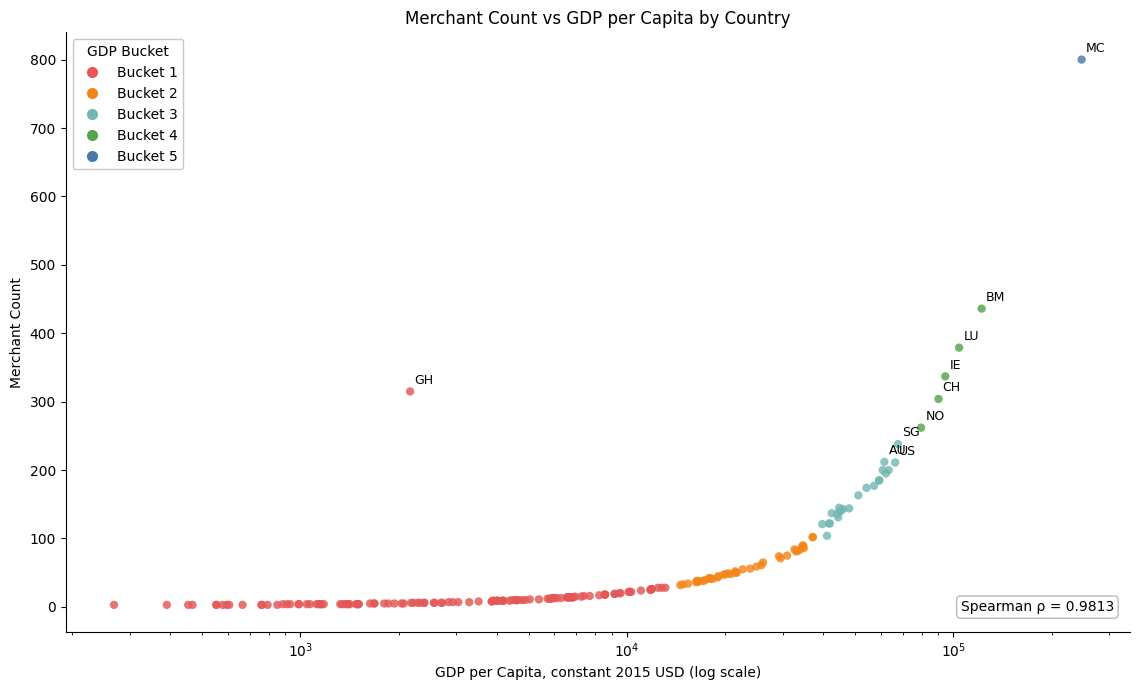

In [25]:
draw_gdp_relationship_scatter(merchant_country_gdp_bucket_df)


**Interpretation:** The scatter shows that the merchant-country ordering is not loosely related to GDP per capita; it is tightly aligned with it. The rank relationship is captured by `Spearman ρ = 0.9813`, which is strong enough that the broad merchant-country ordering should be read as materially GDP-shaped. The upper-right cluster contains the countries we have already seen at the top of the merchant table: `MC` at `800` merchants with GDPpc about `247,170`, `BM` at `436` with `122,118`, `LU` at `379` with `104,147`, `IE` at `337` with `94,475`, and `CH` at `304` with `90,067`. Most of the rest of the points fall into a smooth monotonic curve across the log GDP scale. The visual break is `GH`: it sits far left on the GDP axis at only about `2,168`, but still rises to `315` merchants, which is exactly why it needs to be explained as an exception rather than as part of the normal GDP-shaped pattern.


Top-country merchant concentration, colored by GDP bucket membership.


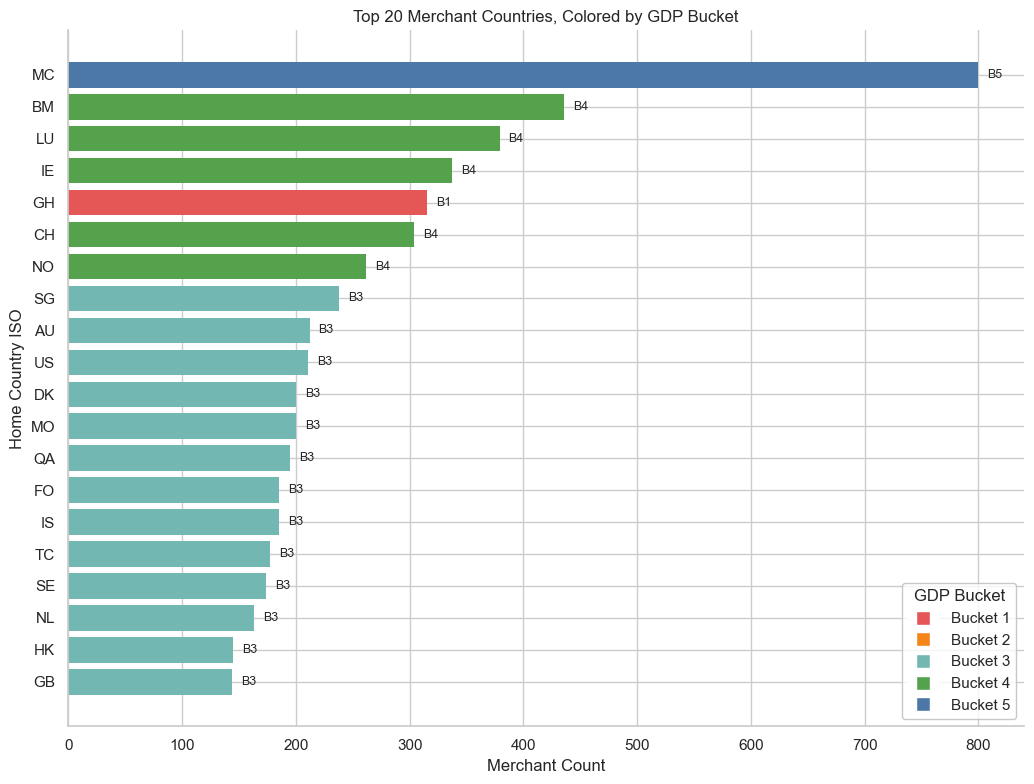

: 

: 

: 

In [ ]:
draw_top20_bucket_membership(merchant_country_gdp_bucket_df)


**Interpretation:** The top-country view makes the heavy-country cluster easier to read than the raw table. Of the top `20` merchant countries, `13` are in bucket `3`, `5` are in bucket `4`, `1` is in bucket `5` (`MC`), and only `1` is in bucket `1` (`GH`). There are no bucket-`2` countries in the top `20` at all. In merchant-weight terms, bucket `3` contributes `2,429` merchants (`46.16%` of top-20 merchant weight), bucket `4` contributes `1,718` (`32.65%`), bucket `5` contributes `800` (`15.20%`), and the lone low-bucket exception `GH` contributes `315` (`5.99%`). So the heavy end of the merchant universe is overwhelmingly a bucket `3–5` phenomenon, with `GH` standing apart as the one obvious country that breaks the macro-economic pattern.


Bucket compression: country share versus merchant share.


In [26]:
draw_bucket_compression(bucket_distribution_df)


NameError: name 'bucket_distribution_df' is not defined

**Interpretation:** This is the bucket-compression story in one view. Bucket `1` contains most of the countries, `122` of `190` (`64.21%`), but only `1,517` merchants (`15.17%`). Buckets `3–5` do the opposite: together they contain only `29` countries (`15.26%` of the country set) but hold `6,244` merchants (`62.44%` of the merchant universe). The upper-rich buckets alone, `4` and `5`, are just `6` countries (`3.16%`) but carry `2,518` merchants (`25.18%`). So the merchant world is not merely broader at low GDP and narrower at high GDP; it is compressed so that a small affluent country set carries a disproportionate amount of merchant weight. That is the structural reason the top-country list feels unusually rich-country-heavy even before we look at specific country names.


The low-GDP exception: `GH` against other bucket-1 peers.


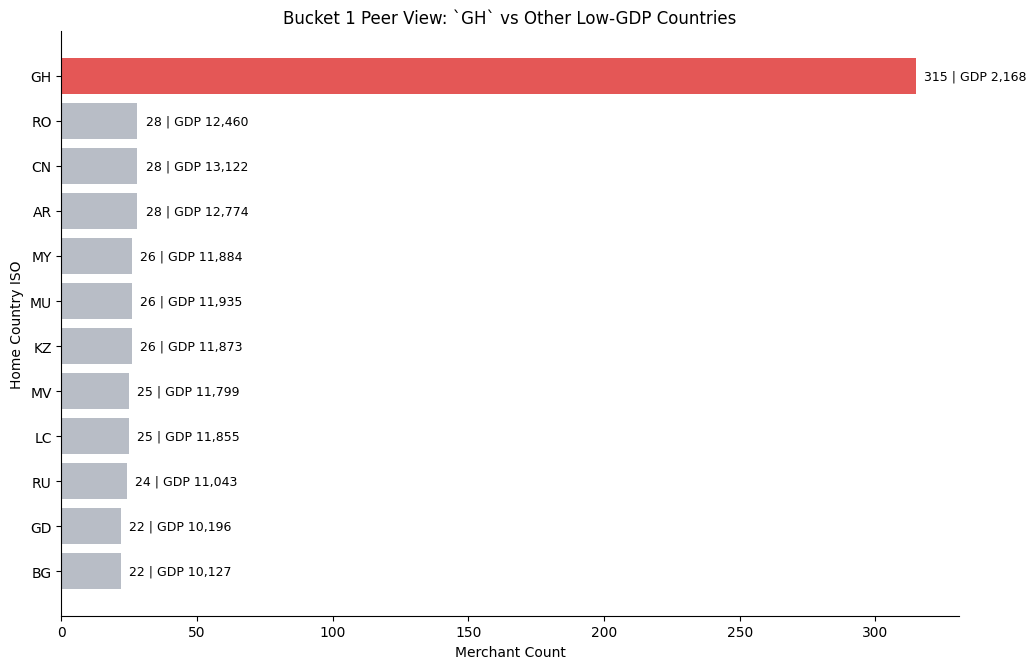

In [27]:
draw_bucket1_exception(merchant_country_gdp_bucket_df)


**Interpretation:** This peer view makes the low-bucket exception concrete rather than abstract. `GH` sits in bucket `1` with GDP per capita of about `2,168`, but it carries `315` merchants (`3.15%` of the full universe). The next-highest bucket-1 peers are `AR`, `CN`, and `RO`, each at only `28` merchants, followed by `KZ`, `MU`, and `MY` at `26`. So `GH` is about `11.25x` larger than the next bucket-1 country by merchant count. In our context, that is the visual reason we do not read `GH` as just another poor-country observation: the GDP artefact places it firmly in the low-income band, but the merchant count behaves like a top-country outlier. That keeps the earlier conclusion intact that `GH` is not explained by the macro-economic surfaces alone and needs the builder-side residual-allocation explanation.


**What This Shows:** Taken together, the GDP and bucket relationship views explain most of the merchant-country concentration we observed earlier. The merchant-country ordering is overwhelmingly GDP-shaped, the top merchant countries are concentrated in buckets `3–5`, and the bucket-compression view shows why a relatively small affluent country set carries such a large share of merchant weight. The only obvious exception is `GH`, which remains a low-bucket top-country outlier. So this block answers the main question directly: the rich-country heaviness in the merchant universe is largely authored by the governed GDP and bucket surfaces, with `GH` standing apart as the main country that still needs builder-side explanation.

##### GDP Surface Compression Views

These visuals are narrower than the earlier GDP relationship section. The goal here is to inspect the frozen bucket map as a compression of the continuous GDP surface itself:
- how the ordered GDP surface is segmented into buckets
- what GDP ranges each bucket actually covers
- how much within-bucket GDP spread is being collapsed into one category

Continuous GDP surface, ordered by GDP rank and coloured by frozen bucket membership.

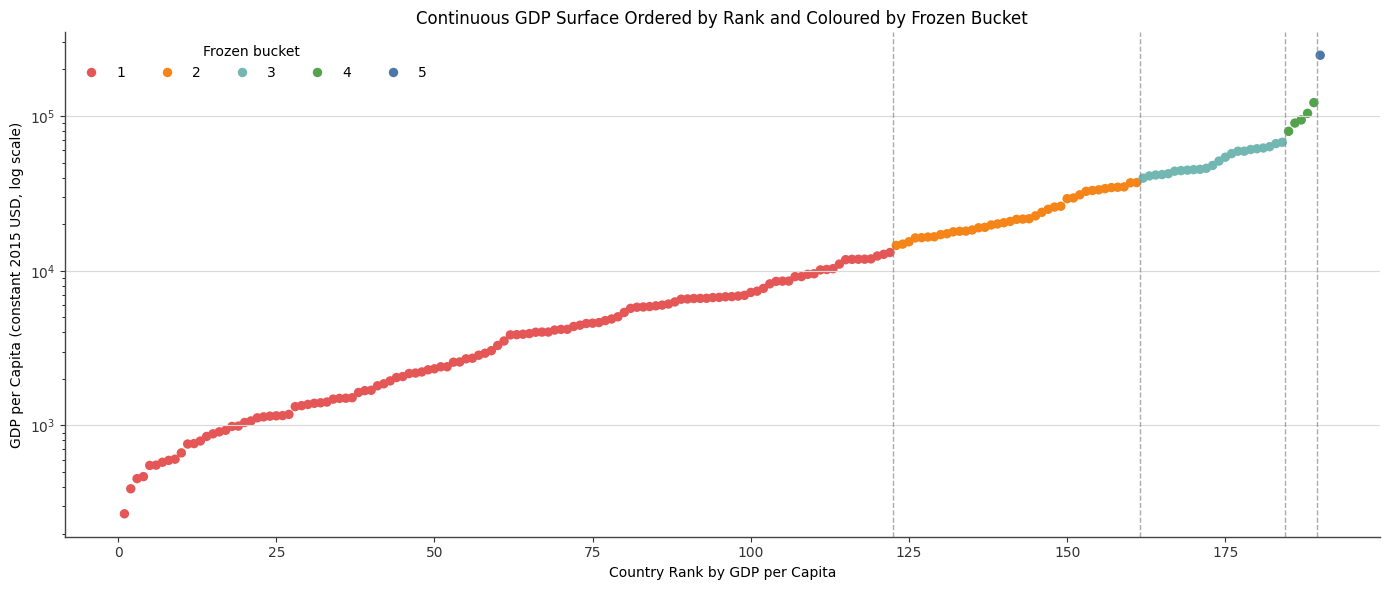

In [28]:
# Reorder countries by GDP per capita so we can look at the continuous macro-economic surface directly.
gdp_ranked_df = merchant_country_gdp_bucket_df.sort_values('gdp_pc_usd_2015').reset_index(drop=True).copy()
gdp_ranked_df['gdp_rank'] = gdp_ranked_df.index + 1

# Draw the ranked GDP surface and colour each point by its frozen bucket assignment.
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(
    data=gdp_ranked_df,
    x='gdp_rank',
    y='gdp_pc_usd_2015',
    hue='bucket_id',
    palette=GDP_BUCKET_COLORS,
    s=46,
    edgecolor='none',
    ax=ax,
)

# Mark where the frozen bucket transitions happen along the continuous ranked GDP surface.
bucket_boundaries = (
    gdp_ranked_df.groupby('bucket_id')['gdp_rank']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('bucket_id')
)
for _, row in bucket_boundaries.iloc[:-1].iterrows():
    ax.axvline(row['max'] + 0.5, color='#888888', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Continuous GDP Surface Ordered by Rank and Coloured by Frozen Bucket')
ax.set_xlabel('Country Rank by GDP per Capita')
ax.set_ylabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_yscale('log')
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(title='Frozen bucket', frameon=False, ncol=5, loc='upper left')

plt.tight_layout()
plt.show()


**Interpretation:** This ranked-surface view makes the bucket map legible as a frozen segmentation of the continuous GDP world. The underlying GDP surface is smooth and monotonic on the log scale, while the bucket colours break that surface into discrete macro-economic bands. The dashed vertical lines show where the frozen bucket boundaries land in rank space, and the result is informative: the lower-income end is long and dense, while the upper-income end is short and compressed into a small number of countries. That means the bucket map is not arbitrarily chopping the GDP surface into equal-sized groups; it is compressing a very uneven macro-economic world into a small ordered category system. In practical terms, this is why the later merchant-allocation logic can inherit a strong rich-country shape even though the raw GDP surface itself is continuous rather than categorical.

GDP distribution within each frozen bucket.

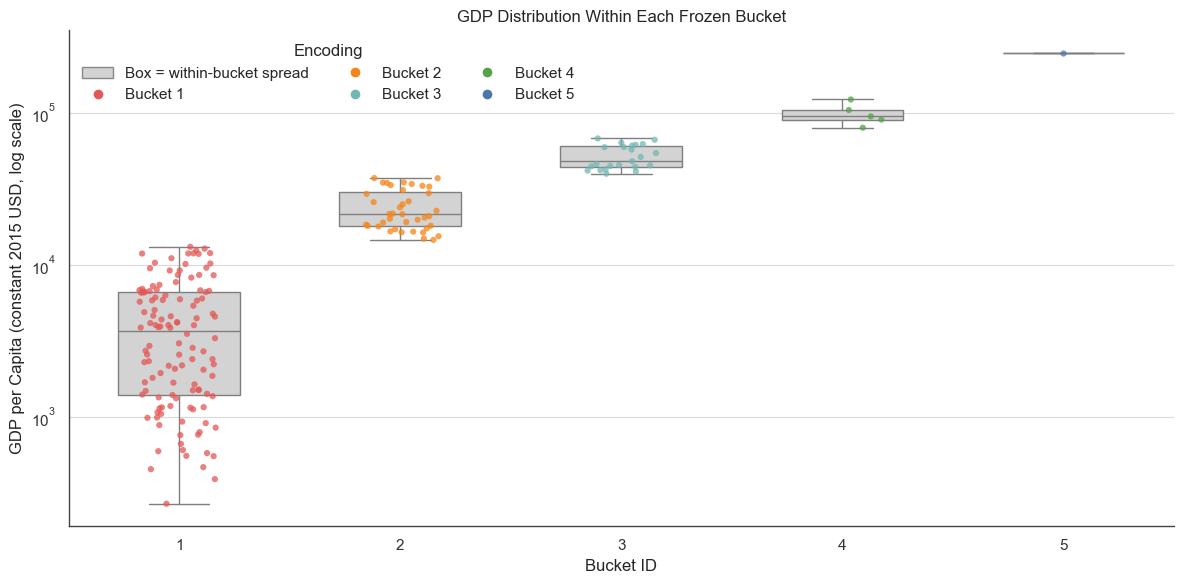

: 

: 

: 

In [ ]:
# Keep bucket id categorical here so each frozen bucket gets its own distribution panel on the x-axis.
gdp_bucket_distribution_df = merchant_country_gdp_bucket_df.copy()
gdp_bucket_distribution_df['bucket_id'] = gdp_bucket_distribution_df['bucket_id'].astype(int).astype(str)
bucket_order = ['1', '2', '3', '4', '5']
gdp_bucket_distribution_df['bucket_id'] = pd.Categorical(gdp_bucket_distribution_df['bucket_id'], categories=bucket_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=gdp_bucket_distribution_df,
    x='bucket_id',
    y='gdp_pc_usd_2015',
    order=bucket_order,
    color='#D3D3D3',
    width=0.55,
    fliersize=0,
    ax=ax,
)
sns.stripplot(
    data=gdp_bucket_distribution_df,
    x='bucket_id',
    y='gdp_pc_usd_2015',
    hue='bucket_id',
    order=bucket_order,
    hue_order=bucket_order,
    palette={str(k): v for k, v in GDP_BUCKET_COLORS.items()},
    jitter=0.18,
    size=4.5,
    alpha=0.75,
    dodge=False,
    ax=ax,
)

ax.set_title('GDP Distribution Within Each Frozen Bucket')
ax.set_xlabel('Bucket ID')
ax.set_ylabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_yscale('log')
style_axes(ax, grid_x=False, grid_y=True)

legend_handles = [Patch(facecolor='#D3D3D3', edgecolor='#888888', label='Box = within-bucket spread')]
legend_handles.extend(
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=f'Bucket {bucket_id}')
    for bucket_id, color in GDP_BUCKET_COLORS.items()
)
ax.legend(handles=legend_handles, title='Encoding', frameon=False, loc='upper left', ncol=3)

plt.tight_layout()
plt.show()


**Interpretation:** This within-bucket distribution view shows what the frozen compression is actually collapsing. Bucket `1` is not just the lowest bucket; it is a very wide low-income band with substantial internal spread, stretching from about `269` to `13,122` GDP per capita and containing `122` countries. Bucket `2` then narrows into a mid-income band of about `14,579` to `37,153`, bucket `3` into an affluent band of about `39,683` to `67,707`, and bucket `4` into a still tighter upper-rich band of about `79,668` to `122,118`. Bucket `5` is a singleton extreme represented only by `MC` at about `247,170`.

So the bucket map does not preserve the same level of resolution across the GDP surface. It keeps the upper end narrow and sharply differentiated, while the lower end is grouped into a much broader internal band. That matters because later policy logic operating on buckets is inheriting this asymmetry: low-income countries are treated in a much more compressed way than high-income ones.

GDP range compression by frozen bucket.

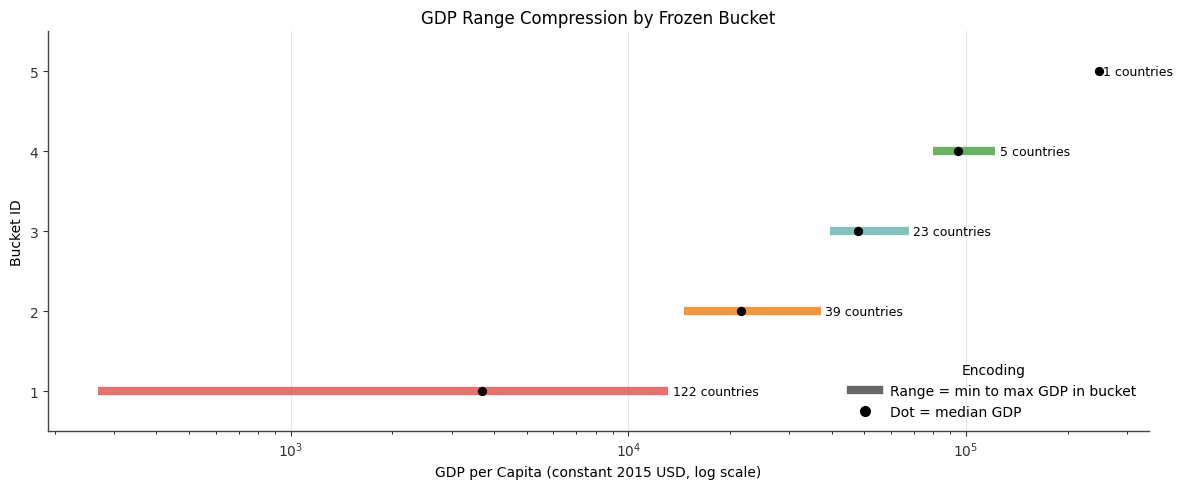

In [29]:
# Collapse each bucket to its minimum, median, and maximum GDP so the compression ranges are explicit.
gdp_bucket_range_df = (
    merchant_country_gdp_bucket_df.groupby('bucket_id')
    .agg(
        min_gdp=('gdp_pc_usd_2015', 'min'),
        median_gdp=('gdp_pc_usd_2015', 'median'),
        max_gdp=('gdp_pc_usd_2015', 'max'),
        country_count=('home_country_iso', 'nunique'),
    )
    .reset_index()
    .sort_values('bucket_id')
)

fig, ax = plt.subplots(figsize=(12, 5))
for _, row in gdp_bucket_range_df.iterrows():
    y = int(row['bucket_id'])
    color = GDP_BUCKET_COLORS[y]
    ax.hlines(y=y, xmin=row['min_gdp'], xmax=row['max_gdp'], color=color, linewidth=6, alpha=0.85)
    ax.scatter(row['median_gdp'], y, color='black', s=32, zorder=3)
    ax.text(row['max_gdp'] * 1.03, y, f"{int(row['country_count'])} countries", va='center', fontsize=9)

range_handle = Line2D([0], [0], color='#666666', linewidth=6, label='Range = min to max GDP in bucket')
median_handle = Line2D([0], [0], marker='o', color='black', linewidth=0, markersize=7, label='Dot = median GDP')

ax.set_title('GDP Range Compression by Frozen Bucket')
ax.set_xlabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_ylabel('Bucket ID')
ax.set_xscale('log')
ax.set_yticks(gdp_bucket_range_df['bucket_id'].tolist())
ax.set_ylim(0.5, gdp_bucket_range_df['bucket_id'].max() + 0.5)
style_axes(ax, grid_x=True, grid_y=False)
ax.legend(handles=[range_handle, median_handle], title='Encoding', frameon=False, loc='lower right')

plt.tight_layout()
plt.show()


**Interpretation:** This range-compression chart makes the frozen discretisation explicit. Each horizontal band is the full GDP span that gets collapsed into one bucket, and the black dot marks the median of that band. The key reality is asymmetry: bucket `1` covers roughly `269` to `13,122` and carries `122` countries, bucket `2` spans roughly `14,579` to `37,153` with `39` countries, bucket `3` spans roughly `39,683` to `67,707` with `23` countries, bucket `4` spans roughly `79,668` to `122,118` with `5` countries, and bucket `5` isolates a single ultra-high-GDP country at about `247,170`.

So the compression is not uniform. It is deliberately coarse at the low end and increasingly fine toward the top. In the context of the merchant builder, that means upper-income countries retain more macro-economic distinction while much of the lower-income world is grouped into broader common treatment bands.

**What This Shows:** The point of this subsection was to inspect the frozen bucket map not just as a label table, but as a compression of the continuous GDP surface that `1A.S0` receives. Taken together, the three views show that the compression is real, ordered, and asymmetric. The GDP surface itself is smooth, but the bucket map collapses it into coarse low-income treatment bands and increasingly fine upper-income bands. That means the bucket map preserves more macro-economic distinction at the rich end than at the poor end. In practical terms, later policy and allocation logic are not reading a neutral categorical surface; they are reading a frozen compression that already privileges upper-end separation while grouping much of the lower-income world into broader common bands.

#### A.3: `merchant_allocation.1A.yaml` Against `transaction_schema_merchant_ids`

We now shift from the GDP and bucket artefacts to the merchant-allocation policy that helped author the merchant universe before `1A.S0` ingested it.

The questions in this block are:
- what part of the merchant-country world is already explained by GDP alone
- what changes when the regional multipliers are added
- what changes when the full intended policy is applied
- where the implemented builder diverges from the intended policy path


Policy setup and four-world construction.


In [30]:
import json
import math

# Keep the current merchant snapshot manifest close because it records the exact allocation policy used to author the parquet.
transaction_schema_manifest_path = ROOT / "reference" / "layer1" / "transaction_schema_merchant_ids" / "2026-01-03" / "transaction_schema_merchant_ids.manifest.json"
transaction_schema_manifest = json.loads(transaction_schema_manifest_path.read_text(encoding="utf-8"))
merchant_allocation_policy = transaction_schema_manifest["allocation_policy"]

# Capture the active policy knobs in one table before we compare worlds.
merchant_allocation_policy_summary_df = pd.DataFrame([
    {"parameter": "policy_version", "value": merchant_allocation_policy["policy_version"]},
    {"parameter": "total_merchants", "value": merchant_allocation_policy["total_merchants"]},
    {"parameter": "min_per_iso", "value": merchant_allocation_policy["min_per_iso"]},
    {"parameter": "max_per_iso", "value": merchant_allocation_policy["max_per_iso"]},
    {"parameter": "base_metric", "value": merchant_allocation_policy["weighting"]["base_metric"]},
    {"parameter": "exponent", "value": merchant_allocation_policy["weighting"]["exponent"]},
    {"parameter": "heavy_tail", "value": merchant_allocation_policy["weighting"]["heavy_tail"]},
    {"parameter": "EU_multiplier", "value": merchant_allocation_policy["regional_adjustments"]["EU"]["multiplier"]},
    {"parameter": "APAC_multiplier", "value": merchant_allocation_policy["regional_adjustments"]["APAC"]["multiplier"]},
])

# Re-implement the policy logic in notebook form so we can inspect intended worlds separately from the current builder artifact.
def compute_allocation_weights(gdp_country_df: pd.DataFrame, allocation_policy: dict) -> dict[str, float]:
    exponent = float(allocation_policy["weighting"]["exponent"])
    weights = {row.iso: max(float(row.gdp_pc_usd_2015), 0.0) ** exponent for row in gdp_country_df.itertuples(index=False)}

    total = sum(weights.values())
    if total <= 0:
        raise ValueError("GDP weights sum to zero")
    weights = {iso: weight / total for iso, weight in weights.items()}

    # Apply the regional multiplier layer when it is present in the policy.
    for cfg in (allocation_policy.get("regional_adjustments", {}) or {}).values():
        iso_codes = cfg.get("iso_codes", [])
        multiplier = float(cfg.get("multiplier", 1.0))
        if multiplier == 1.0:
            continue
        for iso in iso_codes:
            if iso in weights:
                weights[iso] *= multiplier
        total = sum(weights.values())
        weights = {iso: weight / total for iso, weight in weights.items()}

    # Apply the heavy-tail step to the strongest countries when enabled.
    heavy_tail = float(allocation_policy["weighting"].get("heavy_tail", 0.0))
    if heavy_tail > 0:
        iso_sorted = sorted(weights.items(), key=lambda kv: kv[1], reverse=True)
        top_n = max(1, int(len(iso_sorted) * heavy_tail))
        boost = 1.0 + heavy_tail
        for iso, _ in iso_sorted[:top_n]:
            weights[iso] *= boost
        total = sum(weights.values())
        weights = {iso: weight / total for iso, weight in weights.items()}

    return weights

def corrected_allocate(weights: dict[str, float], allocation_policy: dict) -> dict[str, int]:
    total_merchants = int(allocation_policy["total_merchants"])
    min_per_iso = int(allocation_policy["min_per_iso"])
    max_per_iso = int(allocation_policy["max_per_iso"])

    iso_list = sorted(weights.keys())
    counts = {iso: min_per_iso for iso in iso_list}
    remaining = total_merchants - min_per_iso * len(iso_list)
    capacity = {iso: max(0, max_per_iso - counts[iso]) for iso in iso_list}
    usable_weights = {iso: weights[iso] if capacity[iso] > 0 else 0.0 for iso in iso_list}
    total_weight = sum(usable_weights.values())
    raw_extra = {iso: (usable_weights[iso] / total_weight) * remaining for iso in iso_list}
    extra = {iso: min(capacity[iso], math.floor(raw_extra[iso])) for iso in iso_list}
    leftover = remaining - sum(extra.values())

    # Distribute the remainder one country at a time by ranked fractional remainder.
    if leftover > 0:
        fractional = {
            iso: (raw_extra[iso] - math.floor(raw_extra[iso])) if capacity[iso] > extra[iso] else -1.0
            for iso in iso_list
        }
        eligible = [iso for iso in iso_list if capacity[iso] > extra[iso]]
        eligible.sort(key=lambda iso: (-fractional[iso], iso))
        for iso in eligible[:leftover]:
            extra[iso] += 1

    for iso in iso_list:
        counts[iso] += extra[iso]
    return counts

def implemented_allocate(weights: dict[str, float], allocation_policy: dict) -> dict[str, int]:
    total_merchants = int(allocation_policy["total_merchants"])
    min_per_iso = int(allocation_policy["min_per_iso"])
    max_per_iso = int(allocation_policy["max_per_iso"])

    iso_list = sorted(weights.keys())
    counts = {iso: min_per_iso for iso in iso_list}
    remaining = total_merchants - min_per_iso * len(iso_list)
    capacity = {iso: max(0, max_per_iso - counts[iso]) for iso in iso_list}
    usable_weights = {iso: weights[iso] if capacity[iso] > 0 else 0.0 for iso in iso_list}
    total_weight = sum(usable_weights.values())
    raw_extra = {iso: (usable_weights[iso] / total_weight) * remaining for iso in iso_list}
    extra = {iso: min(capacity[iso], math.floor(raw_extra[iso])) for iso in iso_list}
    leftover = remaining - sum(extra.values())

    # Mirror the builder path currently implemented in the reference authoring script.
    if leftover > 0:
        fractional = {
            iso: (raw_extra[iso] - math.floor(raw_extra[iso])) if capacity[iso] > extra[iso] else 0.0
            for iso in iso_list
        }
        eligible = [iso for iso in iso_list if capacity[iso] > extra[iso]]
        eligible.sort(key=lambda iso: (-fractional[iso], iso))
        for iso in eligible:
            if leftover <= 0:
                break
            counts_available = capacity[iso] - extra[iso]
            grant = min(counts_available, leftover)
            extra[iso] += grant
            leftover -= grant

    for iso in iso_list:
        counts[iso] += extra[iso]
    return counts

# Build the country-level GDP surface once, because all four worlds share the same GDP and ISO support base.
policy_country_base_df = merchant_country_gdp_bucket_df[["home_country_iso", "gdp_pc_usd_2015", "merchant_count"]].copy()
policy_country_base_df = policy_country_base_df.rename(columns={"home_country_iso": "iso", "merchant_count": "observed_count"})

# World 1: GDP-only corrected allocation.
gdp_only_policy = json.loads(json.dumps(merchant_allocation_policy))
gdp_only_policy["regional_adjustments"] = {}
gdp_only_policy["weighting"]["heavy_tail"] = 0.0
gdp_only_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], gdp_only_policy)
gdp_only_counts = corrected_allocate(gdp_only_weights, gdp_only_policy)

# World 2: GDP plus regional multipliers, still before the heavy-tail step.
gdp_region_policy = json.loads(json.dumps(merchant_allocation_policy))
gdp_region_policy["weighting"]["heavy_tail"] = 0.0
gdp_region_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], gdp_region_policy)
gdp_region_counts = corrected_allocate(gdp_region_weights, gdp_region_policy)

# World 3: the intended full policy path under corrected remainder reconciliation.
final_policy_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], merchant_allocation_policy)
corrected_final_counts = corrected_allocate(final_policy_weights, merchant_allocation_policy)

# World 4: the current implemented builder path.
implemented_final_counts = implemented_allocate(final_policy_weights, merchant_allocation_policy)

# Combine the four worlds back onto the observed merchant-country surface so every plot reads from one table.
merchant_allocation_worlds_df = policy_country_base_df.copy()
merchant_allocation_worlds_df["gdp_only_count"] = merchant_allocation_worlds_df["iso"].map(gdp_only_counts)
merchant_allocation_worlds_df["gdp_region_count"] = merchant_allocation_worlds_df["iso"].map(gdp_region_counts)
merchant_allocation_worlds_df["corrected_final_count"] = merchant_allocation_worlds_df["iso"].map(corrected_final_counts)
merchant_allocation_worlds_df["implemented_final_count"] = merchant_allocation_worlds_df["iso"].map(implemented_final_counts)

# Make the policy-step deltas explicit so later plots can show how each layer moves the country counts.
merchant_allocation_worlds_df["regional_uplift"] = merchant_allocation_worlds_df["gdp_region_count"] - merchant_allocation_worlds_df["gdp_only_count"]
merchant_allocation_worlds_df["heavytail_uplift"] = merchant_allocation_worlds_df["corrected_final_count"] - merchant_allocation_worlds_df["gdp_region_count"]
merchant_allocation_worlds_df["implementation_artifact"] = merchant_allocation_worlds_df["implemented_final_count"] - merchant_allocation_worlds_df["corrected_final_count"]

merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(15)


,iso,gdp_pc_usd_2015,observed_count,gdp_only_count,gdp_region_count,corrected_final_count,implemented_final_count,regional_uplift,heavytail_uplift,implementation_artifact
0,MC,247170.219911,800,800,800,800,800,0,0,0
1,BM,122117.603587,436,426,417,437,436,-9,20,-1
2,LU,104147.173993,379,353,362,380,379,9,18,-1
3,IE,94474.987971,337,314,322,338,337,8,16,-1
4,GH,2167.726914,315,7,7,6,315,0,-1,309
5,CH,90067.464543,304,297,290,305,304,-7,15,-1
6,NO,79667.527231,262,257,251,263,262,-6,12,-1
7,SG,67706.833615,238,212,227,239,238,15,12,-1
8,AU,61480.670711,212,189,203,213,212,14,10,-1
9,US,66356.170675,211,207,202,212,211,-5,10,-1


**Ranked Surface**

Start with the full merchant-country count surface before zooming into the top end.


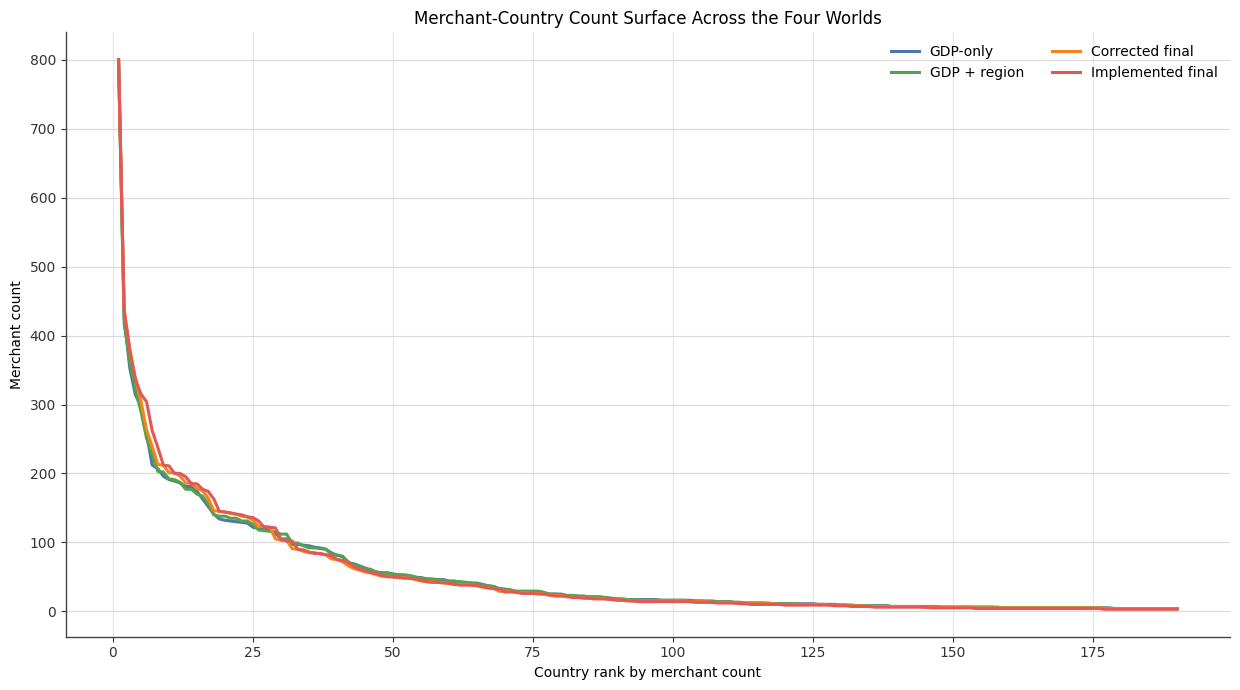

In [31]:
WORLD_COLORS = {
    "GDP-only": "#4C78A8",
    "GDP + region": "#54A24B",
    "Corrected final": "#F58518",
    "Implemented final": "#E45756",
}
EFFECT_COLORS = {
    "Regional uplift": "#54A24B",
    "Heavy-tail uplift": "#F58518",
    "Implementation artifact": "#E45756",
}

world_columns = [
    ("GDP-only", "gdp_only_count"),
    ("GDP + region", "gdp_region_count"),
    ("Corrected final", "corrected_final_count"),
    ("Implemented final", "implemented_final_count"),
]

fig, ax = plt.subplots(figsize=(12.5, 7))
for label, col in world_columns:
    ranked_counts = merchant_allocation_worlds_df[col].sort_values(ascending=False).to_list()
    ranks = np.arange(1, len(ranked_counts) + 1)
    ax.plot(ranks, ranked_counts, linewidth=2.2, color=WORLD_COLORS[label], label=label)

ax.set_title("Merchant-Country Count Surface Across the Four Worlds")
ax.set_xlabel("Country rank by merchant count")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This ranked-surface view answers the broadest version of the question first: how different are these four merchant-country worlds overall? The answer is that they are mostly the same in global shape, with one decisive rupture. GDP-only, GDP + region, and the corrected final policy all trace a very similar steep top-heavy curve, which tells us that the merchant-country world is already strongly concentrated before we even reach the builder's current implemented path. In other words, the basic concentration story is not an accident of one bad line of code; it is authored by the policy itself.

What then changes as we move across the worlds is not the existence of concentration, but its refinement. The regional step slightly lifts selected bloc countries, the corrected final policy concentrates the top end further, and the implemented final path largely sits on top of that same surface except for one visible discontinuity near the early ranks. That discontinuity is the clue that there is an implementation artifact layered on top of an otherwise coherent policy-authored world. So this chart gives us the macro reading: the merchant universe is fundamentally policy-shaped, but not perfectly so at the implemented edge.


**Top-End Zoom**

Now narrow the view to the top 30 ranks so the early-country separation becomes visible.


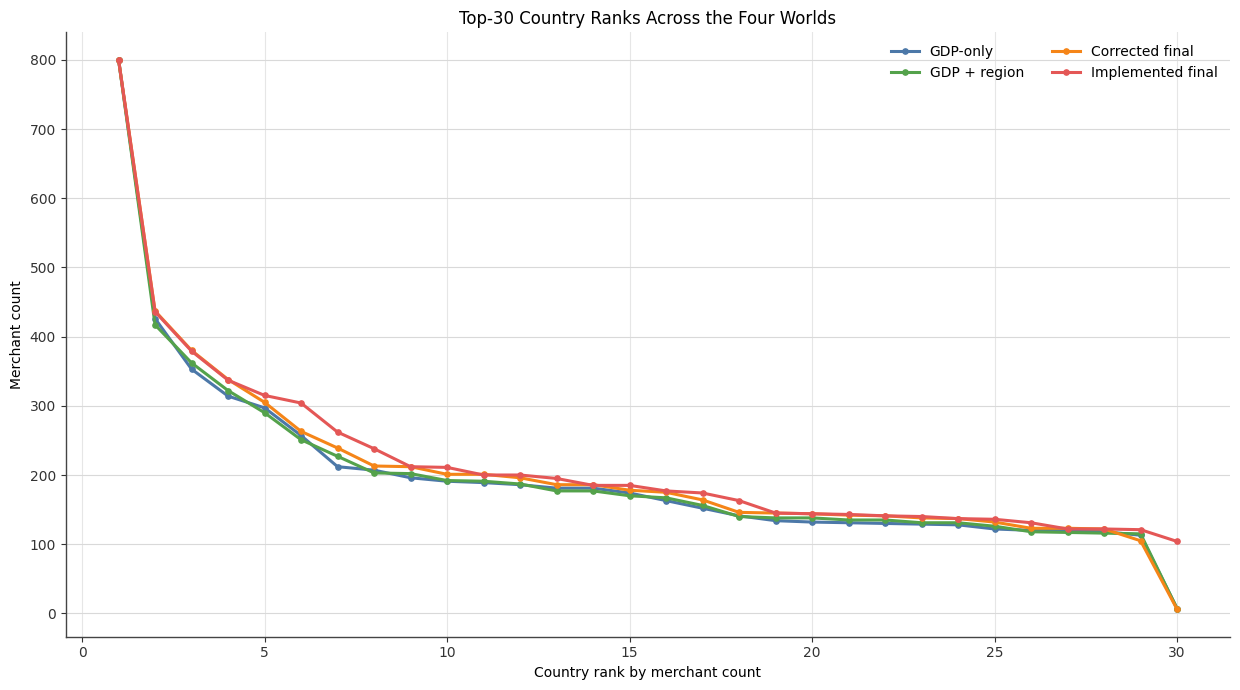

In [32]:
# Zoom into the top end because the full ranked curve compresses the early-rank differences too heavily.
merchant_allocation_top30_rank_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(30).copy()

fig, ax = plt.subplots(figsize=(12.5, 7))
for label, col in world_columns:
    ranked_counts = merchant_allocation_top30_rank_df[col].sort_values(ascending=False).to_list()
    ranks = np.arange(1, len(ranked_counts) + 1)
    ax.plot(ranks, ranked_counts, marker="o", markersize=3.8, linewidth=2.2, color=WORLD_COLORS[label], label=label)

ax.set_title("Top-30 Country Ranks Across the Four Worlds")
ax.set_xlabel("Country rank by merchant count")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This zoomed top-end view makes the refinement story visible in a way the full ranked curve cannot. At the highest ranks, the four worlds are no longer visually collapsed onto one another. `MC` remains fixed across all worlds, which tells us its dominance is already locked in by the base weighted allocation and the cap. Below that, the worlds separate in a structured way: the GDP-only world sits lowest for several leading countries, the regional step lifts selected bloc countries, the corrected final policy pushes the top end further upward, and the implemented final path mostly tracks that corrected surface. That means the top-country world is not being created in one jump; it is being progressively authored in stages.

The other important thing this plot exposes is where the implemented world stops behaving like a smooth refinement of the corrected final world. Around the early ranks, one country breaks away from the otherwise close clustering. So this chart adds a new finding beyond the original ranked surface: the top-country hierarchy is not only concentrated, it is staged, and the implemented path carries one early-rank deviation that is too large to treat as normal policy refinement.


**Rank Differences**

Translate the four worlds into incremental changes by rank so each policy layer can be read directly.


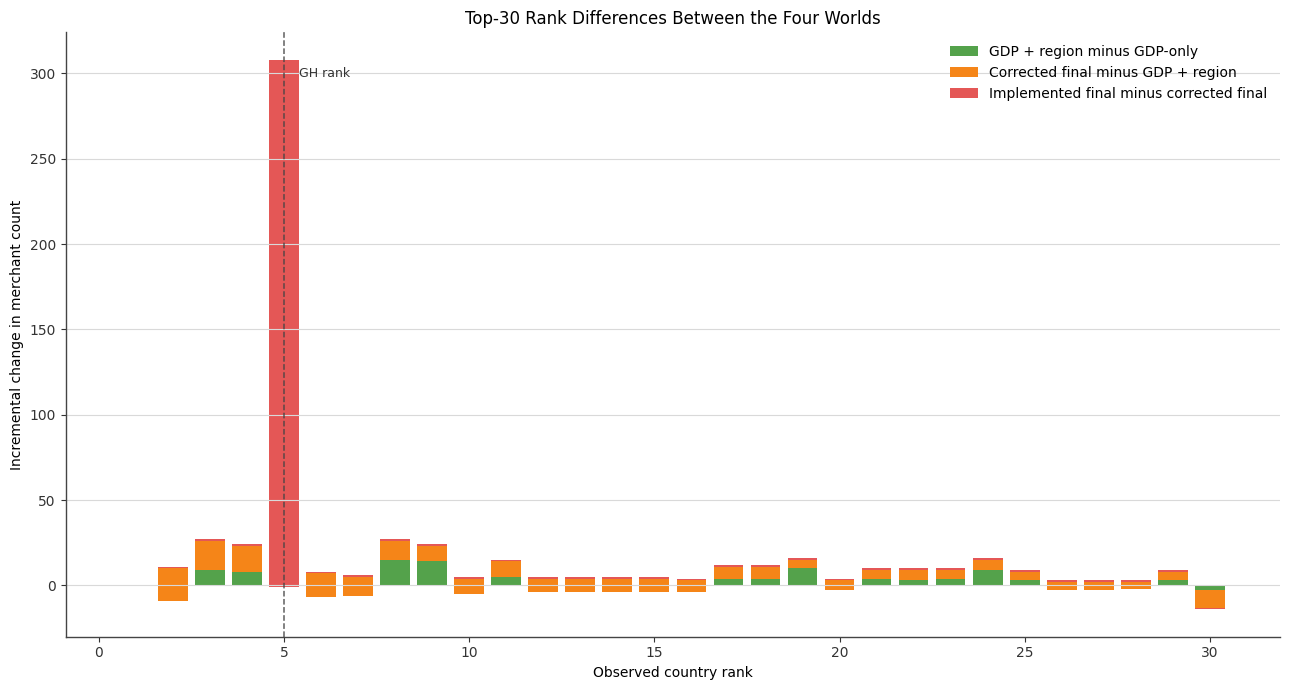

In [33]:
# Convert the world transitions into incremental deltas so the top-end refinement becomes visible by rank.
merchant_allocation_rank_diff_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(30).copy()
merchant_allocation_rank_diff_df["rank"] = np.arange(1, len(merchant_allocation_rank_diff_df) + 1)
merchant_allocation_rank_diff_df["regional_delta"] = merchant_allocation_rank_diff_df["gdp_region_count"] - merchant_allocation_rank_diff_df["gdp_only_count"]
merchant_allocation_rank_diff_df["heavytail_delta"] = merchant_allocation_rank_diff_df["corrected_final_count"] - merchant_allocation_rank_diff_df["gdp_region_count"]
merchant_allocation_rank_diff_df["artifact_delta"] = merchant_allocation_rank_diff_df["implemented_final_count"] - merchant_allocation_rank_diff_df["corrected_final_count"]

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["regional_delta"], color=EFFECT_COLORS["Regional uplift"], edgecolor="none", linewidth=0, label="GDP + region minus GDP-only")
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["heavytail_delta"], bottom=merchant_allocation_rank_diff_df["regional_delta"], color=EFFECT_COLORS["Heavy-tail uplift"], edgecolor="none", linewidth=0, label="Corrected final minus GDP + region")
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["artifact_delta"], bottom=merchant_allocation_rank_diff_df["regional_delta"] + merchant_allocation_rank_diff_df["heavytail_delta"], color=EFFECT_COLORS["Implementation artifact"], edgecolor="none", linewidth=0, label="Implemented final minus corrected final")

gh_rank = int(merchant_allocation_rank_diff_df.loc[merchant_allocation_rank_diff_df["iso"] == "GH", "rank"].iloc[0])
ax.axvline(gh_rank, color="#444444", linestyle="--", linewidth=1.1, alpha=0.85)
ax.text(gh_rank + 0.4, ax.get_ylim()[1] * 0.92, "GH rank", fontsize=9, color="#333333")

ax.set_title("Top-30 Rank Differences Between the Four Worlds")
ax.set_xlabel("Observed country rank")
ax.set_ylabel("Incremental change in merchant count")
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


This rank-difference view translates the four worlds into actual increments, which is what makes the policy mechanics readable. The green regional bars show that the regional step is selective rather than universal; it materially helps a subset of countries rather than the whole top end equally. The orange heavy-tail bars are broader and more systematic, which confirms that the heavy-tail step is the main intended policy mechanism that intensifies concentration after GDP and region have already shaped the world.

The red implemented-minus-corrected bars then show where implementation diverges from intended policy. The marked `GH` rank is the clearest statistical rupture in the entire section: its artifact bar towers above everything else, while the rest of the top-30 countries show almost no implementation distortion by comparison. So this chart is doing more than confirming there is a `GH` problem. It shows that the policy itself has a staged and intelligible structure, and that the builder artifact is sharply localized rather than spread across the whole leading-country set.


**Top 15 Countries**

Read the leading countries directly across the four worlds.


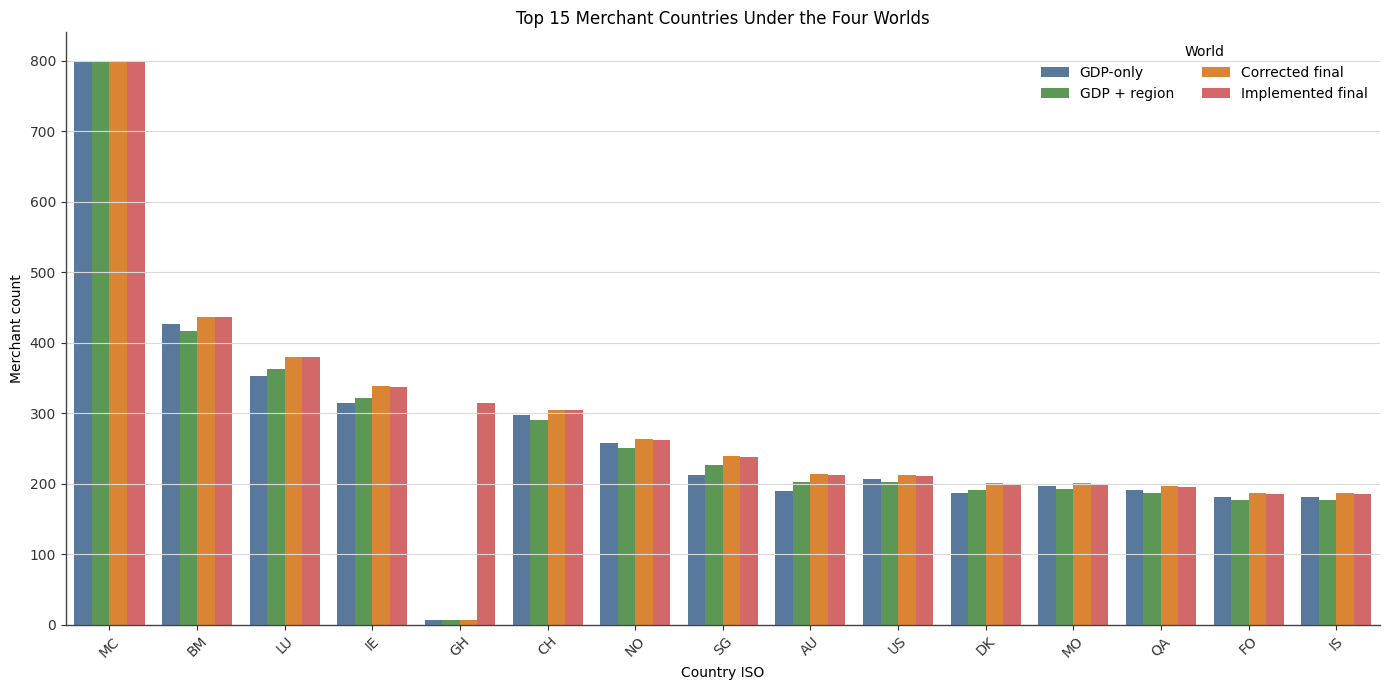

In [34]:
# Restrict to the leading observed countries so we can read the four-world differences directly.
merchant_allocation_top15_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(15).copy()
merchant_allocation_top15_long_df = merchant_allocation_top15_df.melt(
    id_vars=["iso"],
    value_vars=["gdp_only_count", "gdp_region_count", "corrected_final_count", "implemented_final_count"],
    var_name="world",
    value_name="merchant_count",
)
merchant_allocation_top15_long_df["world"] = merchant_allocation_top15_long_df["world"].map({
    "gdp_only_count": "GDP-only",
    "gdp_region_count": "GDP + region",
    "corrected_final_count": "Corrected final",
    "implemented_final_count": "Implemented final",
})

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=merchant_allocation_top15_long_df,
    x="iso",
    y="merchant_count",
    hue="world",
    palette=WORLD_COLORS,
    linewidth=0,
    edgecolor="none",
    ax=ax,
)

ax.set_title("Top 15 Merchant Countries Under the Four Worlds")
ax.set_xlabel("Country ISO")
ax.set_ylabel("Merchant count")
ax.tick_params(axis="x", rotation=45)
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(title="World", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This top-country comparison makes the four-world differences concrete at the country level. It shows that the leading merchant jurisdictions are not all being created in the same way. `MC` is essentially fixed across all four worlds, which means its dominance is already secured by the GDP-weighted base and the cap structure. Countries such as `BM`, `LU`, `IE`, `CH`, `NO`, `SG`, `AU`, and `US` follow a more layered path: GDP-only already places them high, the regional step helps some of them selectively, and the full policy then adds another concentrated uplift. That is the policy behaving as designed.

The country that breaks this pattern is `GH`. In the first three worlds it is essentially absent as a major merchant jurisdiction, but under the implemented final path it jumps into the top-country set. That visual contrast is important because it separates two kinds of top-country prominence. Some countries are genuinely top countries under the authored macro-allocation logic; `GH` becomes a top country only because of the current builder implementation. So this chart is not just comparing bar heights. It is sorting the top-country list into policy-authored countries and implementation-authored anomaly.


**Step Contributions**

Decompose how the regional step, the heavy-tail step, and the implementation artifact move the leading countries.


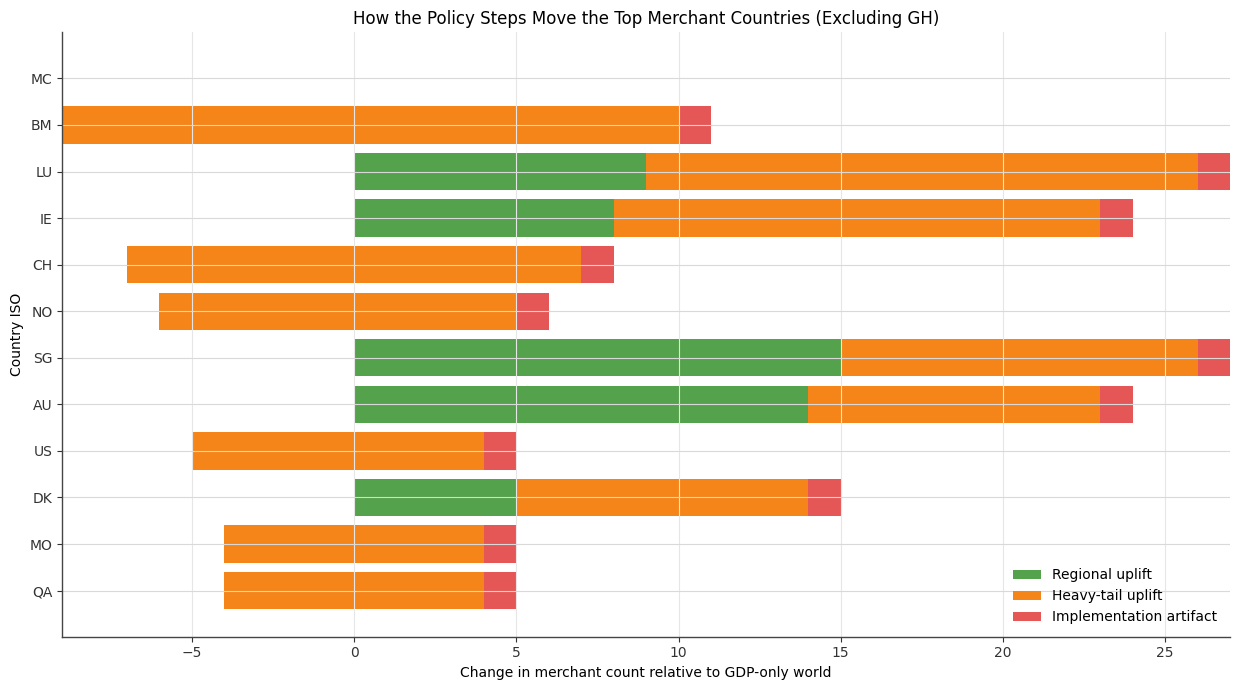

In [35]:
# Remove GH here because its implementation artifact is so large that it flattens the rest of the chart.
merchant_allocation_step_effects_df = (
    merchant_allocation_worlds_df.loc[merchant_allocation_worlds_df["iso"] != "GH", ["iso", "observed_count", "regional_uplift", "heavytail_uplift", "implementation_artifact"]]
    .sort_values("observed_count", ascending=False)
    .head(12)
    .copy()
)

fig, ax = plt.subplots(figsize=(12.5, 7))
left = np.zeros(len(merchant_allocation_step_effects_df))
for column, label in [("regional_uplift", "Regional uplift"), ("heavytail_uplift", "Heavy-tail uplift"), ("implementation_artifact", "Implementation artifact")]:
    values = merchant_allocation_step_effects_df[column].to_numpy()
    ax.barh(merchant_allocation_step_effects_df["iso"], values, left=left, color=EFFECT_COLORS[label], edgecolor="none", linewidth=0, label=label)
    left = left + values

ax.set_title("How the Policy Steps Move the Top Merchant Countries (Excluding GH)")
ax.set_xlabel("Change in merchant count relative to GDP-only world")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


This step-effects view answers the policy question in additive form: once we start from the GDP-only world, which later layers are doing the actual moving? The green regional component is selective and intelligible. It visibly benefits the APAC and EU-linked countries we would expect, such as `SG`, `AU`, `LU`, and `IE`. The orange heavy-tail component is the stronger and more systematic source of extra concentration. It adds to a broad set of already-strong countries, which means the policy is not merely identifying rich countries; it is deliberately intensifying the top end after the GDP and regional stages have already done their work.

The small red implementation-artifact segments for these non-`GH` countries are also important. They tell us that, for most of the leading jurisdictions, the implemented builder is only slightly different from the corrected final policy. So outside the `GH` case, the merchant-country world we see is mostly a faithful realisation of the intended policy. That matters for the investigation because it means we should not overreact and treat the whole top-country structure as corrupted. The dominant pattern for these countries is still authored policy logic, with only minor implementation drift.


**GH Spotlight**

Isolate `GH`, because this is the country where the implemented path diverges most sharply from the intended policy worlds.


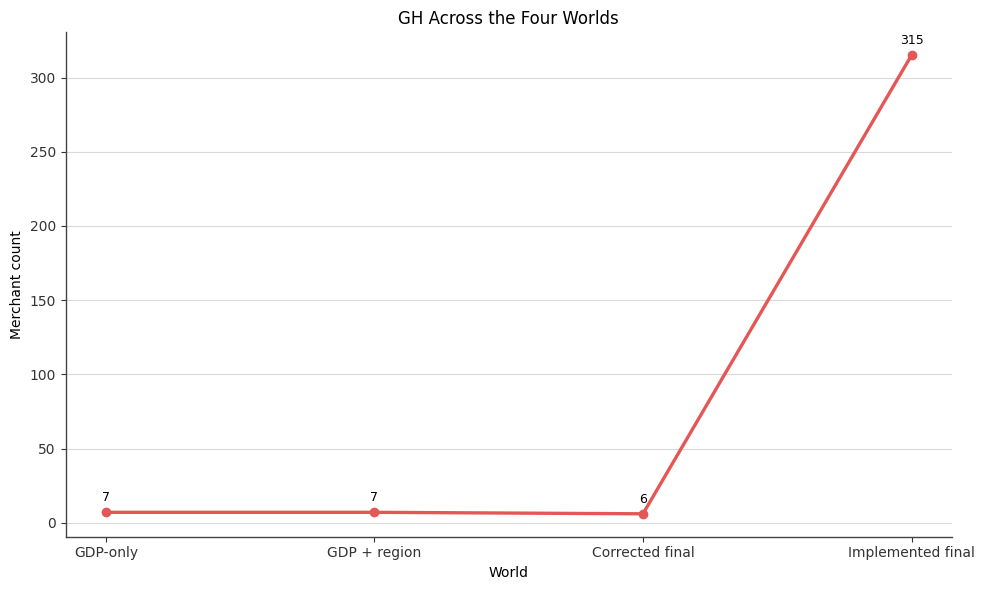

In [36]:
# Isolate GH because it is the country where the implemented path diverges most visibly from the intended policy worlds.
gh_row = merchant_allocation_worlds_df.loc[merchant_allocation_worlds_df["iso"] == "GH"].iloc[0]
gh_worlds = ["GDP-only", "GDP + region", "Corrected final", "Implemented final"]
gh_values = [gh_row["gdp_only_count"], gh_row["gdp_region_count"], gh_row["corrected_final_count"], gh_row["implemented_final_count"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gh_worlds, gh_values, marker="o", linewidth=2.4, color="#E45756")
for x, y in zip(gh_worlds, gh_values):
    ax.annotate(f"{int(y)}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax.set_title("GH Across the Four Worlds")
ax.set_xlabel("World")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=False, grid_y=True)
plt.tight_layout()
plt.show()


This is the cleanest single-country diagnostic in the whole block. `GH` is flat and tiny under the GDP-only world, it stays flat after the regional step, and it remains flat under the corrected final policy. Then the implemented final path sends it sharply upward to `315`. So the visual message is unambiguous: `GH` is not a rich-country effect, not a regional-uplift effect, and not even a legitimate heavy-tail winner under the intended final policy. It is a product of the builder's implemented reconciliation step.

That matters beyond `GH` itself. Earlier in the investigation, `GH` was the awkward low-bucket exception that the GDP and bucket surfaces could not explain. This chart closes that loop. It shows where the exception enters the world: not in the governed macro artefacts, but in the transition from intended policy to implemented builder output. In the context of `1A.S0`, that means the merchant parquet carries both genuine policy structure and a visible pre-engine implementation artifact, and `GH` is the clearest proof of that distinction.


**Builder Artifact**

Compare the implemented final world directly against the corrected final policy to see where the builder changes country counts.


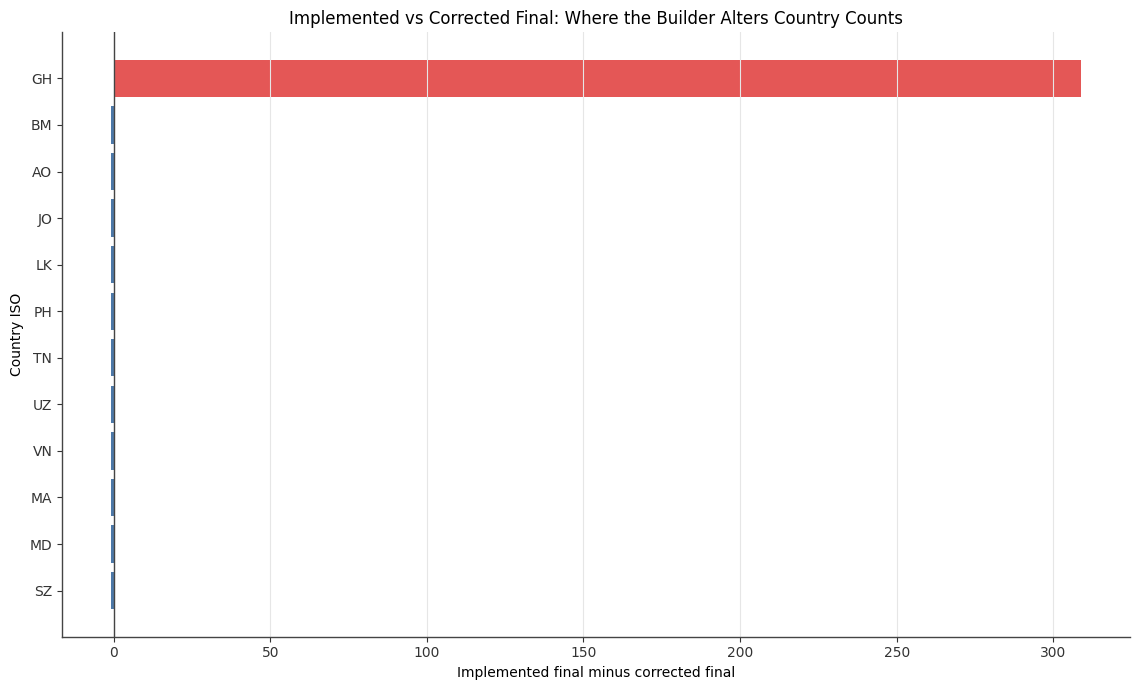

In [37]:
# Compare the implemented builder output directly against the corrected final policy to isolate builder-side drift.
merchant_allocation_artifact_df = merchant_allocation_worlds_df[["iso", "implemented_final_count", "corrected_final_count"]].copy()
merchant_allocation_artifact_df["artifact_delta"] = merchant_allocation_artifact_df["implemented_final_count"] - merchant_allocation_artifact_df["corrected_final_count"]
merchant_allocation_artifact_df = merchant_allocation_artifact_df.loc[merchant_allocation_artifact_df["artifact_delta"] != 0].sort_values("artifact_delta", ascending=False)
merchant_allocation_artifact_display_df = merchant_allocation_artifact_df.head(12).copy()

fig, ax = plt.subplots(figsize=(11.5, 7))
colors = ["#E45756" if value > 0 else "#4C78A8" for value in merchant_allocation_artifact_display_df["artifact_delta"]]
ax.barh(merchant_allocation_artifact_display_df["iso"], merchant_allocation_artifact_display_df["artifact_delta"], color=colors, edgecolor="none", linewidth=0)
ax.axvline(0, color="#444444", linewidth=1.0)
ax.set_title("Implemented vs Corrected Final: Where the Builder Alters Country Counts")
ax.set_xlabel("Implemented final minus corrected final")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


This artifact view answers the narrow builder question directly: where does the implemented final world differ from the corrected final policy world? Visually, almost the entire chart is one story. `GH` dominates the difference surface, while every other visible country sits almost flat by comparison. So the implementation problem is not a diffuse wobble across many leading countries; it is a single-country distortion with overwhelming weight.

That is important for the broader investigation because it prevents us from over-reading the policy as broadly corrupted. The merchant-country world is still largely policy-authored. What this chart shows is that one implementation choice in the builder is injecting a large outlier into an otherwise coherent authoring path. In other words, the current merchant parquet is not globally unreliable; it is locally distorted in a very specific and highly visible way.


**Builder Drift Outside GH**

Remove `GH` so the residual builder drift on the rest of the country world becomes readable.


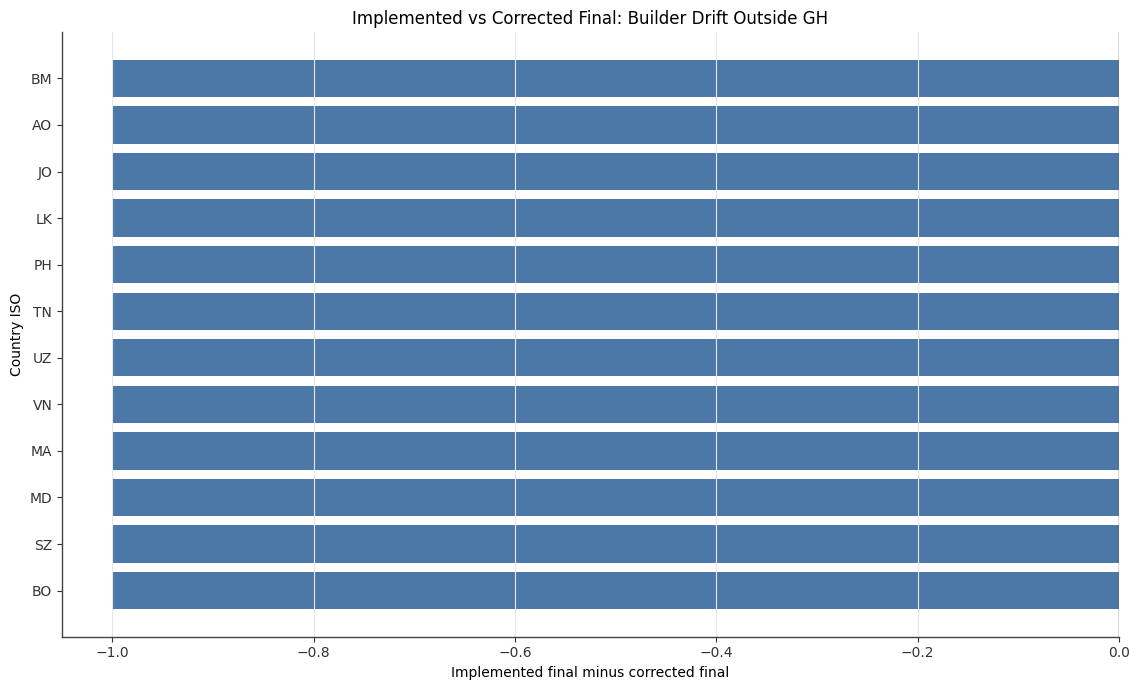

In [38]:
# Remove GH so the residual builder drift on the rest of the leading countries becomes visible.
merchant_allocation_artifact_ex_gh_df = merchant_allocation_artifact_df.loc[merchant_allocation_artifact_df["iso"] != "GH"].head(12).copy()

fig, ax = plt.subplots(figsize=(11.5, 7))
colors = ["#E45756" if value > 0 else "#4C78A8" for value in merchant_allocation_artifact_ex_gh_df["artifact_delta"]]
ax.barh(merchant_allocation_artifact_ex_gh_df["iso"], merchant_allocation_artifact_ex_gh_df["artifact_delta"], color=colors, edgecolor="none", linewidth=0)
ax.axvline(0, color="#444444", linewidth=1.0)
ax.set_title("Implemented vs Corrected Final: Builder Drift Outside GH")
ax.set_xlabel("Implemented final minus corrected final")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Once `GH` is removed, the remaining builder drift becomes legible. The striking result is how small and regular it is. The leading countries shown here are almost all shifted by exactly `-1` relative to the corrected final policy. That means the builder is not randomly perturbing the rest of the country world in large or uneven ways. Outside the `GH` case, the implemented final world is effectively the corrected final world with a nearly uniform one-count shortfall spread across the remaining countries.

This matters because it sharpens the policy diagnosis. The implemented builder is not creating many country-specific anomalies; it is creating one major anomaly and then a near-uniform residual offset elsewhere. So when we interpret the top-country structure for `1A.S0`, we should treat the non-`GH` leading countries as substantially faithful to the intended policy, while isolating `GH` as the country where the implemented path genuinely changes the statistical story.


**What This Shows:** This block now gives a fuller answer to what the merchant-allocation policy is doing before `1A.S0` ingests the merchant universe. GDP-per-capita weighting creates the base top-heavy country world, the regional multipliers selectively strengthen favored blocs, and the heavy-tail step further intensifies already-strong countries. So the merchant-country concentration we observed earlier is genuinely policy-authored rather than an accidental property of the parquet. The additional plots make that staged construction visible rather than implied. They show the top end separating progressively across the worlds, and they show the incremental contribution of each policy layer by rank.

At the same time, the added artifact views sharpen the second half of the story. The implemented builder does not broadly scramble the intended policy world. Instead, it introduces one dominant distortion through `GH`, while the rest of the countries sit very close to the corrected final policy, largely with a near-uniform one-count shortfall. So the merchant parquet carries two truths at once: a country-allocation world that is substantively authored by governed policy, and a sharply localized pre-engine implementation artifact that materially inflates one country. That is the distinction we now need to carry forward as we continue deeper into `1A`.


#### A.4: `transaction_schema_merchant_ids.bootstrap.yaml`

We then checked the sealed bootstrap policy because `1A.S0` still treats it as part of the governed ingress lineage for `transaction_schema_merchant_ids`.

The important finding is that the bootstrap artefact still matters for lineage and documentation, but it is not the best direct explanation of the active `2026-01-03` merchant parquet. The active parquet behaves much more like it was authored by the newer builder path using `merchant_allocation.1A.yaml` and `channel_policy.1A.yaml`.

The full Watson-side investigation, including the documentary trail and parquet-facing tests for country, MCC, and channel behaviour, is here:

- [transaction_schema_bootstrap_policy_first_read.md](../watson_workbench/notes/transaction_schema_bootstrap_policy_first_read.md)


**What This Shows:** For the current investigation, the bootstrap policy is still relevant because it remains part of the sealed `S0` governance story. But analytically it is more useful as evidence of an earlier or intended authoring posture than as the primary explanatory policy for the active merchant parquet. That tells us the governed world currently carries a split story: bootstrap remains in lineage, while the active merchant authoring logic appears to have moved to the newer allocation and channel policy surfaces.


#### A.5: `channel_policy.1A.yaml`

With the bootstrap question resolved, the next active authoring surface for the merchant parquet is the channel policy.

The question in this block is straightforward:

- how does `config/layer1/1A/policy/channel_policy.1A.yaml` shape the `card_present` / `card_not_present` world we see in `transaction_schema_merchant_ids`

This policy is part of the current builder path rather than merely a sealed lineage artefact. The builder uses it to:

- assign an initial default channel by MCC band
- rebalance each ISO into an allowed CNP corridor
- verify that the final global channel mix stays within governed bounds

The fuller Watson-side note is here:

- [channel_policy_first_read.md](../watson_workbench/notes/channel_policy_first_read.md)


The parquet-facing findings are unusually clean for this policy.

First, the global channel posture fits the governed bounds comfortably. The active merchant snapshot has `2527` `card_not_present` merchants and `7473` `card_present` merchants, which gives a global CNP ratio of `0.2527`. That sits well inside the policy's allowed global `card_not_present` corridor of `0.10` to `0.40`.

Second, the configured MCC bands behave almost exactly the way the policy says they should. The CNP-default bands `4800-4899`, `5960-5969`, `5990-5999`, and `7390-7399` are all effectively near-total CNP in the active parquet, while the broad default world outside those bands is much more CP-heavy. So the policy is not just correlated with the data; it is visibly authoring a two-tier channel world.

Third, the ISO-level rebalance is clearly visible. For most large non-override countries, the observed CNP ratio sits almost exactly at `0.25`. That matches the builder's midpoint logic for the default country corridor, because the policy allows `0.10` to `0.40` CNP and the midpoint is therefore `0.25`. Countries such as `MC`, `BM`, `LU`, `IE`, `GH`, `CH`, `NO`, `SG`, and `AU` all sit at or extremely close to that value.

Finally, the explicit ISO overrides are also visible in the data. `US` and `GB` do not sit at the default `0.25` posture; instead they align closely with the midpoints of their own override corridors. That means the override logic is not merely present in code. It is expressed in the merchant parquet itself.


**What This Shows:** `channel_policy.1A.yaml` is one of the clearest active authoring policies in the merchant parquet. It explains the global CP/CNP balance, the near-total CNP posture of the configured MCC bands, and the repeated `~25%` CNP ratio across most large non-override countries. It also explains why `US` and `GB` sit at visibly different channel levels. So unlike the bootstrap artefact, this policy fits the active parquet directly and strongly. The merchant universe's channel world is not loosely related to governed policy; it is tightly authored by it.

---


#### Segment 1A.S1

![1A-S1-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S1-design-flow.png)
[1A-S1-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S1-design-flow.png)

`S1` is the first state where `1A` stops merely carrying the merchant world forward and starts making a governed decision about it.

At this point, the question is no longer just what merchants exist. The question becomes: which merchants remain on the single-site path, and which merchants are allowed to enter the multi-site construction path?

Formally, `S1` evaluates a logistic hurdle per merchant and emits the authoritative Bernoulli branch decision: `is_multi = true` or `false`. That decision then governs which downstream `1A` RNG surfaces are allowed to exist for that merchant. So `S1` is the first true branch gate inside Segment `1A`.

For our purposes, the job in this state is to understand three things clearly:

- what predictor world `S1` is acting on
- what governed artefact supplies the hurdle logic
- what output surface records the actual single-site vs multi-site split


The relevant surfaces in `S1` are much narrower than they were in `S0`. The key ones are:

- `hurdle_design_matrix`
  - the merchant-level predictor basis that `S1` reads
  - this is the compact merchant world as seen by the hurdle model

- `hurdle_coefficients.yaml`
  - the operative model artefact for the hurdle decision
  - this carries the frozen dictionaries and coefficient vector that define the branch logic

- `hurdle_pi_probs`
  - optional diagnostic surface
  - useful for investigation, but not the authoritative decision record

- `rng_event_hurdle_bernoulli`
  - the authoritative `S1` output
  - this is the actual merchant-by-merchant branch decision surface

- `rng_trace_log`
  - the cumulative RNG trace for the hurdle stream
  - relevant because `S1` is both a model state and an RNG-governed state

- `rng_audit_log`
  - the run-level RNG audit context that must already exist before `S1` can emit hurdle events

The upstream merchant-world inputs from `S0` still matter in the background, especially `transaction_schema_merchant_ids`, GDP, and the GDP bucket map. But in `S1`, those are no longer the main focus. What matters now is their processed effect inside the design matrix and the branch decision that follows from it.


##### `hurdle_simulation.priors.yaml`: first orientation

Before we move into the active hurdle coefficients and the emitted `S1` branch world, it helps to briefly introduce the upstream file that explains how that hurdle world was originally authored: `hurdle_simulation.priors.yaml`.

This file is not the runtime authority of `S1`. Rather, it is the governed simulation recipe used upstream to create the synthetic hurdle training world and the NB-count training world from which the hurdle coefficient bundle was later fit.

The fuller Watson workbench investigation lives here:

- [hurdle_priors_investigation.md](../watson_workbench/notes/hurdle_priors_investigation.md)

For the notebook, the immediate goal is narrower: open the file, see its structure, and get a first sense of what kind of authored object it is before we move into the plots and the statistical story it supports.


In [39]:
# Import YAML here because this is the first point in the notebook where we inspect a model-authoring file directly.
import yaml

# Point to the exact priors file that explains how the hurdle training world was authored upstream.
hurdle_priors_path = ROOT / "config" / "layer1" / "1A" / "models" / "hurdle" / "hurdle_simulation.priors.yaml"

# Load the YAML into a Python dictionary so we can inspect its structure before generating any plots.
with open(hurdle_priors_path, "r", encoding="utf-8") as handle:
    hurdle_priors = yaml.safe_load(handle)

# Summarize the top-level sections first so we can see what kind of object this file is.
hurdle_priors_summary_df = pd.DataFrame(
    [
        {
            "section": key,
            "python_type": type(value).__name__,
            "entries": len(value) if isinstance(value, (dict, list)) else 1,
        }
        for key, value in hurdle_priors.items()
    ]
).sort_values("section").reset_index(drop=True)

# Echo the exact file being read so the notebook stays tied to the governed artefact we are discussing.
print(f"hurdle_priors_path: {hurdle_priors_path}")
print(f"top_level_section_count: {len(hurdle_priors)}")

hurdle_priors_summary_df


hurdle_priors_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\config\layer1\1A\models\hurdle\hurdle_simulation.priors.yaml
top_level_section_count: 9


,section,python_type,entries
0,calibration,dict,6
1,clamps,dict,3
2,dispersion,dict,6
3,hurdle,dict,5
4,nb_mean,dict,4
5,noise,dict,3
6,rng,dict,2
7,semver,str,1
8,version,str,1


##### Priors plot setup

The next cells bring the hurdle-priors visual logic directly into the notebook. The code mirrors the Watson workbench generator, but is adapted to render inline here so we can inspect the figures statefully as part of the walkthrough.


In [40]:
# Import the extra packages needed for the priors visual walkthrough.
import json
import polars as pl

# Match the visual style used in the Watson workbench so the notebook and workspace stay aligned.
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

HURDLE_PRIORS_COLORS = {
    "guide": "#657b83",
    "current": "#1d5f8c",
    "high": "#c26d2d",
    "cp": "#2a6f97",
    "cnp": "#c96f3d",
    "positive": "#2a9d8f",
    "negative": "#d1495b",
    "corridor": "#6c757d",
    "actual": "#1f77b4",
    "original": "#4c78a8",
    "active": "#d3722c",
}


# Use the same axis styling across the priors figures so comparisons stay visually consistent.
def style_hurdle_priors_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#222")
    ax.spines["bottom"].set_color("#222")
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(colors="#222", labelsize=10)
    ax.title.set_fontsize(14)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    ax.grid(axis="x", visible=False)


# Expand MCC range declarations like "1000-1999" into numeric tuples that are easier to work with.
def hurdle_priors_parse_ranges(items):
    parsed = []
    for item in items:
        lo, hi = str(item["range"]).split("-", 1)
        parsed.append((int(lo), int(hi), float(item["offset"])))
    return parsed


# Rebuild the authored MCC offset surface exactly as the priors define it: range effects plus direct overrides.
def hurdle_priors_mcc_map(direct, ranges, mcc_values):
    direct_map = {int(k): float(v) for k, v in direct.items()}
    offsets = np.zeros(len(mcc_values), dtype=float)
    for i, code in enumerate(mcc_values):
        total = direct_map.get(int(code), 0.0)
        for lo, hi, delta in ranges:
            if lo <= code <= hi:
                total += delta
        offsets[i] = total
    return offsets


# Align channel offsets against the merchant-level CP/CNP labels used in the synthetic world.
def hurdle_priors_channel_map(direct, channels):
    mapping = {str(k): float(v) for k, v in direct.items()}
    return np.array([mapping.get(ch, 0.0) for ch in channels], dtype=float)


# Align GDP-bucket offsets against the merchant-level bucket ids.
def hurdle_priors_bucket_map(direct, buckets):
    mapping = {int(k): float(v) for k, v in direct.items()}
    return np.array([mapping.get(int(b), 0.0) for b in buckets], dtype=float)


# Use the same logistic map as the workbench when turning latent hurdle scores into probabilities.
def hurdle_priors_sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


# Apply corridor clamps in the same way the simulation code does.
def hurdle_priors_clip(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)


# Weighted median is needed for the dispersion calibration target because phi uses a median, not a mean.
def hurdle_priors_weighted_median(values, weights):
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights)
    cutoff = 0.5 * cumulative[-1]
    idx = np.searchsorted(cumulative, cutoff, side="left")
    return float(values[min(idx, len(values) - 1)])


# Load the sealed merchant world and enrich it with the GDP and bucket context used by the synthetic authoring route.
def load_hurdle_priors_merchant_context():
    merchant_path = ROOT / "reference/layer1/transaction_schema_merchant_ids/2026-01-03/transaction_schema_merchant_ids.parquet"
    gdp_path = ROOT / "reference/economic/world_bank_gdp_per_capita/2025-04-15/gdp.parquet"
    bucket_path = ROOT / "reference/economic/gdp_bucket_map/2024/gdp_bucket_map.parquet"
    iso_path = ROOT / "reference/iso/iso3166_canonical/2024-12-31/iso3166.parquet"

    merchants = pl.read_parquet(merchant_path).sort("merchant_id").with_columns(
        pl.when(pl.col("channel") == "card_present")
        .then(pl.lit("CP"))
        .when(pl.col("channel") == "card_not_present")
        .then(pl.lit("CNP"))
        .otherwise(pl.col("channel"))
        .alias("channel")
    )
    gdp = pl.read_parquet(gdp_path).filter(pl.col("observation_year") == 2024)
    buckets = pl.read_parquet(bucket_path).select(["country_iso", "bucket_id"])
    iso = pl.read_parquet(iso_path).select(["country_iso"]).with_columns(pl.lit(1).alias("iso_present"))

    merchants = merchants.join(gdp.select(["country_iso", "gdp_pc_usd_2015"]), left_on="home_country_iso", right_on="country_iso", how="left")
    if "country_iso" in merchants.columns:
        merchants = merchants.drop("country_iso")
    merchants = merchants.join(buckets, left_on="home_country_iso", right_on="country_iso", how="left")
    if "country_iso" in merchants.columns:
        merchants = merchants.drop("country_iso")
    merchants = merchants.join(iso, left_on="home_country_iso", right_on="country_iso", how="left")
    if "country_iso" in merchants.columns:
        merchants = merchants.drop("country_iso")
    if "iso_present" in merchants.columns:
        merchants = merchants.drop("iso_present")

    merchants = merchants.with_columns(pl.col("gdp_pc_usd_2015").log().alias("ln_gdp_pc_usd_2015"))
    return merchants


# Build the reusable merchant-level context once so all priors figures talk about the same authored world.
def build_hurdle_priors_context():
    pri = hurdle_priors
    merchants = load_hurdle_priors_merchant_context()
    rng = np.random.default_rng(int(pri["rng"]["seed"]))

    channel = np.array(merchants["channel"].to_list(), dtype=object)
    mcc = np.array(merchants["mcc"].to_list(), dtype=int)
    gdp_bucket = np.array(merchants["bucket_id"].to_list(), dtype=int)
    ln_gdp = np.array(merchants["ln_gdp_pc_usd_2015"].to_list(), dtype=float)

    h = pri["hurdle"]
    n = pri["nb_mean"]
    d = pri["dispersion"]
    noise = pri["noise"]
    clamps = pri["clamps"]

    return {
        "pri": pri,
        "merchants": merchants,
        "channel": channel,
        "mcc": mcc,
        "gdp_bucket": gdp_bucket,
        "ln_gdp": ln_gdp,
        "h_mcc": hurdle_priors_mcc_map(h.get("mcc_offsets", {}), hurdle_priors_parse_ranges(h.get("mcc_range_offsets", [])), mcc),
        "n_mcc": hurdle_priors_mcc_map(n.get("mcc_offsets", {}), hurdle_priors_parse_ranges(n.get("mcc_range_offsets", [])), mcc),
        "d_mcc": hurdle_priors_mcc_map(d.get("mcc_offsets", {}), hurdle_priors_parse_ranges(d.get("mcc_range_offsets", [])), mcc),
        "h_ch": hurdle_priors_channel_map(h.get("channel_offsets", {}), channel),
        "n_ch": hurdle_priors_channel_map(n.get("channel_offsets", {}), channel),
        "d_ch": hurdle_priors_channel_map(d.get("channel_offsets", {}), channel),
        "h_b": hurdle_priors_bucket_map(h.get("bucket_offsets", {}), gdp_bucket),
        "noise_logit": rng.normal(0.0, float(noise.get("per_merchant_logit_sd", 0.0)), size=len(channel)),
        "noise_mu": rng.normal(0.0, float(noise.get("per_merchant_log_mu_sd", 0.0)), size=len(channel)),
        "noise_phi": rng.normal(0.0, float(noise.get("per_merchant_log_phi_sd", 0.0)), size=len(channel)),
        "clamps": {
            "pi_lo": float(clamps["pi"]["min"]),
            "pi_hi": float(clamps["pi"]["max"]),
            "mu_lo": float(clamps["mu"]["min"]),
            "mu_hi": float(clamps["mu"]["max"]),
            "phi_lo": float(clamps["phi"]["min"]),
            "phi_hi": float(clamps["phi"]["max"]),
        },
    }


# Recreate the bounded calibration solve so the notebook can show how the priors targets become actual base levels.
def solve_hurdle_priors_calibration(ctx, target_pi, target_mu, target_phi, iters=64):
    pri = ctx["pri"]
    d = pri["dispersion"]
    calib = pri["calibration"]
    h_ch, h_b, h_mcc = ctx["h_ch"], ctx["h_b"], ctx["h_mcc"]
    n_ch, n_mcc = ctx["n_ch"], ctx["n_mcc"]
    d_ch, d_mcc = ctx["d_ch"], ctx["d_mcc"]
    noise_logit, noise_mu, noise_phi = ctx["noise_logit"], ctx["noise_mu"], ctx["noise_phi"]
    ln_gdp = ctx["ln_gdp"]
    pi_lo, pi_hi = ctx["clamps"]["pi_lo"], ctx["clamps"]["pi_hi"]
    mu_lo_clip, mu_hi_clip = ctx["clamps"]["mu_lo"], ctx["clamps"]["mu_hi"]
    phi_lo_clip, phi_hi_clip = ctx["clamps"]["phi_lo"], ctx["clamps"]["phi_hi"]

    logit_lo, logit_hi = calib["brackets"]["base_logit"]
    mu_lo, mu_hi = calib["brackets"]["base_log_mean"]
    phi_lo, phi_hi = calib["brackets"]["base_log_phi"]

    for _ in range(iters):
        mid = 0.5 * (logit_lo + logit_hi)
        eta = mid + h_ch + h_b + h_mcc + noise_logit
        pi = hurdle_priors_sigmoid(eta)
        if pi.mean() > target_pi:
            logit_hi = mid
        else:
            logit_lo = mid
    base_logit = 0.5 * (logit_lo + logit_hi)

    for _ in range(iters):
        mid = 0.5 * (mu_lo + mu_hi)
        log_mu = mid + n_ch + n_mcc + noise_mu
        mu = hurdle_priors_clip(np.exp(log_mu), mu_lo_clip, mu_hi_clip)
        eta = base_logit + h_ch + h_b + h_mcc + noise_logit
        pi = hurdle_priors_sigmoid(eta)
        weighted_mean = float(np.average(mu, weights=pi))
        if weighted_mean > target_mu:
            mu_hi = mid
        else:
            mu_lo = mid
    base_log_mean = 0.5 * (mu_lo + mu_hi)

    for _ in range(iters):
        mid = 0.5 * (phi_lo + phi_hi)
        log_phi = mid + float(d.get("gdp_log_slope", 0.0)) * ln_gdp + d_ch + d_mcc + noise_phi
        phi = hurdle_priors_clip(np.exp(log_phi), phi_lo_clip, phi_hi_clip)
        eta = base_logit + h_ch + h_b + h_mcc + noise_logit
        pi = hurdle_priors_sigmoid(eta)
        med = hurdle_priors_weighted_median(phi, pi)
        if med > target_phi:
            phi_hi = mid
        else:
            phi_lo = mid
    base_log_phi = 0.5 * (phi_lo + phi_hi)

    eta = base_logit + h_ch + h_b + h_mcc + noise_logit
    pi = hurdle_priors_clip(hurdle_priors_sigmoid(eta), pi_lo, pi_hi)
    mu = hurdle_priors_clip(np.exp(base_log_mean + n_ch + n_mcc + noise_mu), mu_lo_clip, mu_hi_clip)
    phi = hurdle_priors_clip(np.exp(base_log_phi + float(d.get("gdp_log_slope", 0.0)) * ln_gdp + d_ch + d_mcc + noise_phi), phi_lo_clip, phi_hi_clip)

    return {
        "base_logit": base_logit,
        "base_log_mean": base_log_mean,
        "base_log_phi": base_log_phi,
        "mean_pi": float(pi.mean()),
        "weighted_mean_mu": float(np.average(mu, weights=pi)),
        "weighted_median_phi": hurdle_priors_weighted_median(phi, pi),
        "pi": pi,
        "mu": mu,
        "phi": phi,
    }


# Keep the notebook helpers close to the workbench versions, but render inline here instead of saving to disk.
def hurdle_priors_top_offsets(mapping, top_n=12):
    items = [(str(k), float(v)) for k, v in mapping.items()]
    pos = sorted([x for x in items if x[1] > 0], key=lambda x: x[1], reverse=True)[: top_n // 2]
    neg = sorted([x for x in items if x[1] < 0], key=lambda x: x[1])[: top_n - len(pos)]
    return pos + neg


def plot_hurdle_priors_authoring_flow():
    fig, ax = plt.subplots(figsize=(15, 4.8))
    ax.axis("off")
    boxes = [
        (0.03, 0.35, 0.18, 0.34, "Priors\nhurdle_simulation.priors.yaml"),
        (0.25, 0.35, 0.18, 0.34, "Synthetic Corpus\nlogistic.parquet\nnb_mean.parquet"),
        (0.47, 0.35, 0.18, 0.34, "Original Export\n2026-01-03 bundle"),
        (0.69, 0.35, 0.12, 0.34, "P1b\n+2.2 hurdle\nintercept"),
        (0.84, 0.35, 0.12, 0.34, "Active Bundle\n2026-02-14"),
    ]
    for x, y, w, h, text in boxes:
        patch = plt.Rectangle((x, y), w, h, facecolor="#f7f7f7", edgecolor="#222", linewidth=1.2)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=12)
    arrows = [((0.21, 0.52), (0.25, 0.52)), ((0.43, 0.52), (0.47, 0.52)), ((0.65, 0.52), (0.69, 0.52)), ((0.81, 0.52), (0.84, 0.52))]
    for start, end in arrows:
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=2, color="#333"))
    ax.text(0.34, 0.78, "offline simulation + fit", ha="center", va="center", fontsize=11, color="#444")
    ax.text(0.75, 0.78, "governed remediation", ha="center", va="center", fontsize=11, color="#444")
    ax.set_title("From Priors to the Active Hurdle Bundle", fontsize=16, pad=12)
    plt.show()


def plot_hurdle_priors_calibration_scenarios(ctx):
    scenarios = {
        "Guide Example": (0.12, 5.0, 22.0, HURDLE_PRIORS_COLORS["guide"]),
        "Current Priors": (0.16, 6.5, 45.0, HURDLE_PRIORS_COLORS["current"]),
        "Late-Dec High": (0.16, 9.0, 45.0, HURDLE_PRIORS_COLORS["high"]),
    }
    solved = {label: solve_hurdle_priors_calibration(ctx, a, b, c) for label, (a, b, c, _) in scenarios.items()}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    labels = list(scenarios.keys())
    x = np.arange(len(labels))
    width = 0.22
    target_series = [[scenarios[l][0] for l in labels], [scenarios[l][1] for l in labels], [scenarios[l][2] for l in labels]]
    target_names = ["mean_pi_target", "mean_mu_target_multi", "median_phi_target"]
    bars_colors = [HURDLE_PRIORS_COLORS["guide"], HURDLE_PRIORS_COLORS["current"], HURDLE_PRIORS_COLORS["high"]]

    ax = axes[0]
    for i, (series, name, col) in enumerate(zip(target_series, target_names, bars_colors)):
        ax.bar(x + (i - 1) * width, series, width=width, label=name, color=col, edgecolor="none")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12, ha="right")
    ax.set_title("Calibration Targets Across Priors Postures")
    ax.set_ylabel("Target Value")
    ax.legend(frameon=False, fontsize=9)
    style_hurdle_priors_axes(ax)

    ax = axes[1]
    solved_series = [[solved[l]["base_logit"] for l in labels], [solved[l]["base_log_mean"] for l in labels], [solved[l]["base_log_phi"] for l in labels]]
    for i, (series, name, col) in enumerate(zip(solved_series, ["base_logit", "base_log_mean", "base_log_phi"], bars_colors)):
        ax.bar(x + (i - 1) * width, series, width=width, label=name, color=col, edgecolor="none")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12, ha="right")
    ax.set_title("Solved Base Levels After Calibration")
    ax.set_ylabel("Solved Base Value")
    ax.legend(frameon=False, fontsize=9)
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_calibration_response_curves(ctx):
    pri = ctx["pri"]
    d = pri["dispersion"]
    calib = pri["calibration"]
    h_ch, h_b, h_mcc = ctx["h_ch"], ctx["h_b"], ctx["h_mcc"]
    n_ch, n_mcc = ctx["n_ch"], ctx["n_mcc"]
    d_ch, d_mcc = ctx["d_ch"], ctx["d_mcc"]
    noise_logit, noise_mu, noise_phi = ctx["noise_logit"], ctx["noise_mu"], ctx["noise_phi"]
    ln_gdp = ctx["ln_gdp"]
    mu_lo_clip, mu_hi_clip = ctx["clamps"]["mu_lo"], ctx["clamps"]["mu_hi"]
    phi_lo_clip, phi_hi_clip = ctx["clamps"]["phi_lo"], ctx["clamps"]["phi_hi"]

    solved = solve_hurdle_priors_calibration(ctx, float(calib["mean_pi_target"]), float(calib["mean_mu_target_multi"]), float(calib["median_phi_target"]))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    xs = np.linspace(calib["brackets"]["base_logit"][0], calib["brackets"]["base_logit"][1], 120)
    ys = []
    for x in xs:
        eta = x + h_ch + h_b + h_mcc + noise_logit
        ys.append(hurdle_priors_sigmoid(eta).mean())
    ax = axes[0]
    ax.plot(xs, ys, color=HURDLE_PRIORS_COLORS["current"], linewidth=2.5)
    ax.axhline(calib["mean_pi_target"], color=HURDLE_PRIORS_COLORS["negative"], linestyle="--", linewidth=1.5)
    ax.axvline(solved["base_logit"], color="#222", linestyle=":", linewidth=1.5)
    ax.set_title("Calibrating base_logit")
    ax.set_xlabel("base_logit")
    ax.set_ylabel("mean(pi)")
    style_hurdle_priors_axes(ax)

    xs = np.linspace(calib["brackets"]["base_log_mean"][0], calib["brackets"]["base_log_mean"][1], 120)
    ys = []
    eta = solved["base_logit"] + h_ch + h_b + h_mcc + noise_logit
    pi = hurdle_priors_sigmoid(eta)
    for x in xs:
        mu = hurdle_priors_clip(np.exp(x + n_ch + n_mcc + noise_mu), mu_lo_clip, mu_hi_clip)
        ys.append(float(np.average(mu, weights=pi)))
    ax = axes[1]
    ax.plot(xs, ys, color=HURDLE_PRIORS_COLORS["current"], linewidth=2.5)
    ax.axhline(calib["mean_mu_target_multi"], color=HURDLE_PRIORS_COLORS["negative"], linestyle="--", linewidth=1.5)
    ax.axvline(solved["base_log_mean"], color="#222", linestyle=":", linewidth=1.5)
    ax.set_title("Calibrating base_log_mean")
    ax.set_xlabel("base_log_mean")
    ax.set_ylabel("weighted mean(mu)")
    style_hurdle_priors_axes(ax)

    xs = np.linspace(calib["brackets"]["base_log_phi"][0], calib["brackets"]["base_log_phi"][1], 120)
    ys = []
    for x in xs:
        phi = hurdle_priors_clip(np.exp(x + float(d.get("gdp_log_slope", 0.0)) * ln_gdp + d_ch + d_mcc + noise_phi), phi_lo_clip, phi_hi_clip)
        ys.append(hurdle_priors_weighted_median(phi, pi))
    ax = axes[2]
    ax.plot(xs, ys, color=HURDLE_PRIORS_COLORS["current"], linewidth=2.5)
    ax.axhline(calib["median_phi_target"], color=HURDLE_PRIORS_COLORS["negative"], linestyle="--", linewidth=1.5)
    ax.axvline(solved["base_log_phi"], color="#222", linestyle=":", linewidth=1.5)
    ax.set_title("Calibrating base_log_phi")
    ax.set_xlabel("base_log_phi")
    ax.set_ylabel("weighted median(phi)")
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_clamp_effects(ctx):
    pri = ctx["pri"]
    d = pri["dispersion"]
    calib = pri["calibration"]
    solved = solve_hurdle_priors_calibration(ctx, float(calib["mean_pi_target"]), float(calib["mean_mu_target_multi"]), float(calib["median_phi_target"]))

    h_ch, h_b, h_mcc = ctx["h_ch"], ctx["h_b"], ctx["h_mcc"]
    n_ch, n_mcc = ctx["n_ch"], ctx["n_mcc"]
    d_ch, d_mcc = ctx["d_ch"], ctx["d_mcc"]
    noise_logit, noise_mu, noise_phi = ctx["noise_logit"], ctx["noise_mu"], ctx["noise_phi"]
    ln_gdp = ctx["ln_gdp"]

    raw_pi = hurdle_priors_sigmoid(solved["base_logit"] + h_ch + h_b + h_mcc + noise_logit)
    raw_mu = np.exp(solved["base_log_mean"] + n_ch + n_mcc + noise_mu)
    raw_phi = np.exp(solved["base_log_phi"] + float(d.get("gdp_log_slope", 0.0)) * ln_gdp + d_ch + d_mcc + noise_phi)
    clamped_pi = hurdle_priors_clip(raw_pi, ctx["clamps"]["pi_lo"], ctx["clamps"]["pi_hi"])
    clamped_mu = hurdle_priors_clip(raw_mu, ctx["clamps"]["mu_lo"], ctx["clamps"]["mu_hi"])
    clamped_phi = hurdle_priors_clip(raw_phi, ctx["clamps"]["phi_lo"], ctx["clamps"]["phi_hi"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    specs = [
        ("pi", raw_pi, clamped_pi, ctx["clamps"]["pi_lo"], ctx["clamps"]["pi_hi"]),
        ("mu", raw_mu, clamped_mu, ctx["clamps"]["mu_lo"], ctx["clamps"]["mu_hi"]),
        ("phi", raw_phi, clamped_phi, ctx["clamps"]["phi_lo"], ctx["clamps"]["phi_hi"]),
    ]
    for ax, (name, raw, clamped, lo, hi) in zip(axes, specs):
        ax.hist(raw, bins=40, color=HURDLE_PRIORS_COLORS["guide"], alpha=0.45, label="raw", edgecolor="none")
        ax.hist(clamped, bins=40, color=HURDLE_PRIORS_COLORS["current"], alpha=0.7, label="clamped", edgecolor="none")
        ax.axvline(lo, color=HURDLE_PRIORS_COLORS["negative"], linestyle="--", linewidth=1.2)
        ax.axvline(hi, color=HURDLE_PRIORS_COLORS["negative"], linestyle="--", linewidth=1.2)
        ax.set_title(f"{name}: Raw vs Clamped")
        ax.set_xlabel(name)
        ax.set_ylabel("Merchants")
        style_hurdle_priors_axes(ax)
        ax.legend(frameon=False, fontsize=9)
    plt.show()


def plot_hurdle_priors_bucket_ladder(pri):
    node = pri["hurdle"]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    buckets = list(node["bucket_offsets"].keys())
    vals = [node["bucket_offsets"][k] for k in buckets]
    ax.plot(buckets, vals, color=HURDLE_PRIORS_COLORS["current"], linewidth=3, marker="o", markersize=8)
    ax.axhline(0, color="#222", linewidth=1)
    ax.set_title("Hurdle GDP-Bucket Ladder in the Priors")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("Hurdle offset")
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_authored_offsets(pri, section_name):
    node = pri[section_name]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.8))

    ax = axes[0]
    ch_items = list(node["channel_offsets"].items())
    colors = [HURDLE_PRIORS_COLORS["cp"] if k == "CP" else HURDLE_PRIORS_COLORS["cnp"] for k, _ in ch_items]
    ax.bar([k for k, _ in ch_items], [v for _, v in ch_items], color=colors, edgecolor="none")
    ax.axhline(0, color="#222", linewidth=1)
    ax.set_title(f"{section_name}: Channel Offsets")
    ax.set_ylabel("Offset")
    style_hurdle_priors_axes(ax)

    ax = axes[1]
    ranges = node.get("mcc_range_offsets", [])
    labels = [r["range"] for r in ranges]
    vals = [float(r["offset"]) for r in ranges]
    colors = [HURDLE_PRIORS_COLORS["positive"] if v >= 0 else HURDLE_PRIORS_COLORS["negative"] for v in vals]
    ax.barh(labels, vals, color=colors, edgecolor="none")
    ax.axvline(0, color="#222", linewidth=1)
    ax.set_title(f"{section_name}: MCC Range Offsets")
    ax.set_xlabel("Offset")
    style_hurdle_priors_axes(ax)

    ax = axes[2]
    items = hurdle_priors_top_offsets(node.get("mcc_offsets", {}), top_n=12)
    labels = [k for k, _ in items]
    vals = [v for _, v in items]
    colors = [HURDLE_PRIORS_COLORS["positive"] if v >= 0 else HURDLE_PRIORS_COLORS["negative"] for v in vals]
    ax.barh(labels, vals, color=colors, edgecolor="none")
    ax.axvline(0, color="#222", linewidth=1)
    ax.set_title(f"{section_name}: Explicit MCC Overrides")
    ax.set_xlabel("Offset")
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_training_outputs():
    logistic_path = ROOT / "artefacts/training/1A/hurdle_sim/simulation_version=2026-01-03/seed=9248923/20260103T184840Z/logistic.parquet"
    nb_path = ROOT / "artefacts/training/1A/hurdle_sim/simulation_version=2026-01-03/seed=9248923/20260103T184840Z/nb_mean.parquet"
    logistic = pl.read_parquet(logistic_path)
    nb = pl.read_parquet(nb_path)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

    ax = axes[0]
    hurdle_counts = logistic.group_by("y_hurdle").len().sort("y_hurdle")
    labels = ["single (0)", "multi (1)"]
    vals = hurdle_counts["len"].to_list()
    ax.bar(labels, vals, color=[HURDLE_PRIORS_COLORS["corridor"], HURDLE_PRIORS_COLORS["current"]], edgecolor="none")
    ax.set_title("Synthetic Hurdle Output")
    ax.set_ylabel("Merchants")
    style_hurdle_priors_axes(ax)

    ax = axes[1]
    bucket_multi = logistic.group_by("gdp_bucket").agg(pl.mean("y_hurdle").alias("multi_rate")).sort("gdp_bucket")
    ax.plot(bucket_multi["gdp_bucket"].to_list(), bucket_multi["multi_rate"].to_list(), color=HURDLE_PRIORS_COLORS["current"], linewidth=3, marker="o")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Synthetic Multi-Site Rate by GDP Bucket")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("Multi-site rate")
    style_hurdle_priors_axes(ax)

    ax = axes[2]
    nb_counts = nb["y_nb"].to_list()
    bins = np.arange(2, min(max(nb_counts) + 2, 26))
    ax.hist(nb_counts, bins=bins, color=HURDLE_PRIORS_COLORS["current"], edgecolor="none", alpha=0.9)
    ax.set_title("Synthetic Multi-Site Outlet Counts")
    ax.set_xlabel("y_nb")
    ax.set_ylabel("Merchants")
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_corridor_selfcheck():
    selfcheck_path = ROOT / "config/layer1/1A/models/hurdle/exports/version=2026-01-03/20260103T184840Z/bundle_selfcheck.json"
    selfcheck = json.loads(selfcheck_path.read_text(encoding="utf-8"))
    metrics = [
        ("mean_pi", selfcheck["mean_pi"], 0.05, 0.30),
        ("q90_mu", selfcheck["q90_mu"], 3.0, 40.0),
        ("median_phi", selfcheck["median_phi"], 12.0, 80.0),
        ("rho_hat", selfcheck["rho_hat"], 0.0, 0.055),
        ("max_infl", selfcheck["max_infl"], 0.0, 1.20),
        ("max_p_rej", selfcheck["max_p_rej"], 0.0, 0.25),
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    labels = [m[0] for m in metrics]
    y = np.arange(len(metrics))
    for i, (_, actual, lo, hi) in enumerate(metrics):
        ax.hlines(i, lo, hi, color="#cfcfcf", linewidth=8, zorder=1)
        ax.plot(actual, i, "o", color=HURDLE_PRIORS_COLORS["current"], markersize=9, zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title("January Export Belt-and-Braces Corridor Check")
    ax.set_xlabel("Metric value (gray band = allowed corridor)")
    style_hurdle_priors_axes(ax)
    plt.show()


def plot_hurdle_priors_origin_vs_active():
    original_bundle_path = ROOT / "config/layer1/1A/models/hurdle/exports/version=2026-01-03/20260103T184840Z/hurdle_coefficients.yaml"
    active_bundle_path = ROOT / "config/layer1/1A/models/hurdle/exports/version=2026-02-14/20260214T173000Z/hurdle_coefficients.yaml"
    original_bundle = yaml.safe_load(original_bundle_path.read_text(encoding="utf-8"))
    active_bundle = yaml.safe_load(active_bundle_path.read_text(encoding="utf-8"))

    run_events_path = ROOT / "runs/local_full_run-7/a3bd8cac9a4284cd36072c6b9624a0c1/logs/layer1/1A/rng/events/hurdle_bernoulli/seed=42/parameter_hash=0ea66cf0adf1c64bbaad68e566d1e49be502d771df78c608a4d2c23887d60f00/run_id=a3bd8cac9a4284cd36072c6b9624a0c1/part-00000.jsonl"
    mean_pi_active_run = np.mean([json.loads(line)["pi"] for line in run_events_path.read_text(encoding="utf-8").splitlines() if line.strip()])
    original_selfcheck_path = ROOT / "config/layer1/1A/models/hurdle/exports/version=2026-01-03/20260103T184840Z/bundle_selfcheck.json"
    mean_pi_original_export = json.loads(original_selfcheck_path.read_text(encoding="utf-8"))["mean_pi"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    ax = axes[0]
    ax.bar(["original export", "active run"], [original_bundle["beta"][0], active_bundle["beta"][0]], color=[HURDLE_PRIORS_COLORS["original"], HURDLE_PRIORS_COLORS["active"]], edgecolor="none")
    ax.set_title("Hurdle Intercept: Original vs Active")
    ax.set_ylabel("Intercept value")
    style_hurdle_priors_axes(ax)

    ax = axes[1]
    ax.bar(["original export", "active run"], [mean_pi_original_export, mean_pi_active_run], color=[HURDLE_PRIORS_COLORS["original"], HURDLE_PRIORS_COLORS["active"]], edgecolor="none")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Mean Hurdle Probability: Original vs Active")
    ax.set_ylabel("Mean pi")
    style_hurdle_priors_axes(ax)
    plt.show()


In [ ]:
# Build the shared simulation context once so the priors figures all inspect the same authored merchant world.
hurdle_priors_ctx = build_hurdle_priors_context()


: 

: 

: 

###### 1. From authored priors to solved calibration posture

Start by locating the priors file in the authoring flow, then inspect the calibration targets and the response surfaces they imply.

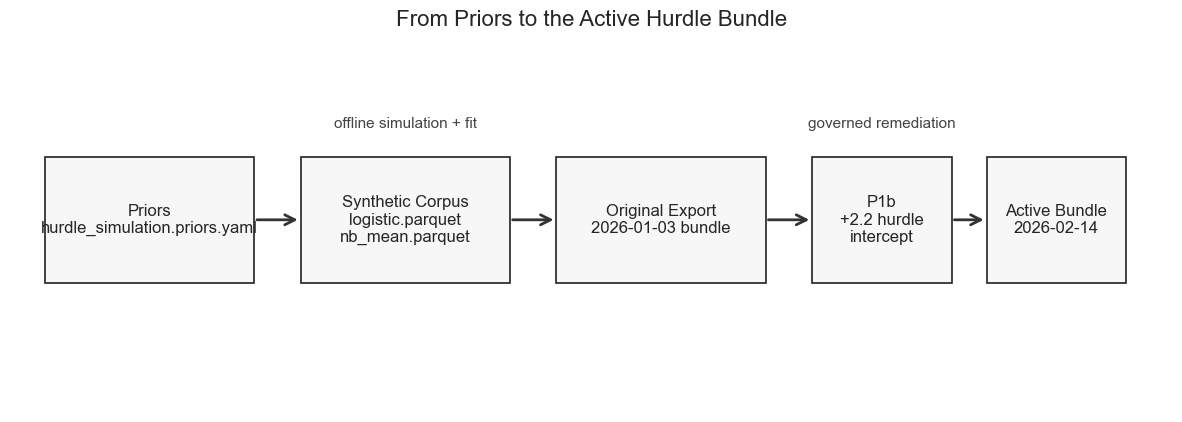

In [41]:
# Show where the priors sit in the synthetic authoring chain before we inspect the solved targets themselves.
plot_hurdle_priors_authoring_flow()


This opening figure is not a statistical distribution, but it is still analytically necessary because it tells us what question the rest of the priors section is actually answering. The priors file does not act directly on the active engine run. It first authors a synthetic merchant world, that world is emitted into the two synthetic training surfaces `logistic.parquet` and `nb_mean.parquet`, those training surfaces produce the original `2026-01-03` export bundle, and only after that does the family move through a later governed remediation into the active `2026-02-14` bundle.

So this figure gives us the correct posture for reading every later plot. We are not simply asking, "what values are inside the priors YAML?" We are asking, "what kind of synthetic world was this YAML trying to create, what training surfaces did that world produce, and how much of that original authored world still survives in the active run?" Without this frame, the later figures would be easy to misread as though the priors numerically explain the active run directly.

The split in the figure between `offline simulation + fit` and `governed remediation` is especially important. The left side is the original synthetic authoring route. The right side is the later intervention route. That means the priors investigation has two jobs at once: first, recover the original synthetic design logic; second, keep track of where that logic was later overridden.

In [42]:
# Authoring and calibration overview: where the priors sit and what the calibration targets are solving for.
plot_hurdle_priors_calibration_scenarios(hurdle_priors_ctx)

NameError: name 'hurdle_priors_ctx' is not defined

This figure is the first real statistical statement about the priors. The left panel shows that the current priors posture is not just the guide example copied forward unchanged. Relative to the lower guide-style posture, the current priors raise the intended branch density from `0.12` to `0.16`, raise the intended multi-site count scale from `5.0` to `6.5`, and raise the intended dispersion level from `22` to `45`. The `Late-Dec High` posture then shows what happened during the harder corridor-management phase: the branch target stayed at `0.16`, the dispersion target stayed at `45`, but the count target was pushed even higher to `9.0`.

The right panel then shows the consequence of those target decisions. Once the script solves for the baselines numerically, the hurdle intercept posture becomes meaningfully less negative than the guide example, the count baseline moves upward, and the dispersion baseline moves upward even more strongly. In other words, changing the calibration targets really does move the center of mass of the synthetic world. These targets are not decorative metadata; they are control knobs.

The comparison also gives us a first clue about the hierarchy of concern in the authoring process. The largest target jump is not in `mean_pi_target`; it is in `median_phi_target`. That already tells us the count world, and especially its dispersion stability, was a major concern in the tuning trail. The synthetic world was not merely being tuned to create enough multi-site merchants. It was also being tuned to avoid a brittle or pathological count regime.

In [43]:
plot_hurdle_priors_calibration_response_curves(hurdle_priors_ctx)

NameError: name 'hurdle_priors_ctx' is not defined

These response curves unpack the calibration mechanics instead of just telling us the final answers. Each panel asks the same question: if we slide the corresponding baseline through its allowed bracket, how does the synthetic merchant world respond? The important statistical property is that each relationship is monotone in the direction we would expect. Raising `base_logit` raises mean `pi`; raising `base_log_mean` raises the multi-site-weighted mean of `mu`; raising `base_log_phi` raises the multi-site-weighted median of `phi`.

That monotonicity matters because the export script is solving these values numerically. If the surfaces were unstable, non-monotone, or flat in the wrong region, then the calibration targets would be poorly identified. Instead, the curves show that the merchant universe and the authored offsets provide a clean enough response surface for bounded search to work reproducibly.

The visual markers are also doing real analytical work. The dashed red lines are the target levels; the dotted vertical lines are the solved baselines. So in the current priors posture, the solver is effectively selecting the baseline that makes the synthetic branch world average to about `0.16`, the synthetic admitted-count world average to about `6.5`, and the synthetic dispersion world median to about `45`. This is especially revealing in the `phi` panel: the target is reached in the rising part of the curve, but not very far from the region where the surface begins to steepen sharply toward the upper corridor. That tells us the dispersion lane was being tuned close enough to its ceiling behavior that later clamping and corridor checks would become operationally relevant.

There is also an implementation nuance embedded in what these panels measure. The script is not solving `mu` and `phi` on a hard thresholded subset only. It is solving them on multi-site-weighted global surfaces. So these curves are showing the practical implementation posture of the exporter, not just the looser conceptual wording from the guide.

###### 2. The authored hurdle contour and its guardrails

With the solved posture in view, inspect the clamp mechanics, the bucket ladder, and the authored hurdle offsets that shape the synthetic hurdle world.

In [44]:
# Clamp mechanics and the authored hurdle contour.
plot_hurdle_priors_clamp_effects(hurdle_priors_ctx)

NameError: name 'hurdle_priors_ctx' is not defined

This figure tells us whether the declared corridors are merely emergency rails or whether they are actively shaping the emitted synthetic world. The answer is mixed, and that distinction matters. In the `pi` panel, the raw and clamped distributions are almost indistinguishable. The lower floor at `0.01` and the upper cap at `0.75` exist, but the raw hurdle world already lives comfortably inside that range. So for the hurdle branch lane, the corridor is mostly a preventive safety structure rather than a major sculpting force.

The `mu` panel is more consequential. There is visible accumulation right at the lower floor around `4.0`, which means the synthetic count world would naturally like to produce more mass below that value, but the corridor is preventing it. This is not cosmetic. It means the priors plus merchant noise would otherwise generate a lower-count regime than the exporter is willing to tolerate. The floor is actively lifting the left tail of the multi-site count world.

The `phi` panel shows a different kind of intervention. Instead of pressure against a lower floor, we see compression toward the upper ceiling at `80.0`. The raw dispersion world wants to extend further into a high-dispersion tail, but the clamp is shaving that tail back. So the corridor is functioning as a cap on how heterogeneous the synthetic count world is allowed to become.

Taken together, these three panels show that the priors are authoring a bounded world, but not all bounds are equally active. The hurdle probability corridor is light-touch. The count and dispersion corridors are much more operational. That is one reason the later tuning trail focused so heavily on `mu` floors and `phi` targets.

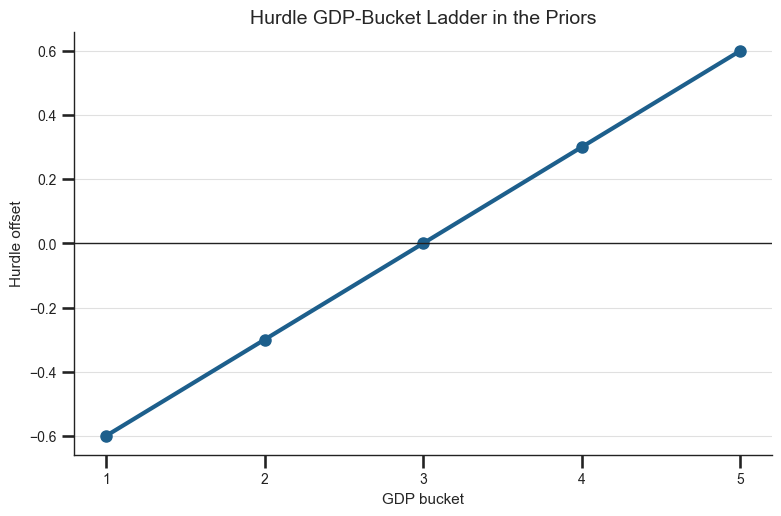

In [45]:
plot_hurdle_priors_bucket_ladder(hurdle_priors)

This bucket ladder is the cleanest macroeconomic statement in the hurdle priors. The five GDP buckets are not treated as arbitrary labels. They are arranged into a strictly ordered ladder: bucket `1` is assigned `-0.60`, bucket `2` `-0.30`, bucket `3` is neutral, bucket `4` is `+0.30`, and bucket `5` is `+0.60`. The equal step size is important. It means the priors are authoring a smooth directional progression rather than a jagged country-group heuristic.

Analytically, this is where the continuous GDP surface that we inspected earlier is compressed into a discrete hurdle law. Once a merchant has been assigned a GDP bucket, the branch world no longer sees the full continuous GDP value. It sees this five-step ladder. So this plot is the bridge between the macroeconomic reference artefacts in `S0` and the merchant-level branch world that the hurdle trainer emits.

The statistical consequence is straightforward but powerful: lower-GDP-country merchants are systematically pushed away from the multi-site branch, higher-GDP-country merchants are systematically pulled toward it, and the middle bucket acts as the neutral anchor. This is not something learned from transactions. It is a governed economic prior imposed on the synthetic world before fitting ever begins.

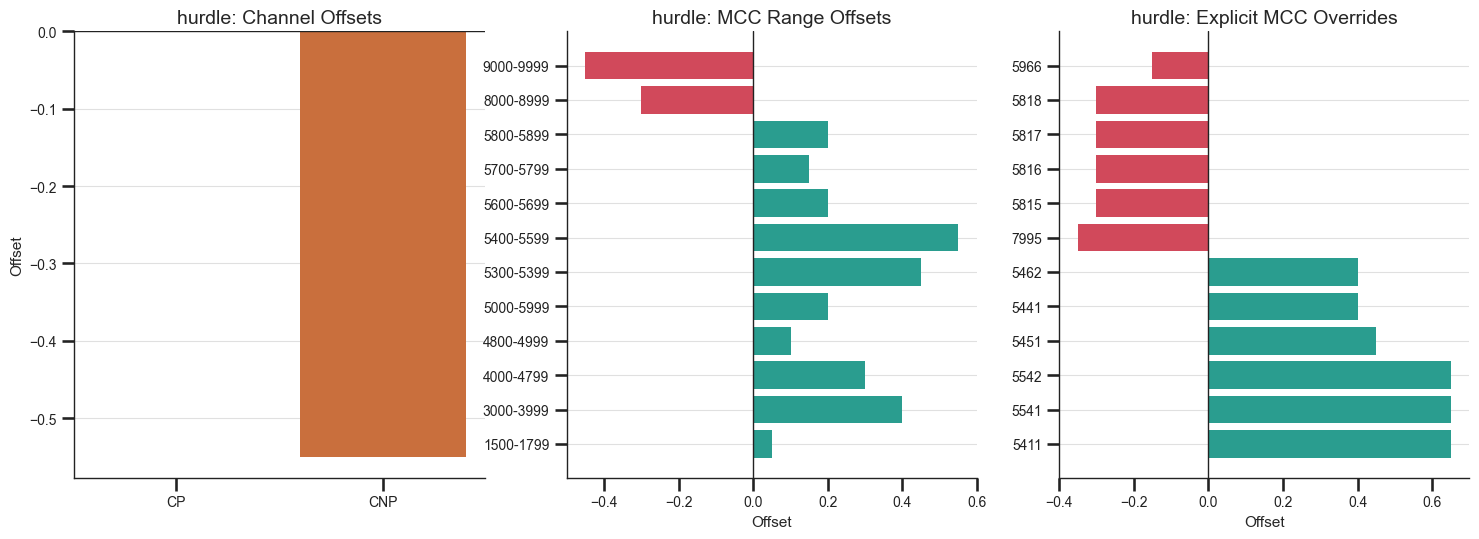

In [46]:
plot_hurdle_priors_authored_offsets(hurdle_priors, "hurdle")

If the GDP bucket ladder is the macro contour, this figure is the micro-commercial contour. Start with the channel panel. `CP` is left at zero, while `CNP` is given a large negative hurdle offset of `-0.55`. That is a strong authored asymmetry. Before noise, before calibration, and before any fit, card-not-present merchants are structurally less likely to enter the multi-site branch than otherwise comparable card-present merchants.

The MCC range panel then adds sectoral shape. Several merchant families receive positive branch lift, especially `5300-5399`, `5400-5599`, and parts of `3000-3999` and `4000-4799`. Others are pushed down, most clearly `8000-8999` and `9000-9999`. So the hurdle branch world is already differentiating between merchant sectors that are more chain-like or outlet-like and sectors that are less so.

The explicit MCC override panel sharpens that further. Specific codes such as `5411`, `5541`, and `5542` are given strong positive lift, while codes like `7995` and several `58xx` subcodes are pushed down. This matters because it shows the priors are not only drawing broad range-level tendencies. They are also correcting or emphasizing particular merchant categories that the authors considered important enough to override directly.

The statistical reality here is that the hurdle world is deliberately selective. The synthetic branch law is not trying to make the merchant universe broadly homogeneous and then let noise do the work. It is pre-structuring the universe so that some merchant types are intrinsically more branch-admissible than others. This is one of the clearest pieces of evidence that the priors file is an authored world recipe.

###### 3. The other authored lanes: NB mean and dispersion

The priors file does not only shape the hurdle gate. It also authors the mean-count and dispersion lanes that later feed the synthetic count world.

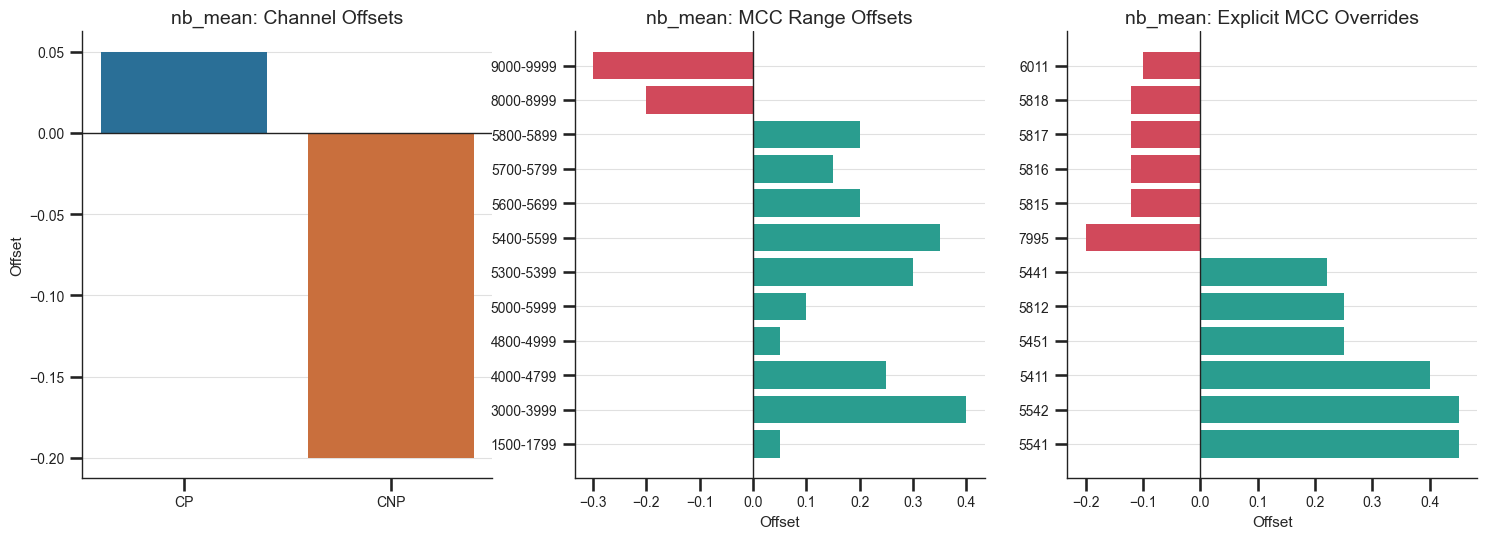

In [47]:
# The other two authored lanes carried by the priors: NB mean and dispersion.
plot_hurdle_priors_authored_offsets(hurdle_priors, "nb_mean")

This figure answers a different question from the hurdle offsets. The hurdle lane asked who gets admitted onto the multi-site branch. The NB-mean lane asks, once a merchant is already admitted, how large should its outlet-count world tend to be? The first thing the plot shows is that channel matters here too, but more mildly. `CP` gets a small positive offset of `+0.05` and `CNP` a moderate negative offset of `-0.20`. That is much gentler than the hurdle channel split.

That difference is analytically useful. It tells us the priors are separating branch admission logic from scale logic. Channel is being used strongly to decide whether a merchant is multi-site at all, but once a merchant has crossed that gate, channel has a smaller role in determining the typical size of its outlet-count world.

Most of the NB-mean structure therefore sits in MCC. The range panel lifts parts of `3000-3999`, `4000-4799`, `5300-5399`, and `5400-5599`, while depressing `8000-8999` and `9000-9999`. The explicit overrides then sharpen certain merchant categories, with strong positive support for `5541`, `5542`, and `5411`, and negative support for codes such as `6011` and `7995`.

What this means statistically is that the priors are authoring a count world where some types of merchants are not only more likely to be multi-site, but are also expected to sustain larger outlet counts once they are multi-site. So the synthetic corpus is carrying forward commercial structure from branch admission into branch magnitude.

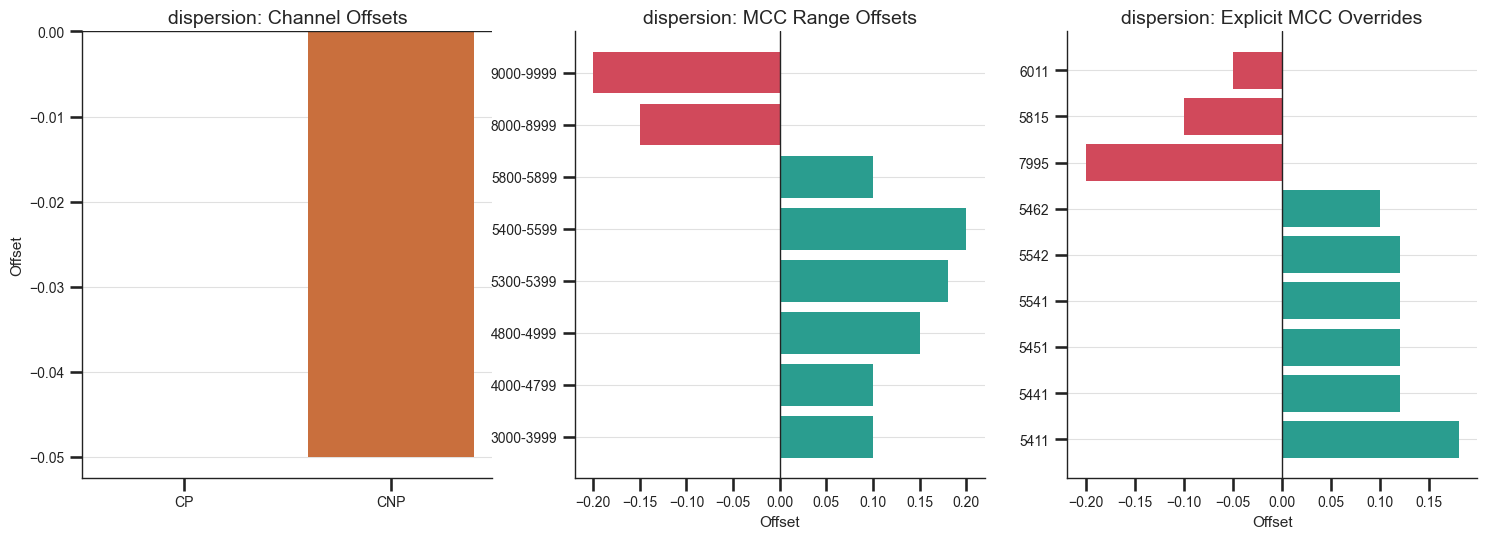

In [48]:
plot_hurdle_priors_authored_offsets(hurdle_priors, "dispersion")

The dispersion lane is subtler than the other two, and that is exactly why this plot matters. It is easy to think only in terms of branch rate and mean count, but the priors are also deciding how spread out, noisy, or heterogeneous the synthetic count world is allowed to be. The channel panel shows almost no positive `CP` effect and only a small negative `CNP` effect of about `-0.05`. So channel is barely being used to differentiate dispersion.

The MCC panels are also narrower in magnitude than the hurdle or NB-mean equivalents. There are still positive lifts in selected merchant families, especially parts of `53xx` and `54xx`, and there are still negative pushes in families like `8xxx`, `9xxx`, and explicit overrides such as `7995`. But the scale of those effects is tighter. The priors are authoring dispersion, just with a lighter hand.

That lighter hand is itself a design decision. It implies that the synthetic world is being allowed to vary in count spread, but not so violently that dispersion starts overwhelming the rest of the commercial structure. This is also why the corridor and the `median_phi_target` become so important later: the dispersion lane is controlled not only by these offsets, but by the GDP-log slope, the solved baseline, and the corridor ceiling. The plot isolates the offset contribution and shows that it is deliberately modest.

###### 4. What the priors emit and where the active run later diverges

Close by looking at the synthetic training outputs the priors are meant to produce, the corridor self-check, and the gap between the original authored world and the active run we are investigating.

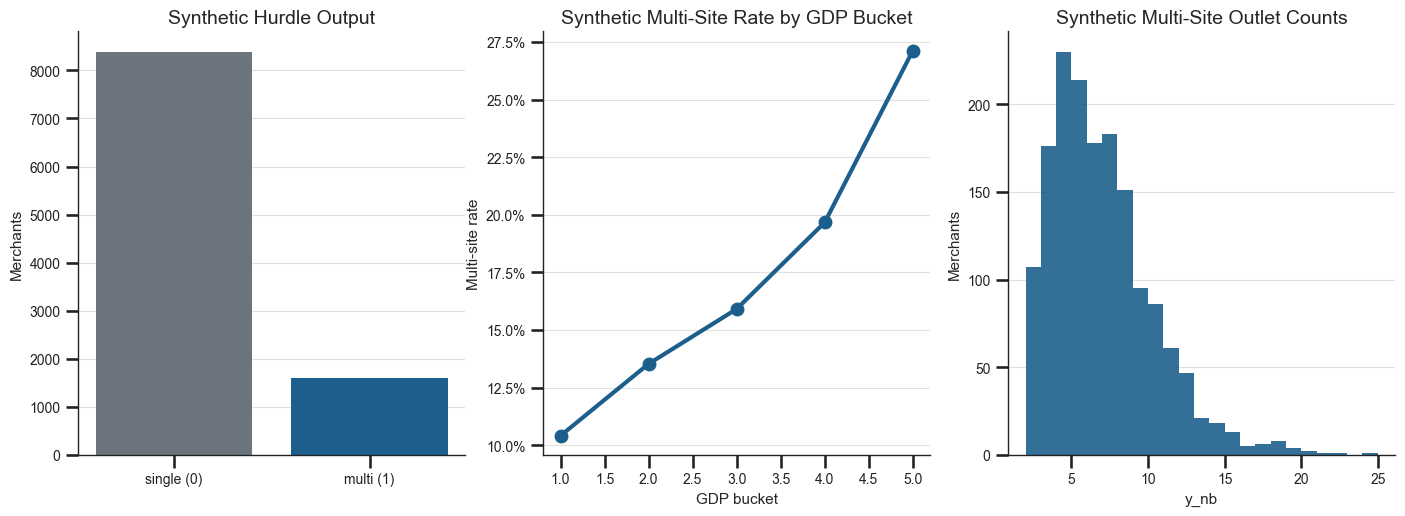

In [49]:
# Downstream training outputs and the later break from the original priors world.
plot_hurdle_priors_training_outputs()

This figure is where the priors stop being an authored recipe and start becoming an emitted synthetic world. The left panel shows the hurdle output population split. Out of the `10,000` merchants in the merchant parquet, the synthetic world produces about `1,609` multi-site merchants and about `8,391` single-site merchants. That is almost exactly the kind of minority branch share we would expect from a `mean_pi_target` around `0.16`, so the branch world is not merely theoretically calibrated; it is visibly landing where it was designed to land.

The middle panel is especially important because it checks whether the GDP-bucket prior survived all the way into the realized labels. It did. The multi-site rate rises steadily from roughly `10%` in bucket `1` to roughly `27%` in bucket `5`, with the intermediate buckets sitting in a smooth ascending order. That is a powerful confirmation that the bucket ladder is not just a latent offset table hidden in the YAML. It is actually legible in the emitted branch world.

The right panel then moves from branch admission into branch size. The synthetic multi-site outlet counts are clearly right-skewed. Most of the mass is in the low-to-moderate count range, especially around the mid single digits, and then the frequency thins out through the teens with only a sparse tail beyond that. So the priors are not authoring a world full of giant chains. They are authoring a world where most multi-site merchants are moderate in size, but a long upper tail still exists.

Taken together, these three panels show that the priors are producing a coherent two-stage synthetic world: a minority multi-site branch, a bucket-ordered branch propensity, and a moderate but skewed outlet-count distribution for the admitted merchants.

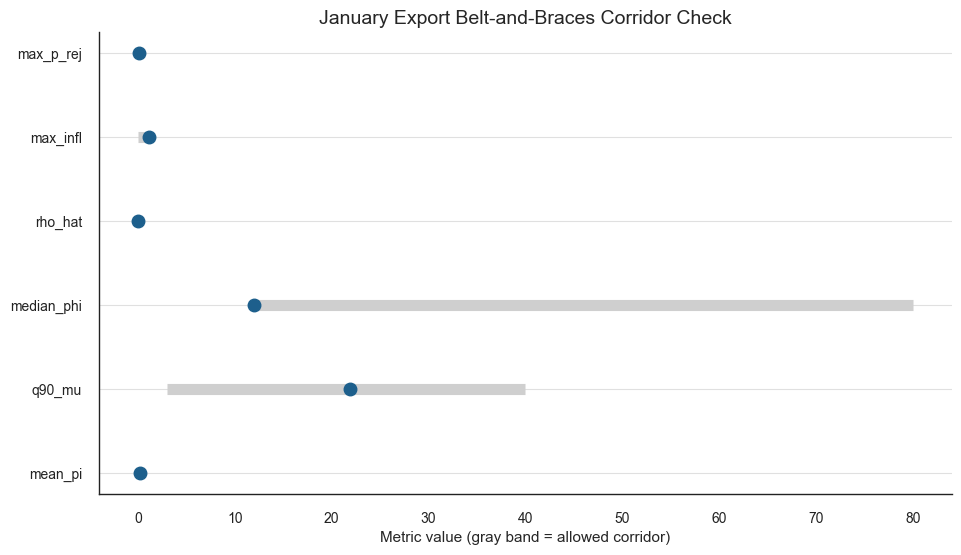

: 

: 

: 

In [ ]:
plot_hurdle_priors_corridor_selfcheck()


This plot is not about authored intent; it is about export validity. The gray bars are the allowed corridor bands and the blue points are the realized January export metrics. So the question here is simple: after all the authoring, calibration, noise, and clamping, did the emitted world end up inside the safety envelope the exporter expects?

The answer is yes, but the way it passes is revealing. Mean `pi` sits near the lower part of its allowed branch-rate corridor, not near the top. `q90_mu` sits safely inside its count-scale corridor rather than pressing against the upper boundary. `median_phi` sits right at the floor of its allowed dispersion band, which is consistent with the tuning history that pushed `phi` upward to avoid a weaker low-dispersion regime. The rejection and inflation diagnostics are tiny relative to their allowed bands.

So this is not a picture of a synthetic world barely surviving validation by chance. It is a picture of a world that has been explicitly engineered to stay away from pathological corners. That also explains why the late-December retuning was necessary. The priors were being adjusted not just to look plausible, but to remain corridor-safe under the exporter’s belt-and-braces checks.

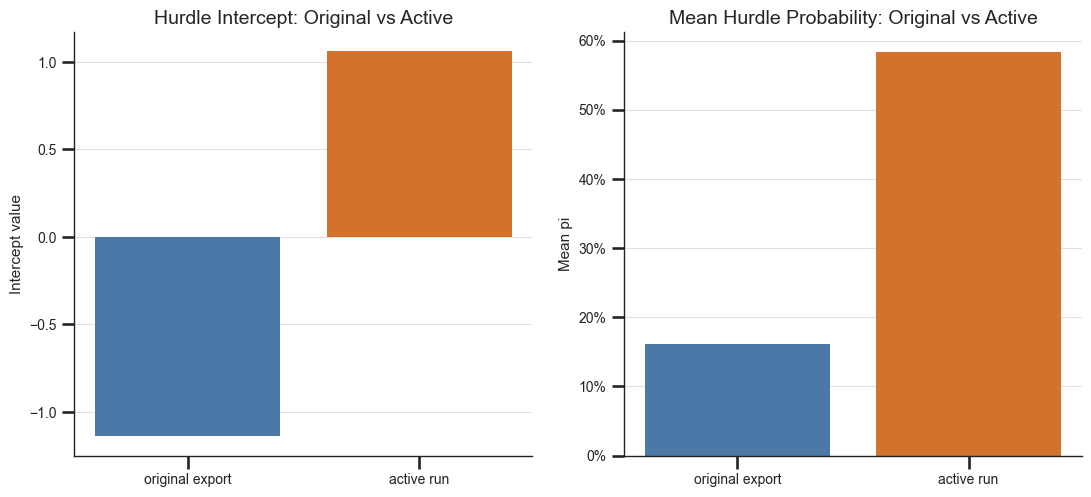

In [50]:
plot_hurdle_priors_origin_vs_active()

This final figure is the break point between the original priors world and the active run we are investigating elsewhere. The left panel shows that the hurdle intercept did not merely drift a little between export generations. It moved from the original January posture of about `-1.14` to an active-run posture of about `+1.06`. That is the visual signature of the later governed `+2.2` hurdle-intercept remediation.

The right panel shows the practical consequence of that shift. The original priors-authored branch world had a mean hurdle probability of about `16%`. The active run is closer to `58%`. So the active branch world is not just a mildly adjusted version of the January synthetic export. It is a fundamentally more permissive branch world.

This matters enormously for interpretation. Up to this point, the priors investigation has been telling us how the original synthetic world was authored. This figure tells us where that original authored world ceased to be the final authority. The active run still inherits the contour vocabulary of the priors, but it no longer inherits the original vertical level of the branch law.

So the correct analytical posture going forward is this: use the priors to understand the original structure and intent of the synthetic hurdle world, but do not mistake that for the exact branch posture of the active `S1` run. The active run has already been deliberately moved away from that origin.

##### `hurdle_coefficients.yaml`: first orientation

With the priors introduced, the next object to inspect is the active coefficient bundle that `S1` actually applies at runtime: `hurdle_coefficients.yaml`.

Conceptually, this file sits closer to the live branch decision than the priors do. The priors authored the synthetic training world upstream; this bundle carries the frozen dictionaries and fitted coefficient vectors that the hurdle law uses when scoring the active merchant world in `S1`.

The fuller Watson workbench investigation lives here:

- [hurdle_coefficients_investigation.md](../watson_workbench/notes/hurdle_coefficients_investigation.md)

For the notebook, the immediate job is again narrower: open the active bundle, see its shape, and get a first view of what kind of governed model object we are dealing with before we move into the visual and statistical walkthrough.

---

In [51]:
# Point to the active hurdle coefficient bundle used by the pinned run we are investigating.
hurdle_coefficients_path = (
    ROOT
    / "config"
    / "layer1"
    / "1A"
    / "models"
    / "hurdle"
    / "exports"
    / "version=2026-02-14"
    / "20260214T173000Z"
    / "hurdle_coefficients.yaml"
)

# Load the YAML so we can inspect the active bundle directly before bringing in any coefficient plots.
with open(hurdle_coefficients_path, "r", encoding="utf-8") as handle:
    hurdle_coefficients = yaml.safe_load(handle)

# Summarize the top-level sections first so we can see the major components carried by the bundle.
hurdle_coefficients_summary_df = pd.DataFrame(
    [
        {
            "section": key,
            "python_type": type(value).__name__,
            "entries": len(value) if isinstance(value, (dict, list)) else 1,
        }
        for key, value in hurdle_coefficients.items()
    ]
)

# Pull out the compact first-read facts that matter before deeper analysis: lineage, remediation, and vector sizes.
hurdle_coefficients_metadata = hurdle_coefficients.get("metadata", {})
hurdle_coefficients_remediation = hurdle_coefficients_metadata.get("remediation", {})

hurdle_coefficients_profile_df = pd.DataFrame(
    [
        {"metric": "created_utc", "value": hurdle_coefficients_metadata.get("created_utc")},
        {"metric": "seed", "value": hurdle_coefficients_metadata.get("seed")},
        {"metric": "simulation_manifest", "value": hurdle_coefficients_metadata.get("simulation_manifest")},
        {"metric": "simulation_config_path", "value": hurdle_coefficients_metadata.get("simulation_config_path")},
        {"metric": "remediation_change", "value": hurdle_coefficients_remediation.get("change")},
        {"metric": "remediation_parent_bundle", "value": hurdle_coefficients_remediation.get("parent_bundle")},
        {"metric": "dict_mcc_count", "value": len(hurdle_coefficients.get("dict_mcc", {}))},
        {"metric": "dict_ch_count", "value": len(hurdle_coefficients.get("dict_ch", {}))},
        {"metric": "dict_dev5_count", "value": len(hurdle_coefficients.get("dict_dev5", {}))},
        {"metric": "beta_length", "value": len(hurdle_coefficients.get("beta", []))},
        {"metric": "beta_mu_length", "value": len(hurdle_coefficients.get("beta_mu", []))},
    ]
)

# Expose the model blocks and a small numeric preview so we can see how the bundle is organized without diving into plots yet.
hurdle_coefficients_design_df = pd.DataFrame(
    {
        "beta_order": pd.Series(hurdle_coefficients.get("design", {}).get("beta_order", [])),
        "beta_mu_order": pd.Series(hurdle_coefficients.get("design", {}).get("beta_mu_order", [])),
    }
)

hurdle_coefficients_head_df = pd.DataFrame(
    {
        "beta_head": pd.Series(hurdle_coefficients.get("beta", [])[:10]),
        "beta_mu_head": pd.Series(hurdle_coefficients.get("beta_mu", [])[:10]),
    }
)

print(f"hurdle_coefficients_path: {hurdle_coefficients_path}")
display(hurdle_coefficients_summary_df)
display(hurdle_coefficients_profile_df)
display(hurdle_coefficients_design_df)
display(hurdle_coefficients_head_df)


hurdle_coefficients_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\config\layer1\1A\models\hurdle\exports\version=2026-02-14\20260214T173000Z\hurdle_coefficients.yaml


,section,python_type,entries
0,semver,str,1
1,version,str,1
2,metadata,dict,6
3,dict_mcc,list,290
4,dict_ch,list,2
5,dict_dev5,list,5
6,design,dict,2
7,beta,list,298
8,beta_mu,list,293


,metric,value
0,created_utc,20260214T173000Z
1,seed,9248923
2,simulation_manifest,C:/Users/LEGION/Documents/Data Science/Python ...
3,simulation_config_path,C:/Users/LEGION/Documents/Data Science/Python ...
4,remediation_change,beta_mu_non_intercept_downscale_midpoint_pass
5,remediation_parent_bundle,version=2026-02-14/20260214T125000Z
6,dict_mcc_count,290
7,dict_ch_count,2
8,dict_dev5_count,5
9,beta_length,298


,beta_order,beta_mu_order
0,intercept,intercept
1,mcc_onehot(dict_mcc),mcc_onehot(dict_mcc)
2,"ch_onehot(['CP','CNP'])","ch_onehot(['CP','CNP'])"
3,"gdp_bucket_onehot([1,2,3,4,5])",NaN


,beta_head,beta_mu_head
0,1.060424,1.781496
1,-0.123555,-0.619585
2,0.649138,-0.359572
3,0.252973,0.020862
4,-0.905381,-0.842549
5,0.014424,-0.215710
6,-0.370232,0.604936
7,-0.337983,0.117178
8,1.161007,0.347804
9,0.720897,-0.056465


In [52]:
# Import the extra packages needed for the hurdle-coefficients visual walkthrough.
import re
from matplotlib.ticker import PercentFormatter


# Keep the coefficient visuals visually aligned with the Watson workbench exports.
HURDLE_COEFF_COLORS = {
    "blue": "#245f87",
    "orange": "#c26d2d",
    "green": "#2a9d8f",
    "red": "#c94c4c",
    "gray": "#6c757d",
    "light_gray": "#d8dee4",
    "dark": "#222222",
    "purple": "#6b5b95",
}


# Use the same axis treatment across the hurdle-coefficient figures.
def style_hurdle_coeff_axes(ax, *, xgrid: bool = False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(HURDLE_COEFF_COLORS["dark"])
    ax.spines["bottom"].set_color(HURDLE_COEFF_COLORS["dark"])
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(colors=HURDLE_COEFF_COLORS["dark"], labelsize=10)
    ax.title.set_fontsize(14)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    if xgrid:
        ax.grid(axis="x", color="#eeeeee", linewidth=0.7, alpha=0.7)
    else:
        ax.grid(axis="x", visible=False)


# Normalize channel labels so training, runtime, and bundle views use the same CP/CNP vocabulary.
def normalize_hurdle_coeff_channel_expr(col: str = "channel"):
    return (
        pl.when(pl.col(col).is_in(["card_present", "CP"]))
        .then(pl.lit("CP"))
        .when(pl.col(col).is_in(["card_not_present", "CNP"]))
        .then(pl.lit("CNP"))
        .otherwise(pl.col(col))
    )


# Split the active bundle into the coefficient blocks we will inspect visually.
def split_hurdle_bundle(bundle: dict) -> dict:
    dict_mcc = [int(x) for x in bundle["dict_mcc"]]
    dict_ch = list(bundle["dict_ch"])
    dict_dev5 = [int(x) for x in bundle["dict_dev5"]]
    beta = np.array(bundle["beta"], dtype=float)
    beta_mu = np.array(bundle["beta_mu"], dtype=float)

    mcc_start = 1
    ch_start = mcc_start + len(dict_mcc)
    bucket_start = ch_start + len(dict_ch)

    mu_mcc_start = 1
    mu_ch_start = mu_mcc_start + len(dict_mcc)

    return {
        "dict_mcc": dict_mcc,
        "dict_ch": dict_ch,
        "dict_dev5": dict_dev5,
        "beta": beta,
        "beta_intercept": float(beta[0]),
        "beta_mcc": beta[mcc_start:ch_start],
        "beta_ch": beta[ch_start:bucket_start],
        "beta_bucket": beta[bucket_start:bucket_start + len(dict_dev5)],
        "beta_mu": beta_mu,
        "beta_mu_intercept": float(beta_mu[0]),
        "beta_mu_mcc": beta_mu[mu_mcc_start:mu_ch_start],
        "beta_mu_ch": beta_mu[mu_ch_start:mu_ch_start + len(dict_ch)],
    }


# Simple logistic link for rebuilding the hurdle probability surface from the coefficient bundle.
def hurdle_sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


# Recompute the hurdle linear score using the frozen feature basis expected by S1.
def score_hurdle_runtime(design: pl.DataFrame, parts: dict) -> np.ndarray:
    mcc_index = {code: idx for idx, code in enumerate(parts["dict_mcc"])}
    ch_index = {ch: idx for idx, ch in enumerate(parts["dict_ch"])}
    bucket_index = {bucket: idx for idx, bucket in enumerate(parts["dict_dev5"])}

    mcc = design["mcc"].to_numpy()
    channel = design["channel_norm"].to_list()
    bucket = design["gdp_bucket_id"].to_numpy()

    eta = np.full(len(design), parts["beta_intercept"], dtype=float)
    eta += np.array([parts["beta_mcc"][mcc_index[int(x)]] for x in mcc], dtype=float)
    eta += np.array([parts["beta_ch"][ch_index[str(x)]] for x in channel], dtype=float)
    eta += np.array([parts["beta_bucket"][bucket_index[int(x)]] for x in bucket], dtype=float)
    return eta


# Recompute the NB-mean linear score carried downstream into S2.
def score_mu_runtime(design: pl.DataFrame, parts: dict) -> np.ndarray:
    mcc_index = {code: idx for idx, code in enumerate(parts["dict_mcc"])}
    ch_index = {ch: idx for idx, ch in enumerate(parts["dict_ch"])}

    mcc = design["mcc"].to_numpy()
    channel = design["channel_norm"].to_list()

    eta = np.full(len(design), parts["beta_mu_intercept"], dtype=float)
    eta += np.array([parts["beta_mu_mcc"][mcc_index[int(x)]] for x in mcc], dtype=float)
    eta += np.array([parts["beta_mu_ch"][ch_index[str(x)]] for x in channel], dtype=float)
    return eta


# Pull the runtime design, diagnostic probability, and emitted hurdle-event stream into one joined frame.
def load_hurdle_runtime_surface() -> pl.DataFrame:
    run_id = "a3bd8cac9a4284cd36072c6b9624a0c1"
    parameter_hash = "0ea66cf0adf1c64bbaad68e566d1e49be502d771df78c608a4d2c23887d60f00"
    seed = 42
    run_dir = ROOT / "runs" / "local_full_run-7" / run_id

    design_path = run_dir / "data" / "layer1" / "1A" / "hurdle_design_matrix" / f"parameter_hash={parameter_hash}" / "part-00000.parquet"
    pi_path = run_dir / "data" / "layer1" / "1A" / "hurdle_pi_probs" / f"parameter_hash={parameter_hash}" / "part-00000.parquet"
    event_path = run_dir / "logs" / "layer1" / "1A" / "rng" / "events" / "hurdle_bernoulli" / f"seed={seed}" / f"parameter_hash={parameter_hash}" / f"run_id={run_id}" / "part-00000.jsonl"

    design = pl.read_parquet(design_path).with_columns(normalize_hurdle_coeff_channel_expr().alias("channel_norm"))
    pi = pl.read_parquet(pi_path).select(["merchant_id", "logit", "pi"]).rename({"logit": "diag_logit", "pi": "diag_pi"})

    event_rows = []
    with open(event_path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip():
                continue
            obj = json.loads(line)
            event_rows.append(
                {
                    "merchant_id": obj["merchant_id"],
                    "event_pi": float(obj["pi"]),
                    "u": None if obj["u"] is None else float(obj["u"]),
                    "is_multi": bool(obj["is_multi"]),
                    "draws": int(obj["draws"]),
                }
            )

    events = pl.DataFrame(
        event_rows,
        schema={
            "merchant_id": pl.UInt64,
            "event_pi": pl.Float64,
            "u": pl.Float64,
            "is_multi": pl.Boolean,
            "draws": pl.Int64,
        },
        strict=False,
    )

    return design.join(pi, on="merchant_id", how="left").join(events, on="merchant_id", how="left")


# Read the training export lineage that originally produced the coefficient family.
def load_hurdle_training_surfaces():
    training_dir = ROOT / "artefacts" / "training" / "1A" / "hurdle_sim" / "simulation_version=2026-01-03" / "seed=9248923" / "20260103T184840Z"
    logistic = pl.read_parquet(training_dir / "logistic.parquet").with_columns(normalize_hurdle_coeff_channel_expr().alias("channel_norm"))
    nb_mean = pl.read_parquet(training_dir / "nb_mean.parquet").with_columns(normalize_hurdle_coeff_channel_expr().alias("channel_norm"))
    return logistic, nb_mean


# Pull the coefficient bundle family so we can view how the active bundle sits within its lineage.
def load_hurdle_bundle_lineage() -> pl.DataFrame:
    def bundle_sort_key(path):
        version_match = re.search(r"version=([^/\\]+)", path.as_posix())
        timestamp = path.parent.name
        version = version_match.group(1) if version_match else ""
        return (version, timestamp)

    rows = []
    bundle_root = ROOT / "config" / "layer1" / "1A" / "models" / "hurdle" / "exports"
    for path in sorted(bundle_root.glob("version=*/**/hurdle_coefficients.yaml"), key=bundle_sort_key):
        bundle = yaml.safe_load(path.read_text(encoding="utf-8"))
        if not {"dict_mcc", "dict_ch", "beta", "beta_mu"}.issubset(set(bundle.keys())):
            continue
        parts = split_hurdle_bundle(bundle)
        metadata = bundle.get("metadata", {}) or {}
        remediation = metadata.get("remediation", {}) or {}
        version_match = re.search(r"version=([^/\\]+)", path.as_posix())
        rows.append(
            {
                "path": path.as_posix(),
                "version_path": version_match.group(1) if version_match else "",
                "timestamp": path.parent.name,
                "internal_version": str(bundle.get("version")),
                "beta_intercept": parts["beta_intercept"],
                "beta_mu_intercept": parts["beta_mu_intercept"],
                "beta_mcc_std": float(np.std(parts["beta_mcc"])),
                "beta_mu_mcc_std": float(np.std(parts["beta_mu_mcc"])),
                "change": remediation.get("change", "direct_export"),
                "wave": remediation.get("wave", ""),
            }
        )

    return pl.DataFrame(rows).with_row_index("idx")


# Collect the active and original bundles once so the plotting cells all read the same governed objects.
def build_hurdle_coeff_context() -> dict:
    original_bundle_path = (
        ROOT
        / "config"
        / "layer1"
        / "1A"
        / "models"
        / "hurdle"
        / "exports"
        / "version=2026-01-03"
        / "20260103T184840Z"
        / "hurdle_coefficients.yaml"
    )
    original_bundle = yaml.safe_load(original_bundle_path.read_text(encoding="utf-8"))
    active_parts = split_hurdle_bundle(hurdle_coefficients)
    original_parts = split_hurdle_bundle(original_bundle)
    logistic, nb_mean = load_hurdle_training_surfaces()
    runtime = load_hurdle_runtime_surface()
    lineage = load_hurdle_bundle_lineage()
    return {
        "active_parts": active_parts,
        "original_parts": original_parts,
        "logistic": logistic,
        "nb_mean": nb_mean,
        "runtime": runtime,
        "lineage": lineage,
    }


# Plot the training hurdle and NB-count surfaces that originally produced the fitted bundle.
def plot_hurdle_coeff_training_corpus_surfaces(ctx: dict):
    logistic = ctx["logistic"]
    nb_mean = ctx["nb_mean"]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    ax = axes[0, 0]
    label_counts = logistic.group_by("y_hurdle").len().sort("y_hurdle")
    ax.bar(["single (0)", "multi (1)"], label_counts["len"].to_list(), color=[HURDLE_COEFF_COLORS["gray"], HURDLE_COEFF_COLORS["blue"]], edgecolor="none")
    ax.set_title("Training Hurdle Labels")
    ax.set_ylabel("Merchants")
    style_hurdle_coeff_axes(ax)

    ax = axes[0, 1]
    multi_rates = logistic.group_by(["gdp_bucket", "channel_norm"]).agg(pl.mean("y_hurdle").alias("multi_rate")).sort(["gdp_bucket", "channel_norm"])
    for channel, color in [("CP", HURDLE_COEFF_COLORS["blue"]), ("CNP", HURDLE_COEFF_COLORS["orange"])]:
        sub = multi_rates.filter(pl.col("channel_norm") == channel)
        ax.plot(sub["gdp_bucket"].to_list(), sub["multi_rate"].to_list(), marker="o", linewidth=2.5, label=channel, color=color)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Training Multi-Site Rate by Bucket and Channel")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("Multi-site rate")
    ax.legend(frameon=False)
    style_hurdle_coeff_axes(ax)

    ax = axes[1, 0]
    y_nb = nb_mean["y_nb"].to_numpy()
    bins = np.arange(2, min(int(y_nb.max()) + 2, 35))
    ax.hist(y_nb, bins=bins, color=HURDLE_COEFF_COLORS["green"], edgecolor="none", alpha=0.9)
    ax.set_title("NB-Count Training Target Distribution")
    ax.set_xlabel("y_nb")
    ax.set_ylabel("Merchants")
    style_hurdle_coeff_axes(ax)

    ax = axes[1, 1]
    nb_means = nb_mean.group_by(["gdp_bucket", "channel_norm"]).agg(pl.mean("y_nb").alias("mean_y_nb")).sort(["gdp_bucket", "channel_norm"])
    for channel, color in [("CP", HURDLE_COEFF_COLORS["blue"]), ("CNP", HURDLE_COEFF_COLORS["orange"])]:
        sub = nb_means.filter(pl.col("channel_norm") == channel)
        ax.plot(sub["gdp_bucket"].to_list(), sub["mean_y_nb"].to_list(), marker="o", linewidth=2.5, label=channel, color=color)
    ax.set_title("Mean y_nb by Bucket and Channel")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("Mean y_nb")
    ax.legend(frameon=False)
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


# Plot the active bundle's intercept, channel, and GDP-bucket blocks.
def plot_hurdle_coeff_active_bundle_block_summary(ctx: dict):
    parts = ctx["active_parts"]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))

    ax = axes[0]
    ax.bar(["hurdle beta", "NB beta_mu"], [parts["beta_intercept"], parts["beta_mu_intercept"]], color=[HURDLE_COEFF_COLORS["blue"], HURDLE_COEFF_COLORS["green"]], edgecolor="none")
    ax.set_title("Intercepts")
    ax.set_ylabel("Coefficient value")
    style_hurdle_coeff_axes(ax)

    ax = axes[1]
    x = np.arange(len(parts["dict_ch"]))
    width = 0.36
    ax.bar(x - width / 2, parts["beta_ch"], width=width, label="beta: hurdle", color=HURDLE_COEFF_COLORS["blue"], edgecolor="none")
    ax.bar(x + width / 2, parts["beta_mu_ch"], width=width, label="beta_mu: NB mean", color=HURDLE_COEFF_COLORS["green"], edgecolor="none")
    ax.axhline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(parts["dict_ch"])
    ax.set_title("Channel Terms")
    ax.set_ylabel("Coefficient value")
    ax.legend(frameon=False, fontsize=9)
    style_hurdle_coeff_axes(ax)

    ax = axes[2]
    ax.plot(parts["dict_dev5"], parts["beta_bucket"], marker="o", linewidth=2.8, color=HURDLE_COEFF_COLORS["orange"])
    ax.axhline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
    ax.set_title("Hurdle GDP-Bucket Terms")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("beta coefficient")
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


# Helper for surfacing the strongest positive and negative MCC terms in each coefficient lane.
def hurdle_coeff_extremes_df(codes: list[int], values: np.ndarray, n: int = 8) -> pl.DataFrame:
    df = pl.DataFrame({"mcc": [str(x) for x in codes], "coef": values.tolist()})
    top = df.sort("coef", descending=True).head(n).with_columns(pl.lit("positive").alias("side"))
    bottom = df.sort("coef").head(n).with_columns(pl.lit("negative").alias("side"))
    return pl.concat([top, bottom])


# Plot the full MCC spread and the strongest MCC pushes/suppressions in each lane.
def plot_hurdle_coeff_mcc_block_spreads(ctx: dict):
    parts = ctx["active_parts"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    lanes = [
        ("Hurdle beta MCC block", parts["beta_mcc"], HURDLE_COEFF_COLORS["blue"]),
        ("NB-mean beta_mu MCC block", parts["beta_mu_mcc"], HURDLE_COEFF_COLORS["green"]),
    ]

    for row_index, (title, values, color) in enumerate(lanes):
        ax = axes[row_index, 0]
        ax.hist(values, bins=45, color=color, edgecolor="none", alpha=0.9)
        ax.axvline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
        ax.set_title(f"{title}: Distribution")
        ax.set_xlabel("Coefficient value")
        ax.set_ylabel("MCC count")
        style_hurdle_coeff_axes(ax)

        ax = axes[row_index, 1]
        extremes = hurdle_coeff_extremes_df(parts["dict_mcc"], values, n=8)
        labels = extremes["mcc"].to_list()
        coeffs = extremes["coef"].to_list()
        colors = [HURDLE_COEFF_COLORS["green"] if value >= 0 else HURDLE_COEFF_COLORS["red"] for value in coeffs]
        ax.barh(labels, coeffs, color=colors, edgecolor="none")
        ax.axvline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
        ax.set_title(f"{title}: Strongest MCC Terms")
        ax.set_xlabel("Coefficient value")
        style_hurdle_coeff_axes(ax, xgrid=True)

    fig.tight_layout()
    plt.show()


# Plot the active runtime scoring surface and its agreement with the realized branch outcomes.
def plot_hurdle_coeff_active_runtime_scoring_surface(ctx: dict):
    runtime = ctx["runtime"]
    parts = ctx["active_parts"]
    recomputed_logit = score_hurdle_runtime(runtime, parts)
    recomputed_pi = hurdle_sigmoid(recomputed_logit)
    eta_mu = score_mu_runtime(runtime, parts)

    runtime = runtime.with_columns([
        pl.Series("recomputed_logit", recomputed_logit),
        pl.Series("recomputed_pi", recomputed_pi),
        pl.Series("eta_mu", eta_mu),
        pl.Series("mu_pred", np.exp(eta_mu)),
    ])

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    ax = axes[0, 0]
    for channel, color in [("CP", HURDLE_COEFF_COLORS["blue"]), ("CNP", HURDLE_COEFF_COLORS["orange"])]:
        values = runtime.filter(pl.col("channel_norm") == channel)["event_pi"].to_numpy()
        ax.hist(values, bins=45, alpha=0.55, color=color, edgecolor="none", label=channel)
    ax.set_title("Active Runtime pi Distribution by Channel")
    ax.set_xlabel("event pi")
    ax.set_ylabel("Merchants")
    ax.legend(frameon=False)
    style_hurdle_coeff_axes(ax)

    ax = axes[0, 1]
    buckets = sorted(runtime["gdp_bucket_id"].unique().to_list())
    box_data = [runtime.filter(pl.col("gdp_bucket_id") == bucket)["event_pi"].to_numpy() for bucket in buckets]
    ax.boxplot(
        box_data,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(facecolor="#dce9f5", color=HURDLE_COEFF_COLORS["blue"]),
        medianprops=dict(color=HURDLE_COEFF_COLORS["dark"]),
        whiskerprops=dict(color=HURDLE_COEFF_COLORS["blue"]),
        capprops=dict(color=HURDLE_COEFF_COLORS["blue"]),
        flierprops=dict(marker=".", markersize=2, markerfacecolor=HURDLE_COEFF_COLORS["gray"], markeredgecolor="none", alpha=0.35),
    )
    ax.set_xticklabels([str(bucket) for bucket in buckets])
    ax.set_title("Active Runtime pi by GDP Bucket")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("event pi")
    style_hurdle_coeff_axes(ax)

    ax = axes[1, 0]
    calibration = (
        runtime.with_columns((pl.col("event_pi") * 10).floor().clip(0, 9).cast(pl.Int64).alias("pi_decile"))
        .group_by("pi_decile")
        .agg([
            pl.mean("event_pi").alias("mean_pi"),
            pl.col("is_multi").cast(pl.Float64).mean().alias("observed_multi_rate"),
            pl.len().alias("n"),
        ])
        .sort("pi_decile")
    )
    ax.plot(calibration["mean_pi"].to_list(), calibration["observed_multi_rate"].to_list(), marker="o", linewidth=2.6, color=HURDLE_COEFF_COLORS["blue"])
    ax.plot([0, 1], [0, 1], linestyle="--", color=HURDLE_COEFF_COLORS["gray"], linewidth=1.3, label="ideal")
    for x_val, y_val, n_val in zip(calibration["mean_pi"].to_list(), calibration["observed_multi_rate"].to_list(), calibration["n"].to_list()):
        ax.text(x_val, y_val + 0.025, str(n_val), ha="center", fontsize=8, color=HURDLE_COEFF_COLORS["dark"])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Realized Multi-Site Rate by pi Band")
    ax.set_xlabel("Mean pi in band")
    ax.set_ylabel("Observed is_multi rate")
    ax.legend(frameon=False, fontsize=9)
    style_hurdle_coeff_axes(ax, xgrid=True)

    ax = axes[1, 1]
    pi_diff = runtime.with_columns((pl.col("event_pi") - pl.col("diag_pi")).abs().alias("abs_diff"))
    ax.hist(pi_diff["abs_diff"].to_numpy(), bins=40, color=HURDLE_COEFF_COLORS["purple"], edgecolor="none", alpha=0.9)
    ax.set_title("Event pi vs Diagnostic pi Difference")
    ax.set_xlabel("absolute difference")
    ax.set_ylabel("Merchants")
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


# Plot the relationship between the training targets and the fitted hurdle terms.
def plot_hurdle_coeff_training_fit_alignment(ctx: dict):
    logistic = ctx["logistic"]
    parts = ctx["active_parts"]
    fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

    ax = axes[0, 0]
    train_bucket_rate = logistic.group_by("gdp_bucket").agg(pl.mean("y_hurdle").alias("rate")).sort("gdp_bucket")
    ax.plot(train_bucket_rate["gdp_bucket"].to_list(), train_bucket_rate["rate"].to_list(), marker="o", linewidth=2.5, color=HURDLE_COEFF_COLORS["blue"])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Training Multi-Site Rate by Bucket")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("Training multi-site rate")
    style_hurdle_coeff_axes(ax)

    ax = axes[0, 1]
    ax.plot(parts["dict_dev5"], parts["beta_bucket"], marker="s", linewidth=2.5, color=HURDLE_COEFF_COLORS["orange"])
    ax.axhline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
    ax.set_title("Fitted Hurdle Bucket Terms")
    ax.set_xlabel("GDP bucket")
    ax.set_ylabel("beta bucket coefficient")
    style_hurdle_coeff_axes(ax)

    ax = axes[1, 0]
    train_channel_rate = logistic.group_by("channel_norm").agg(pl.mean("y_hurdle").alias("rate")).sort("channel_norm")
    x = np.arange(train_channel_rate.height)
    ax.bar(x, train_channel_rate["rate"].to_list(), color=HURDLE_COEFF_COLORS["blue"], edgecolor="none")
    ax.set_xticks(x)
    ax.set_xticklabels(train_channel_rate["channel_norm"].to_list())
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Training Multi-Site Rate by Channel")
    ax.set_ylabel("Training multi-site rate")
    style_hurdle_coeff_axes(ax)

    ax = axes[1, 1]
    channel_coef_map = {channel: coef for channel, coef in zip(parts["dict_ch"], parts["beta_ch"])}
    ax.bar(x, [channel_coef_map[channel] for channel in train_channel_rate["channel_norm"].to_list()], color=HURDLE_COEFF_COLORS["orange"], edgecolor="none")
    ax.axhline(0, color=HURDLE_COEFF_COLORS["dark"], linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(train_channel_rate["channel_norm"].to_list())
    ax.set_title("Fitted Hurdle Channel Terms")
    ax.set_ylabel("beta channel coefficient")
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


# Plot the key milestones in the coefficient-export lineage.
def plot_hurdle_coeff_bundle_lineage_progression(ctx: dict):
    lineage = ctx["lineage"]
    milestone_timestamps = [
        "20251009T120000Z",
        "20251024T234923Z",
        "20251231T134200Z",
        "20260103T184840Z",
        "20260212T171900Z",
        "20260212T200823Z",
        "20260213T104600Z",
        "20260214T125000Z",
        "20260214T173000Z",
    ]
    lineage = lineage.filter(pl.col("timestamp").is_in(milestone_timestamps)).sort("idx").with_row_index("plot_idx")
    label_map = {
        "20251009T120000Z": "initial\nOct09",
        "20251024T234923Z": "regen\nOct24",
        "20251231T134200Z": "late-Dec\nretune",
        "20260103T184840Z": "Jan03\ntraining export",
        "20260212T171900Z": "P1b\nhurdle shift",
        "20260212T200823Z": "P1\nfreeze",
        "20260213T104600Z": "Feb13\nmu lift",
        "20260214T125000Z": "P4.R4A\nfirst pass",
        "20260214T173000Z": "active\nFeb14",
    }
    labels = [label_map[row["timestamp"]] for row in lineage.to_dicts()]
    x = np.arange(lineage.height)

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    ax = axes[0]
    ax.plot(x, lineage["beta_intercept"].to_numpy(), marker="o", linewidth=2.2, color=HURDLE_COEFF_COLORS["blue"], label="hurdle beta intercept")
    ax.plot(x, lineage["beta_mu_intercept"].to_numpy(), marker="o", linewidth=2.2, color=HURDLE_COEFF_COLORS["green"], label="NB beta_mu intercept")
    p1b_x = int(lineage.filter(pl.col("timestamp") == "20260212T171900Z")["plot_idx"][0])
    active_x = int(lineage.filter(pl.col("timestamp") == "20260214T173000Z")["plot_idx"][0])
    ax.axvline(p1b_x, color=HURDLE_COEFF_COLORS["red"], linestyle="--", linewidth=1.3)
    ax.axvline(active_x, color=HURDLE_COEFF_COLORS["orange"], linestyle="--", linewidth=1.3)
    ymin, ymax = ax.get_ylim()
    ax.text(p1b_x + 0.05, ymax - (ymax - ymin) * 0.05, "P1b hurdle shift", va="top", fontsize=9, color=HURDLE_COEFF_COLORS["red"])
    ax.text(active_x - 0.05, ymax - (ymax - ymin) * 0.15, "active bundle", va="top", ha="right", fontsize=9, color=HURDLE_COEFF_COLORS["orange"])
    ax.set_title("Coefficient Bundle Intercepts Across Export Lineage")
    ax.set_ylabel("Intercept")
    ax.legend(frameon=False)
    style_hurdle_coeff_axes(ax)

    ax = axes[1]
    ax.plot(x, lineage["beta_mcc_std"].to_numpy(), marker="o", linewidth=2.2, color=HURDLE_COEFF_COLORS["blue"], label="hurdle MCC std")
    ax.plot(x, lineage["beta_mu_mcc_std"].to_numpy(), marker="o", linewidth=2.2, color=HURDLE_COEFF_COLORS["green"], label="NB-mean MCC std")
    ax.axvline(p1b_x, color=HURDLE_COEFF_COLORS["red"], linestyle="--", linewidth=1.3)
    ax.axvline(active_x, color=HURDLE_COEFF_COLORS["orange"], linestyle="--", linewidth=1.3)
    ax.set_title("MCC Block Spread Across Export Lineage")
    ax.set_ylabel("Standard deviation")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
    ax.legend(frameon=False)
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


# Plot how far the active February bundle moved away from the original January export.
def plot_hurdle_coeff_original_vs_active_deltas(ctx: dict):
    active_parts = ctx["active_parts"]
    original_parts = ctx["original_parts"]
    beta_delta = active_parts["beta"] - original_parts["beta"]
    beta_mu_delta = active_parts["beta_mu"] - original_parts["beta_mu"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))

    ax = axes[0]
    ax.bar(["original\nJan export", "active\nFeb bundle"], [original_parts["beta_intercept"], active_parts["beta_intercept"]], color=[HURDLE_COEFF_COLORS["gray"], HURDLE_COEFF_COLORS["blue"]], edgecolor="none")
    ax.set_title("Hurdle Intercept Shift")
    ax.set_ylabel("beta[0]")
    style_hurdle_coeff_axes(ax)

    ax = axes[1]
    hurdle_blocks = {
        "intercept": beta_delta[:1],
        "MCC": beta_delta[1:1 + len(active_parts["dict_mcc"])],
        "channel": beta_delta[1 + len(active_parts["dict_mcc"]):1 + len(active_parts["dict_mcc"]) + len(active_parts["dict_ch"])],
        "bucket": beta_delta[-len(active_parts["dict_dev5"]):],
    }
    ax.bar(list(hurdle_blocks.keys()), [float(np.linalg.norm(values)) for values in hurdle_blocks.values()], color=HURDLE_COEFF_COLORS["blue"], edgecolor="none")
    ax.set_title("Hurdle beta Delta by Block")
    ax.set_ylabel("L2 norm of delta")
    style_hurdle_coeff_axes(ax)

    ax = axes[2]
    nb_blocks = {
        "intercept": beta_mu_delta[:1],
        "MCC": beta_mu_delta[1:1 + len(active_parts["dict_mcc"])],
        "channel": beta_mu_delta[-len(active_parts["dict_ch"]):],
    }
    ax.bar(list(nb_blocks.keys()), [float(np.linalg.norm(values)) for values in nb_blocks.values()], color=HURDLE_COEFF_COLORS["green"], edgecolor="none")
    ax.set_title("NB beta_mu Delta by Block")
    ax.set_ylabel("L2 norm of delta")
    style_hurdle_coeff_axes(ax)

    fig.tight_layout()
    plt.show()


In [53]:
# Build the shared coefficient context once so all coefficient plots inspect the same governed objects.
hurdle_coeff_ctx = build_hurdle_coeff_context()

1. Training corpus surfaces

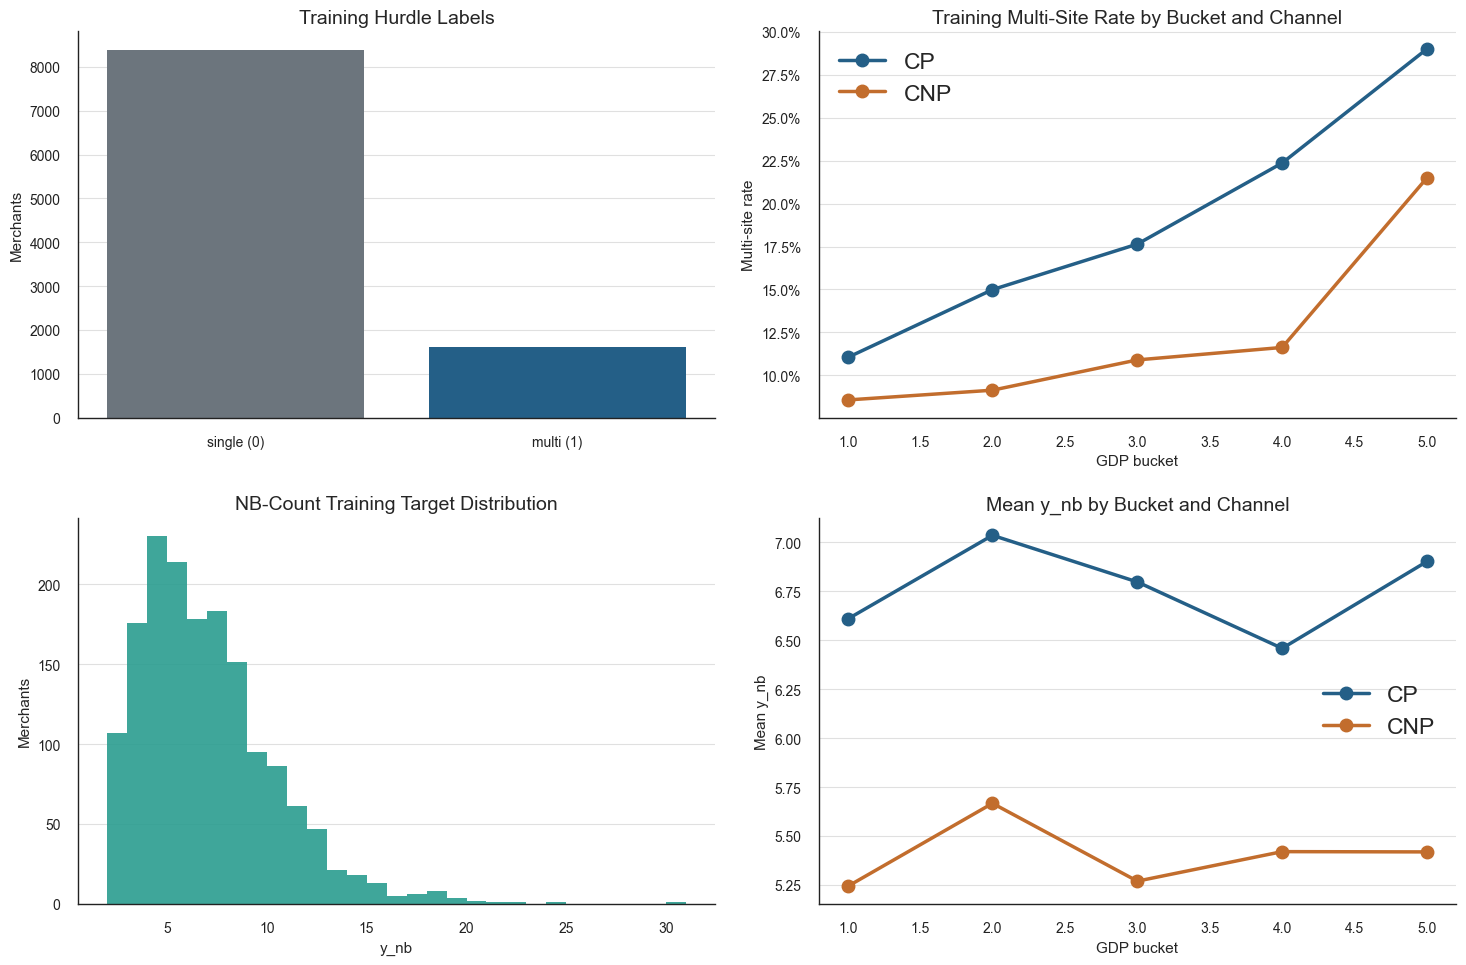

: 

: 

: 

In [ ]:
plot_hurdle_coeff_training_corpus_surfaces(hurdle_coeff_ctx)


This opening figure matters because it pulls the coefficient bundle back to the world it was fit from instead of letting the bundle appear as a free-floating vector of numbers. The top-left panel shows the hurdle labels in the January synthetic training corpus: `8,391` merchants were authored as single-site and `1,609` as multi-site. So the fitted hurdle lane was trained on a clearly minority multi-site class, with the multi-site share sitting at about `16.1%`. That immediately explains why the original January hurdle world was a selective branch world before later remediation lifted the active runtime posture.

The top-right panel then shows where that minority class came from structurally. The multi-site rate rises with GDP bucket for both channels, and `CP` stays above `CNP` at every bucket. In the training corpus, `CNP` moves from about `8.6%` in bucket `1` to `21.5%` in bucket `5`, while `CP` moves from about `11.0%` to `29.0%`. So the training world did not merely say that some merchants are multi-site and others are not. It embedded a clear ladder: richer GDP buckets are more multi-site, and `CP` is systematically more multi-site than `CNP`.

The lower row shifts from the hurdle branch world to the NB-count world authored for merchants already admitted into the multi-site branch. The bottom-left histogram shows that `y_nb` is not a thin or degenerate target. Across the `1,609` multi-site merchants, the synthetic outlet-count target has mean `6.52`, median `6`, minimum `2`, and maximum `30`. So the downstream count lane was trained on a genuinely spread count surface rather than a near-constant target.

The bottom-right panel then shows how that count surface behaves across the same macro axes. `CP` remains above `CNP` in every bucket, but unlike the hurdle lane, the bucket effect is not strongly monotone. `CP` mean `y_nb` ranges from about `6.46` to `7.04`, while `CNP` sits in a tighter and lower band around `5.24` to `5.67`. That matters because it shows that the synthetic training corpus distinguished two different jobs. The hurdle lane learned a strong branch-admission structure across GDP bucket and channel, while the NB lane learned a weaker bucket story but a persistent channel gap in expected outlet count once a merchant is already multi-site.

2. Active bundle structure

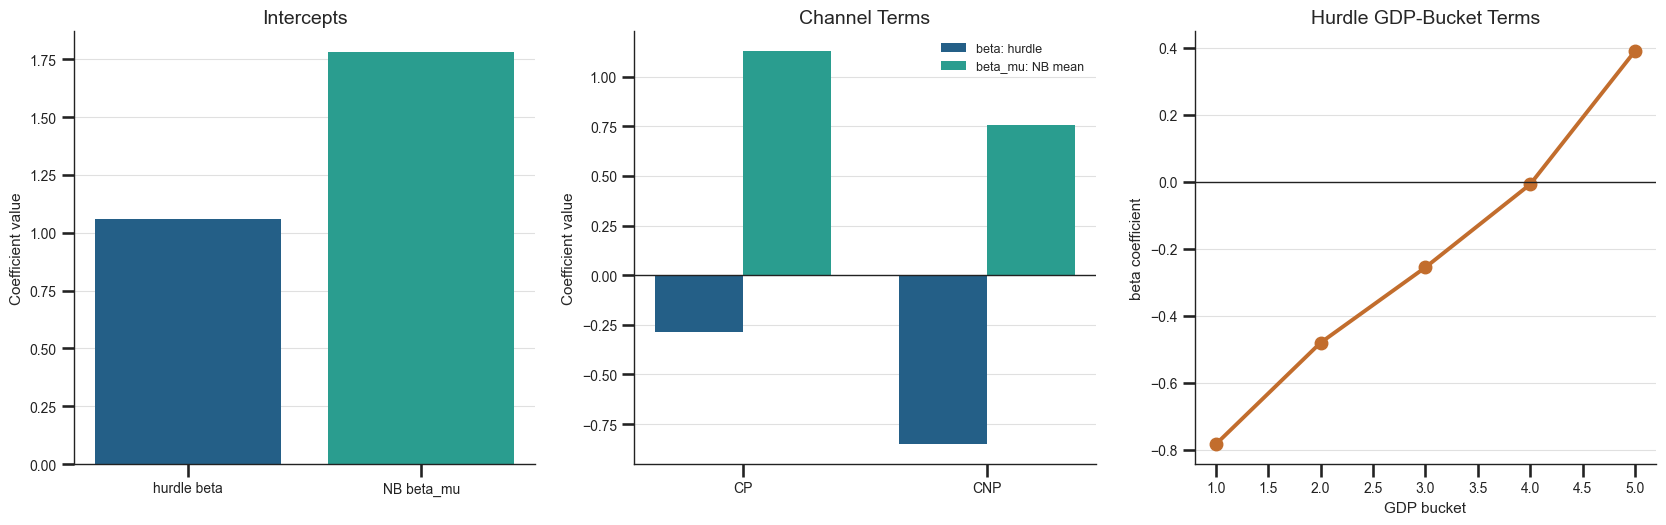

In [54]:
plot_hurdle_coeff_active_bundle_block_summary(hurdle_coeff_ctx)


This figure is the first direct look at the active bundle as a structured model object. The left panel shows that the active hurdle intercept and the active NB-mean intercept are not on the same level. The active `beta` intercept is about `1.0604`, while the active `beta_mu` intercept is about `1.7815`. So before any MCC, channel, or bucket term is applied, the NB-mean lane is already starting from a materially higher baseline on its own link scale than the hurdle lane.

The center panel then makes the channel story explicit across both lanes. In the hurdle lane, both channel terms are negative, but `CNP` is much more negative than `CP`: `CP = -0.2875`, `CNP = -0.8521`. That means the active hurdle law is suppressive for both channels relative to the intercept, but it suppresses `CNP` far more strongly. In the NB-mean lane, both channel terms are positive, with `CP = 1.1288` and `CNP = 0.7572`. So the two lanes are not expressing the same structural judgment. The hurdle lane asks whether a merchant should enter the multi-site branch at all, and there `CNP` is clearly the less favored channel. The NB-mean lane asks about expected outlet count conditional on that branch, and there both channels contribute positively, though `CP` still carries the stronger lift.

The right panel isolates the hurdle GDP-bucket block and shows one of the cleanest structural patterns in the entire bundle. The active bucket terms rise strictly from bucket `1` to bucket `5`: about `-0.7844`, `-0.4810`, `-0.2561`, `-0.0080`, and `+0.3899`. That is not noise. It is an authored monotone ladder. So, holding MCC and channel fixed, higher GDP bucket systematically pushes the hurdle score upward and increases branch propensity.

Taken together, the figure shows that the active coefficient bundle is not an unstructured cloud of parameters. Its visible shape is quite disciplined. The hurdle lane is governed by a positive intercept that is then selectively moderated by channel and steeply ordered by GDP bucket. The NB-mean lane starts from an even higher intercept and keeps both channels positive. So even before looking at the broad MCC blocks, we already see that the bundle carries a deliberate macro-structure rather than a fitted numerical residue.

3. MCC block spreads

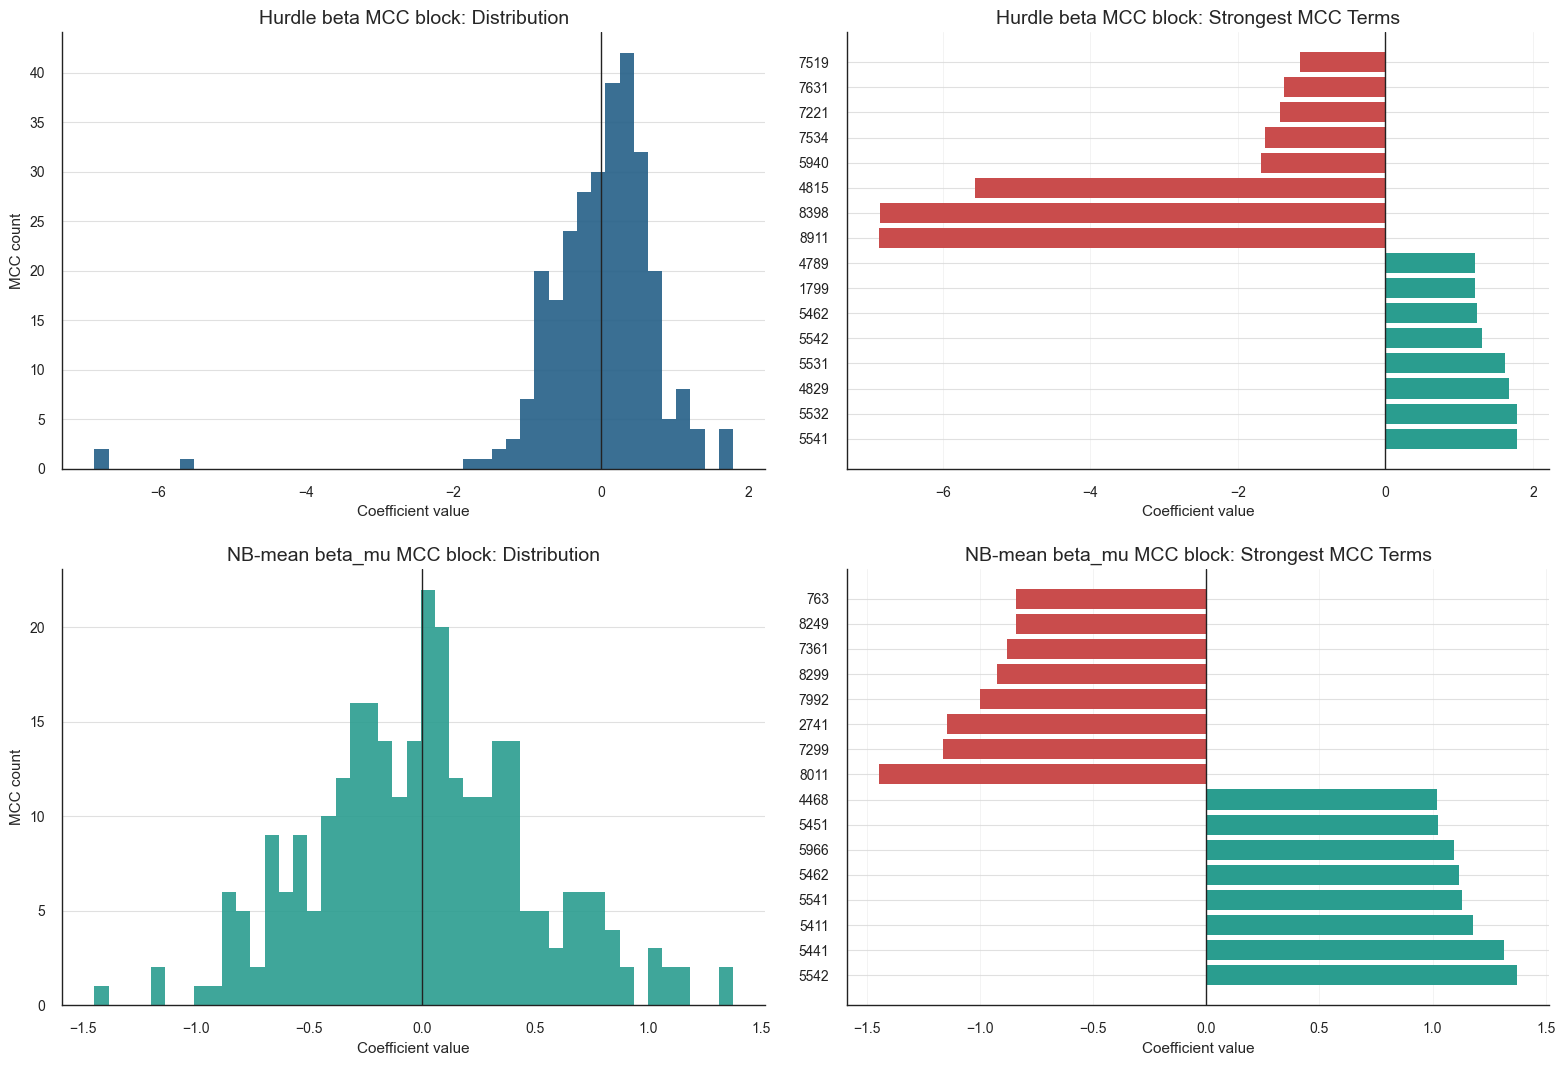

: 

: 

: 

In [ ]:
plot_hurdle_coeff_mcc_block_spreads(hurdle_coeff_ctx)


If the previous figure exposed the macro blocks, this one exposes the fine-grained merchant-category structure that sits underneath them. The hurdle MCC distribution is broad and visibly asymmetric. Its mean is essentially neutral at about `-0.0039`, but that is misleading if read on its own, because the spread is wide: the hurdle MCC block runs from about `-6.8654` to `+1.7896`, with standard deviation about `0.8867`. So the hurdle lane is not being carried mainly by a few smooth macro terms. It contains category-level pushes and suppressions that can be extremely strong for specific MCCs.

The strongest positive hurdle MCC terms cluster around categories like `5541`, `5532`, `4829`, `5531`, and `5542`, all above `+1.31` and reaching as high as `+1.79`. On the other side, a handful of categories are not merely mildly discouraged but aggressively suppressed: `8911` at `-6.8654`, `8398` at `-6.8501`, and `4815` at `-5.5563` stand far below the rest of the surface. Statistically, that means the hurdle law is willing to let some categories be decisive. The bundle is not saying only that GDP bucket and channel matter; it is also saying that some merchant categories are powerful evidence for or against multi-site branching.

The NB-mean MCC lane is broad too, but the shape is noticeably less violent. Its mean is about `+0.0065`, the range runs from about `-1.4481` to `+1.3755`, and the standard deviation is about `0.4765`, roughly half the hurdle spread. So the NB-mean lane is still category-sensitive, but it is less extreme than the hurdle branch lane. That matches the conceptual job split. The hurdle lane is deciding entry into a different structural world, so it can justify very hard category exclusions. The NB-mean lane is already inside the multi-site world and is only shaping expected outlet count there, so a narrower MCC spread is plausible.

That difference in spread is one of the most important facts in this figure. The active bundle does not use the same level of category aggression everywhere. It uses a sharper MCC surface to decide whether merchants branch into the multi-site path at all, and a milder MCC surface to shape the downstream count intensity once they are inside that branch. So the file is not just carrying two coefficient vectors; it is carrying two different styles of categorical judgment.

4. Runtime scoring surface

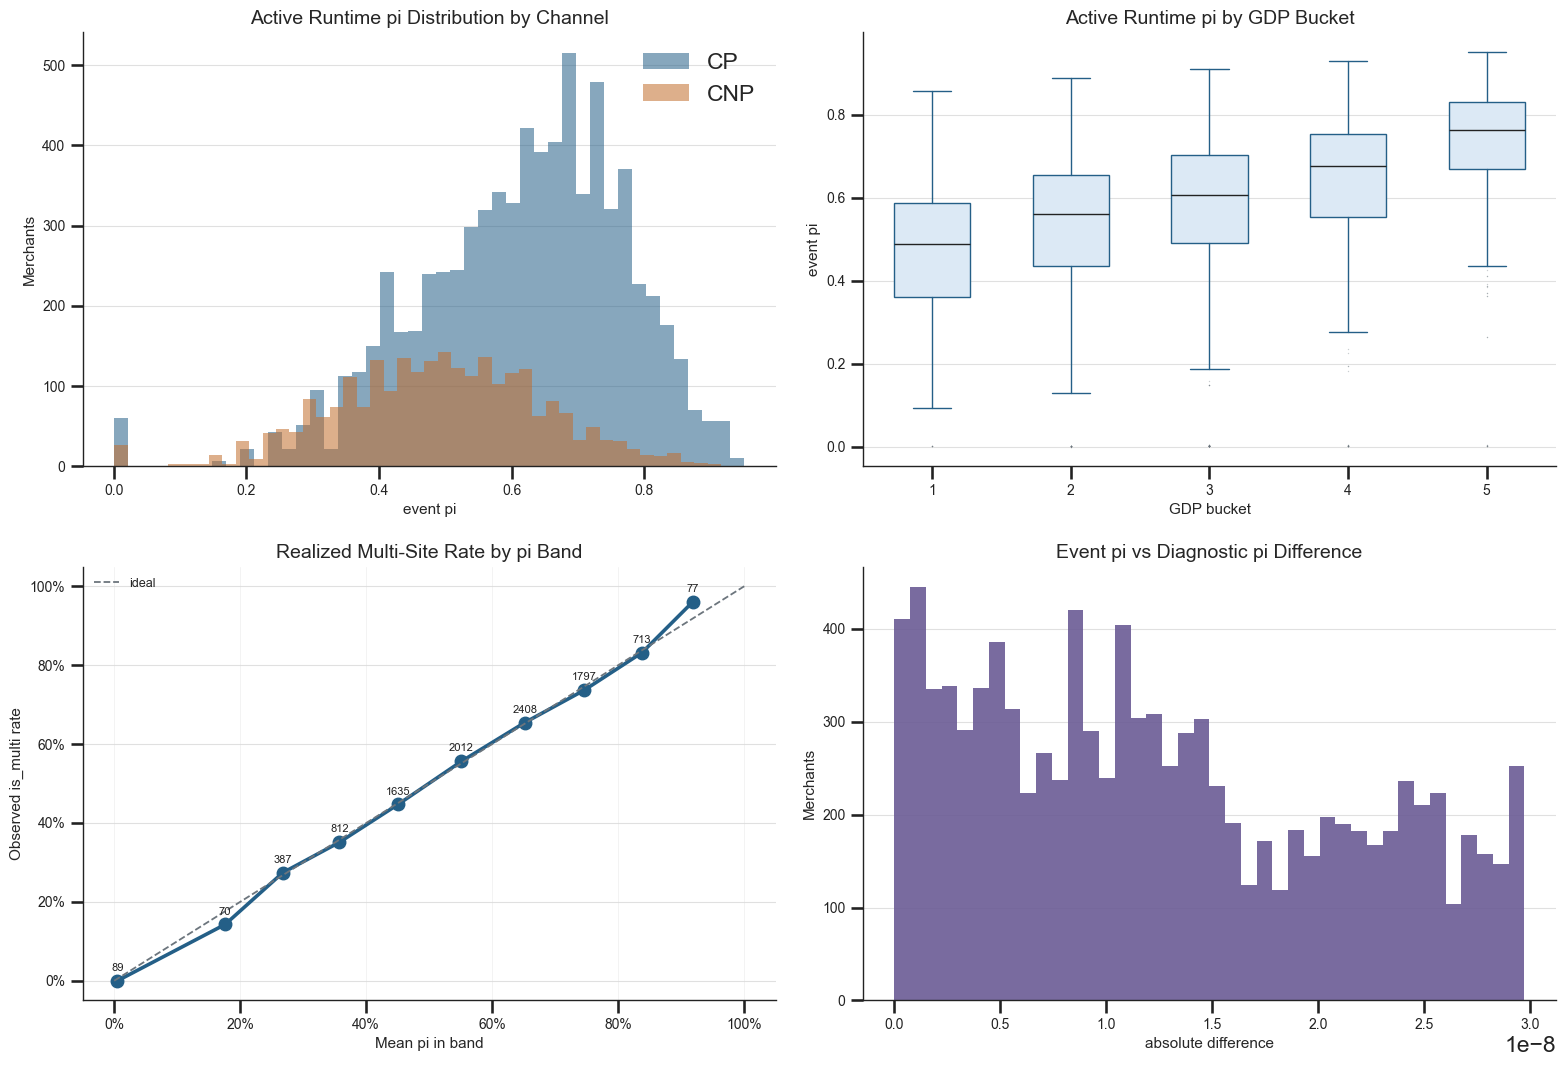

In [55]:
plot_hurdle_coeff_active_runtime_scoring_surface(hurdle_coeff_ctx)


This figure is where the active bundle stops being a static artefact and starts showing the branch world it actually induces over the runtime merchant population. The top-left panel shows the runtime `pi` surface split by channel. The contrast is large and coherent. `CNP` merchants have mean event probability about `0.4891` and realized multi-site rate about `0.4860`, while `CP` merchants have mean event probability about `0.6147` and realized multi-site rate about `0.6141`. So the channel difference we saw in the coefficient block is not merely formal. It survives translation into the merchant world and becomes a visible separation in the realized branch population.

The top-right panel shows the same runtime `pi` surface by GDP bucket, and it is almost a textbook realization of the monotone bucket coefficients. Mean `pi` rises from about `0.4745` in bucket `1` to `0.7324` in bucket `5`, with realized multi-site rate rising in step from about `0.4641` to `0.7300`. So the GDP ladder authored in the coefficient bundle is not being diluted away by the merchant mix. It is clearly reproduced in the actual runtime scoring surface.

The lower-left calibration plot is particularly useful because it compares probability assignment to realized branch outcomes rather than showing either alone. Across the main body of the distribution, the curve tracks the `y = x` line closely. For example, the `0.4` band has mean `pi` about `0.4506` and observed multi-site rate about `0.4471`; the `0.5` band has `0.5511` versus `0.5562`; the `0.6` band has `0.6517` versus `0.6545`; and the `0.8` band has `0.8377` versus `0.8317`. That is strong agreement. The low and high extremes drift a little, but those bands are also much thinner in sample size, with only `89` merchants in the `0` decile and `77` in the `0.9` decile. So the main statistical story is one of close calibration, not of branch misalignment.

The lower-right panel closes the loop mechanically. The absolute difference between event `pi` and diagnostic `pi` is effectively zero: mean absolute difference is about `1.26e-08` and even the maximum is only about `2.98e-08`. So the emitted branch probabilities are not just directionally similar to the diagnostic surface; they are numerically the same up to floating-point tolerance. This matters because it tells us the runtime event stream is faithfully realizing the active bundle's scoring law rather than drifting from it in implementation.

5. Training-fit alignment

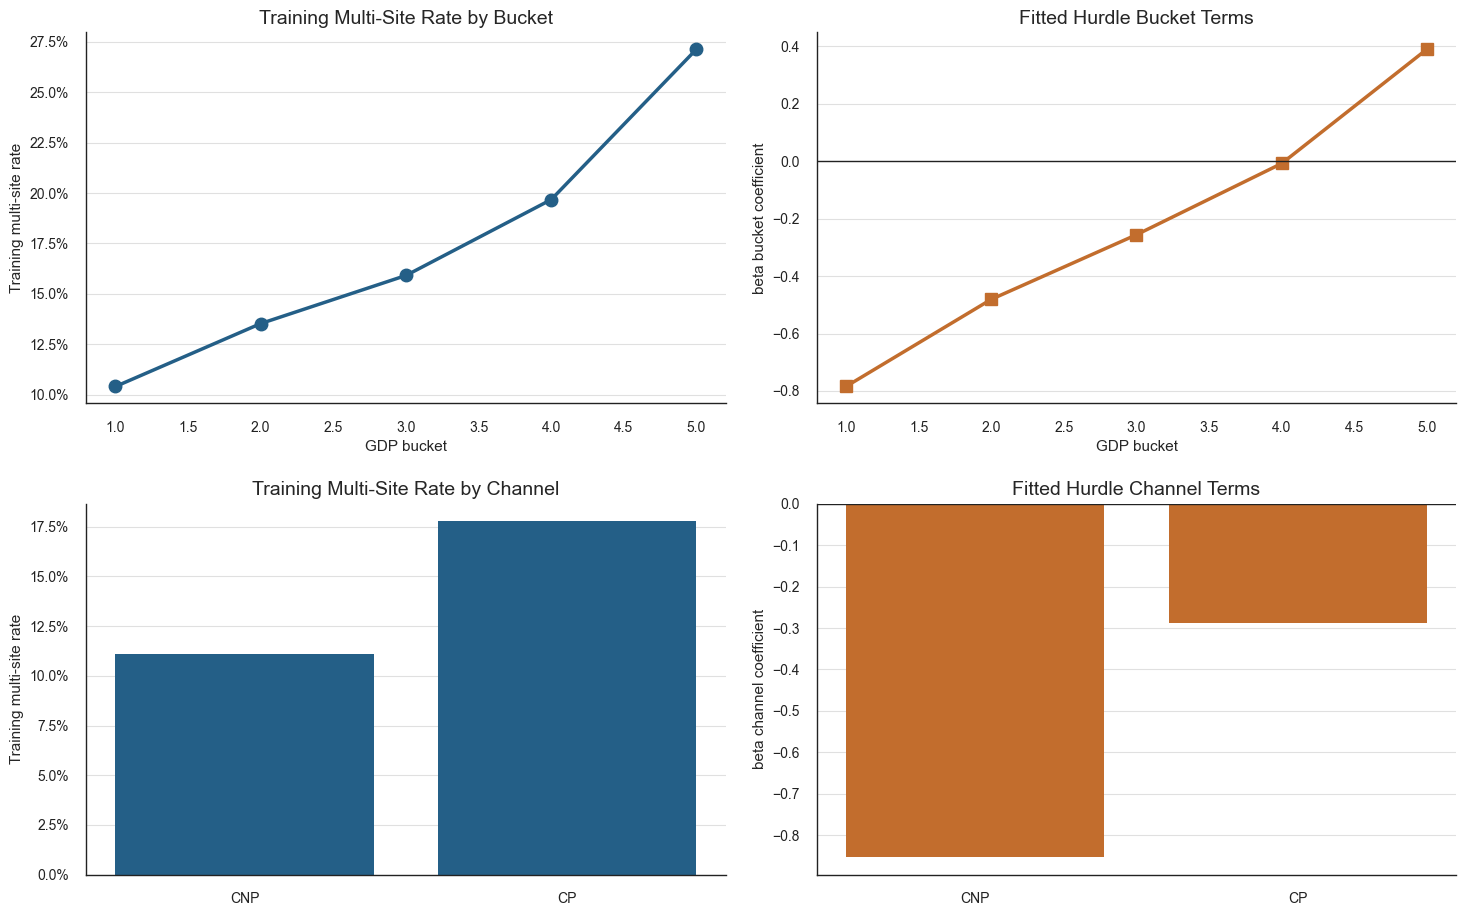

: 

: 

: 

In [ ]:
plot_hurdle_coeff_training_fit_alignment(hurdle_coeff_ctx)


This figure is not about runtime behavior directly. It is about whether the fitted hurdle terms visibly preserve the broad structural tendencies of the training corpus they came from. On the bucket side, they do. The training multi-site rate rises across GDP bucket, and the fitted hurdle bucket coefficients rise with it. The training corpus moves from a low branch rate in the bottom bucket regime to a much higher rate in bucket `5`, and the fitted bucket block responds with a strictly increasing coefficient ladder from `-0.7844` up to `+0.3899`. So the fitted model has kept the same ordinal macro story that the synthetic corpus authored.

The channel comparison says the same thing from another angle. In the training corpus, `CP` has the higher multi-site rate and `CNP` the lower one. The fitted hurdle channel terms preserve that ordering by making `CP` less negative and `CNP` more negative. This is an important nuance. The coefficients are not direct copies of the training rates, because they live on the logit scale and interact with the intercept and the other terms. But the structural ordering is consistent: the channel that was more multi-site in training receives the less suppressive hurdle term in the fitted bundle.

So this figure acts as a sanity bridge between the synthetic corpus and the fitted authority. It shows that the bundle is not contradicting the broad authored realities in the training data. Instead, it is translating them into the model's own parameter language. That makes the active bundle easier to trust analytically, because the large bucket and channel signals we see later at runtime are not appearing from nowhere. They are faithful descendants of the synthetic training world that the priors originally authored.

6. Bundle lineage progression

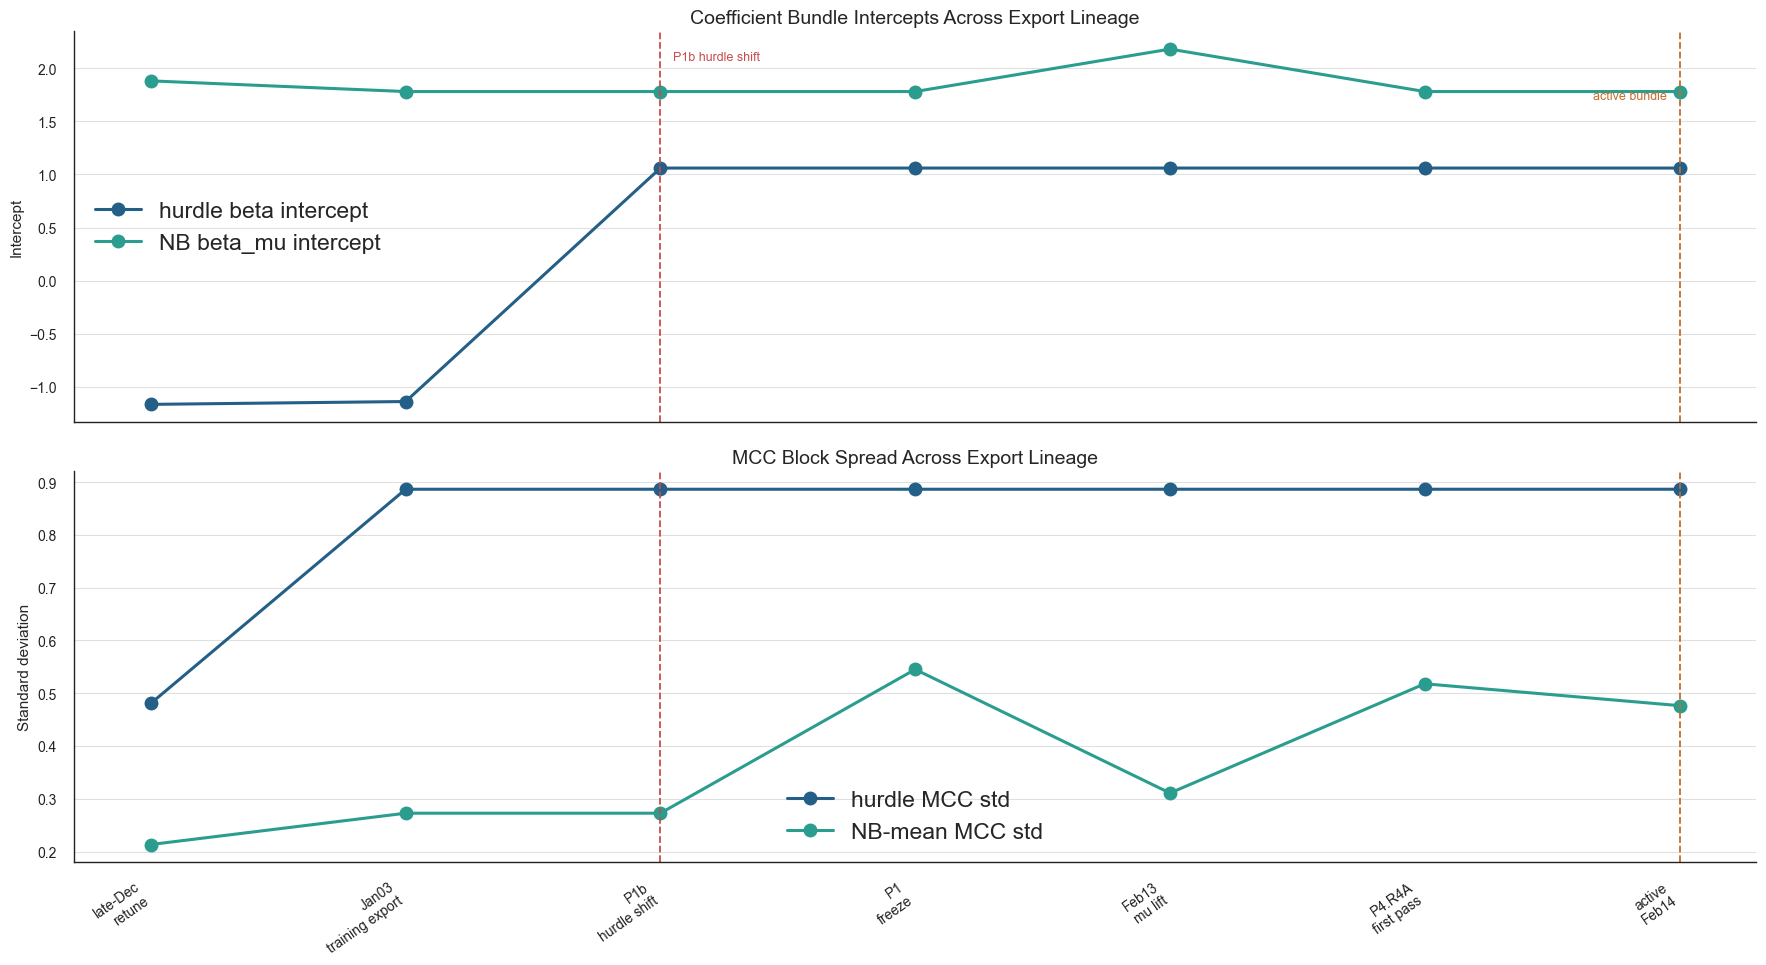

: 

: 

: 

In [ ]:
plot_hurdle_coeff_bundle_lineage_progression(hurdle_coeff_ctx)


This figure pulls the coefficient bundle out of the illusion of timelessness and places it back into its hardening history. The intercept panel shows the key break in the hurdle lane very clearly. The January training export sat at hurdle intercept about `-1.1396`. On `2026-02-12T171900Z`, the bundle family takes a discrete jump to `+1.0604`, and that higher hurdle intercept then remains fixed through the later February bundles shown here. So the active hurdle posture is not the original January posture with minor drift. It is the consequence of a deliberate intercept intervention.

By contrast, the NB-mean intercept is much more stable over this path. It is about `1.7815` in the January training export, remains there through the hurdle-intercept shift, rises temporarily to `2.1815` in the February 13 sweep, and then returns to `1.7815` in the later February 14 bundles. So the bundle family was not moving both lanes in the same way at the same time. The hurdle lane experienced a one-time vertical repositioning, while the NB-mean lane underwent a separate and more exploratory remediation sequence.

The lower panel sharpens that story by looking at MCC spread rather than intercept level. The hurdle MCC standard deviation is about `0.8867` in the January export and then stays fixed thereafter in the plotted February lineage. The NB-mean MCC spread, however, moves materially: about `0.2726` in the January export, then `0.5452` after the first February 12 NB uplift, then `0.3108`, then `0.5179`, then finally `0.4765` in the active bundle. So the active bundle inherits a hurdle lane that was intentionally frozen after its shift, while the neighboring NB-mean lane remained the active surface being reshaped.

That is the key statistical reality in this lineage figure. The bundle family did not evolve as one homogeneous object. It evolved asymmetrically. The hurdle branch law was lifted and then held stable, while the NB-mean lane kept being tuned through non-intercept shape changes. That is exactly why the active file must be read as a remediated descendant bundle rather than as a pristine training export.

7. Original-vs-active deltas

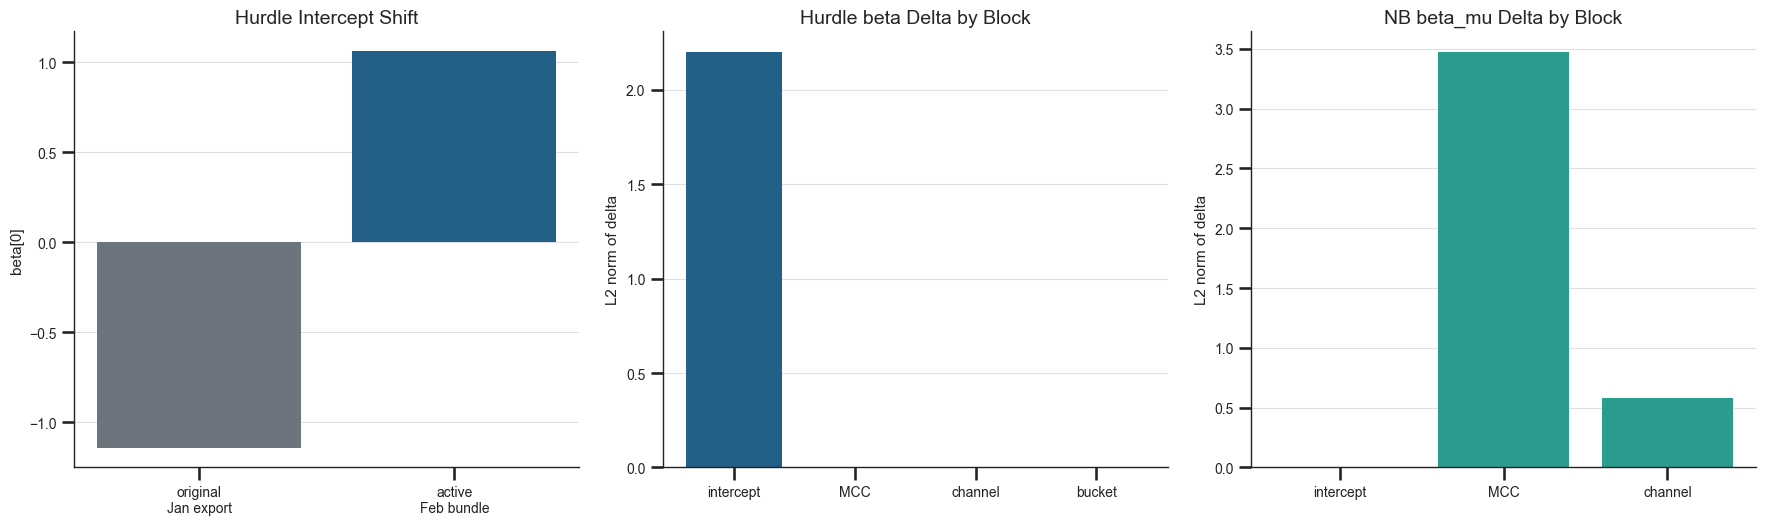

In [56]:
plot_hurdle_coeff_original_vs_active_deltas(hurdle_coeff_ctx)


This final figure compresses the lineage story into one direct original-versus-active comparison. The left panel shows the hurdle intercept jump plainly: the original January export sat at about `-1.1396`, while the active February bundle sits at `+1.0604`. That is an exact increase of `+2.2`, which matches the known hurdle-intercept remediation. So the active hurdle branch world is vertically displaced upward relative to the original training export, not merely nudged.

The center panel then shows something just as important: once we look at hurdle `beta` block deltas by L2 norm, all of the movement is concentrated in the intercept block. The hurdle delta norms are `2.2` for the intercept and `0.0` for MCC, channel, and bucket. That means the active hurdle lane did not change its internal contour relative to the January export. Its category, channel, and GDP-bucket shape were preserved exactly; only the whole hurdle surface was shifted upward.

The right panel tells a completely different story for `beta_mu`. There, the intercept delta is `0.0`, but the non-intercept structure moved materially: the MCC block has L2 delta about `3.4727`, and the channel block about `0.5816`. So the active NB-mean lane was not vertically shifted the way the hurdle lane was. Instead, it was reshaped internally while keeping its intercept level fixed.

Taken together, the figure gives a precise analytical summary of the active bundle's remediation posture. The hurdle lane was remediated by a pure intercept shift, preserving its original structural contour. The NB-mean lane was remediated by internal coefficient reshaping, preserving its intercept. That split explains why the active file should be read as a cross-state engineered artefact: `S1` inherits the original hurdle contour at a new vertical level, while `S2` inherits a meaningfully reworked mean-count surface.

##### `rng_event_hurdle_bernoulli`: first orientation

With the priors and active coefficient bundle inspected, the next object is the runtime event stream that makes the `S1` branch decision real: `rng_event_hurdle_bernoulli`.

This file is not a diagnostic helper in the same sense as `hurdle_pi_probs`. It is the authoritative merchant-level Bernoulli decision stream emitted by `S1`, recording the probability used for the branch decision, the keyed uniform draw, and the realized `is_multi` outcome for each merchant.

The fuller Watson workbench investigation lives here:

- [rng_event_hurdle_bernoulli_investigation.md](../watson_workbench/notes/rng_event_hurdle_bernoulli_investigation.md)

For the notebook, the first job is once again narrower: open the event stream, inspect its row shape and lineage surface, and get a first statistical sense of the branch world it records before we move into the deeper analytical walkthrough.

---

In [57]:
# Point to the active S1 Bernoulli event stream for the pinned run we are investigating.
rng_hurdle_event_path = (
    ROOT
    / "runs"
    / "local_full_run-7"
    / "a3bd8cac9a4284cd36072c6b9624a0c1"
    / "logs"
    / "layer1"
    / "1A"
    / "rng"
    / "events"
    / "hurdle_bernoulli"
    / "seed=42"
    / "parameter_hash=0ea66cf0adf1c64bbaad68e566d1e49be502d771df78c608a4d2c23887d60f00"
    / "run_id=a3bd8cac9a4284cd36072c6b9624a0c1"
    / "part-00000.jsonl"
)

# Load the JSONL rows so we can inspect the runtime branch authority directly before plotting it.
with open(rng_hurdle_event_path, "r", encoding="utf-8") as handle:
    rng_hurdle_event_rows = [json.loads(line) for line in handle if line.strip()]

rng_hurdle_event_df = pd.DataFrame(rng_hurdle_event_rows)

# Normalize a few fields into analysis-friendly dtypes for the cells that follow.
rng_hurdle_event_df["draws"] = rng_hurdle_event_df["draws"].astype(int)
rng_hurdle_event_df["is_multi"] = rng_hurdle_event_df["is_multi"].astype(bool)
rng_hurdle_event_df["deterministic"] = rng_hurdle_event_df["deterministic"].astype(bool)
rng_hurdle_event_df["blocks"] = rng_hurdle_event_df["blocks"].astype(int)

print(f"rng_hurdle_event_path: {rng_hurdle_event_path}")
print(f"event_rows_loaded: {len(rng_hurdle_event_df):,}")


rng_hurdle_event_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\runs\local_full_run-7\a3bd8cac9a4284cd36072c6b9624a0c1\logs\layer1\1A\rng\events\hurdle_bernoulli\seed=42\parameter_hash=0ea66cf0adf1c64bbaad68e566d1e49be502d771df78c608a4d2c23887d60f00\run_id=a3bd8cac9a4284cd36072c6b9624a0c1\part-00000.jsonl
event_rows_loaded: 10,000


In [58]:
# Summarize the row structure so we can see what kind of event object this stream is carrying.
rng_hurdle_event_schema_df = pd.DataFrame(
    [
        {
            "column": column,
            "python_type": type(rng_hurdle_event_df.iloc[0][column]).__name__ if not rng_hurdle_event_df.empty else None,
            "null_count": int(rng_hurdle_event_df[column].isna().sum()),
        }
        for column in rng_hurdle_event_df.columns
    ]
)

display(rng_hurdle_event_schema_df)


,column,python_type,null_count
0,blocks,int32,0
1,deterministic,bool_,0
2,draws,int32,0
3,is_multi,bool_,0
4,manifest_fingerprint,str,0
5,merchant_id,uint64,0
6,module,str,0
7,parameter_hash,str,0
8,pi,float64,0
9,rng_counter_after_hi,uint64,0


In [59]:
# Pull the first high-level facts that matter before deeper analysis: coverage, branch split, and probability range.
rng_hurdle_event_profile_df = pd.DataFrame(
    [
        {"metric": "event_rows", "value": len(rng_hurdle_event_df)},
        {"metric": "distinct_merchants", "value": int(rng_hurdle_event_df["merchant_id"].nunique())},
        {"metric": "multi_merchants", "value": int(rng_hurdle_event_df["is_multi"].sum())},
        {"metric": "single_merchants", "value": int((~rng_hurdle_event_df["is_multi"]).sum())},
        {"metric": "multi_rate", "value": float(rng_hurdle_event_df["is_multi"].mean())},
        {"metric": "mean_pi", "value": float(rng_hurdle_event_df["pi"].mean())},
        {"metric": "median_pi", "value": float(rng_hurdle_event_df["pi"].median())},
        {"metric": "min_pi", "value": float(rng_hurdle_event_df["pi"].min())},
        {"metric": "max_pi", "value": float(rng_hurdle_event_df["pi"].max())},
        {"metric": "mean_u", "value": float(rng_hurdle_event_df["u"].mean())},
        {"metric": "draws_sum", "value": int(rng_hurdle_event_df["draws"].sum())},
    ]
)

display(rng_hurdle_event_profile_df)


,metric,value
0,event_rows,10000.000000
1,distinct_merchants,10000.000000
2,multi_merchants,5817.000000
3,single_merchants,4183.000000
4,multi_rate,0.581700
5,mean_pi,0.582939
6,median_pi,0.599252
7,min_pi,0.000794
8,max_pi,0.950381
9,mean_u,0.501056


In [60]:
# Check whether the stream is singular on its run lineage keys before treating it as one coherent authority surface.
rng_hurdle_event_lineage_df = pd.DataFrame(
    [
        {"field": field, "distinct_values": int(rng_hurdle_event_df[field].nunique()), "sample_value": rng_hurdle_event_df[field].iloc[0]}
        for field in [
            "seed",
            "parameter_hash",
            "manifest_fingerprint",
            "run_id",
            "module",
            "substream_label",
            "blocks",
            "deterministic",
        ]
    ]
)

display(rng_hurdle_event_lineage_df)


,field,distinct_values,sample_value
0,seed,1,42
1,parameter_hash,1,0ea66cf0adf1c64bbaad68e566d1e49be502d771df78c6...
2,manifest_fingerprint,1,76ec81ce37897b0837f5f1b242a3fa557532067d416e51...
3,run_id,1,a3bd8cac9a4284cd36072c6b9624a0c1
4,module,1,1A.hurdle_sampler
5,substream_label,1,hurdle_bernoulli
6,blocks,1,1
7,deterministic,1,False


In [61]:
# Show a small event preview so we can see the merchant-level decision grain directly.
rng_hurdle_event_preview_df = rng_hurdle_event_df[
    [
        "merchant_id",
        "pi",
        "u",
        "is_multi",
        "draws",
        "module",
        "substream_label",
        "ts_utc",
    ]
].head(10)

display(rng_hurdle_event_preview_df)


,merchant_id,pi,u,is_multi,draws,module,substream_label,ts_utc
0,1694081450446801,0.733960,0.647701,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.831436Z
1,2697116941085629,0.804524,0.330244,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
2,3361754771680650,0.363754,0.327587,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
3,9012167658511518,0.615060,0.163183,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
4,10766668736889901,0.253099,0.333595,False,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
5,12629669232507242,0.746410,0.671459,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
6,14291053214586959,0.371180,0.157569,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
7,18638034984233531,0.539664,0.271711,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
8,19498508446557154,0.247991,0.071628,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
9,23202490577169710,0.390740,0.363205,True,1,1A.hurdle_sampler,hurdle_bernoulli,2026-02-28T10:30:00.832435Z
